<div style="
    text-align: center;
    font-family: 'Trebuchet MS', 'Segoe UI', sans-serif;
    color: #75797dff;
    line-height: 1.5;
    padding: 25px;
    border-radius: 20px;
    background: linear-gradient(145deg, #fbfbfbff, #5ea0f7ff);
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
">
  <img src="contant/iut-logo.png" width="160" height="160" style="border-radius: 15px; box-shadow: 0 2px 6px rgba(0,0,0,0.2);">  
  <h1 style="
      color: #0F5298;
      font-size: 45px;
      margin-top: 15px;
      margin-bottom: 10px;
  ">
    Computer Engineering Department
  </h1>
  <h2 style="
      color: #2565AE;
      font-size: 28px;
      margin: 0;
  ">
    <br> Graph Mining Course Project — Progress Report
  </h2>
  <h3 style="
      color: #3C99D8;
      font-size: 22px;
      margin: 10px 0 5px 0;
      letter-spacing: 0.5px;
  ">
    <br> Analysis and Recommendation of Amazon Electronics Products
  </h3>
  <h2 style="
      color: #1F75FE;
      font-size: 28px;
      font-weight: bold;
      text-transform: uppercase;
      margin-top: 15px;
      letter-spacing: 1px;
      text-shadow: 1px 1px 4px rgba(0,0,0,0.1);
  ">
    <br> Dr. Maleki & Dr. Iranidoust
  </h2>
  <p style="
      color: #696880;
      font-size: 18px;
      margin-top: 15px;
      font-style: italic;
  ">
    <br> Student Names: Kourosh Jamshidi & Masoud Hasani <br>
    Student IDs: 40120523 & 40121243 <br>
    Emails: k.jamshidi@ec.iut.ac.ir & masood.hsn82@gmail.com <br>
  </p>
    <h2 style="
      color: #44e3fcff;
      font-size: 28px;
      font-weight: bold;
      text-transform: uppercase;
      margin-top: 15px;
      letter-spacing: 1px;
      text-shadow: 1px 1px 4px rgba(0,0,0,0.1);
  ">
    <br> Winter 2026
  </h2>
</div>

#Run This cell before any work

##connect to drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

##Download Required libraries

In [ ]:
!pip install powerlaw
!pip install -U python-louvain
!pip install python-igraph leidenalg
!pip -q install torch-geometric

##Import Required libraries

In [ ]:
# =======================
# Standard library
# =======================
import os
import time
import math
import json
import csv
import ast
import random
import subprocess
from pathlib import Path
from collections import defaultdict, Counter
from heapq import nlargest

# =======================
# Third-party libraries
# =======================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import sparse
from scipy.sparse.csgraph import connected_components

import networkx as nx
import powerlaw

from sklearn.cluster import KMeans, SpectralClustering
from sklearn.neighbors import kneighbors_graph, radius_neighbors_graph
from sklearn.datasets import make_moons

import community.community_louvain as community_louvain
import igraph as ig
import leidenalg as la

import torch
import torch.nn as nn

from IPython.display import display


#Pre-processing

##Downloading data from amazon

In [ ]:
!wget -nc http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Electronics_5.json.gz
!wget -nc http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/meta_Electronics.json.gz
!gzip -d reviews_Electronics_5.json.gz
!gzip -d meta_Electronics.json.gz
!wget -nc http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/ratings_Electronics.csv


--2026-01-07 12:17:09--  http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Electronics_5.json.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 495854086 (473M) [application/x-gzip]
Saving to: ‘reviews_Electronics_5.json.gz’

reviews_Electronics 100%[===================>] 472.88M  11.5MB/s    in 50s     

2026-01-07 12:17:59 (9.53 MB/s) - ‘reviews_Electronics_5.json.gz’ saved [495854086/495854086]

--2026-01-07 12:17:59--  http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/meta_Electronics.json.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 186594679 (178M) [application/x-gzip]
Saving to: ‘meta_Electronics.json.gz’

meta_Electronics.js 100%[===

In [ ]:
# import pandas as pd
# import ast

# Function to load a text file where each line is a Python dictionary
def load_python_dict_lines(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue  # Skip empty lines
            try:
                # Safely evaluate the line as a Python literal (dict)
                data.append(ast.literal_eval(line))
            except Exception as e:
                # Print an error message if a line cannot be parsed
                print("Error in line:", line[:100], e)
    # Return as a pandas DataFrame
    return pd.DataFrame(data)

# Load metadata file
meta_df = load_python_dict_lines("meta_Electronics.json")
print("Meta data:", meta_df.shape)
print(meta_df.head())

# Load reviews file
reviews_df = load_python_dict_lines("reviews_Electronics_5.json")
print("Reviews data:", reviews_df.shape)
print(reviews_df.head())

# Load CSV ratings file
ratings_df = pd.read_csv("ratings_Electronics.csv", header=None, names=['userID','asin','rating','timestamp'])
print("Ratings data:", ratings_df.shape)
print(ratings_df.head())


Meta data: (498196, 9)
         asin                                              imUrl  \
0  0132793040  http://ecx.images-amazon.com/images/I/31JIPhp%...   
1  0321732944  http://ecx.images-amazon.com/images/I/31uogm6Y...   
2  0439886341  http://ecx.images-amazon.com/images/I/51k0qa8f...   
3  0511189877  http://ecx.images-amazon.com/images/I/41HaAhbv...   
4  0528881469  http://ecx.images-amazon.com/images/I/51FnRkJq...   

                                         description  \
0  The Kelby Training DVD Mastering Blend Modes i...   
1                                                NaN   
2                    Digital Organizer and Messenger   
3  The CLIKR-5 UR5U-8780L remote control is desig...   
4  Like its award-winning predecessor, the Intell...   

                                          categories  \
0  [[Electronics, Computers & Accessories, Cables...   
1  [[Electronics, Computers & Accessories, Cables...   
2  [[Electronics, Computers & Accessories, PDAs, ...   
3  [[El

## moving items to my drive to prevent downloading them every time because these are big chunks of data!


In [ ]:
!mkdir -p /content/drive/MyDrive/GraphMiningProject/data

In [ ]:
!mv reviews_Electronics_5.json /content/drive/MyDrive/GraphMiningProject/data/
!mv meta_Electronics.json /content/drive/MyDrive/GraphMiningProject/data/
!mv ratings_Electronics.csv /content/drive/MyDrive/GraphMiningProject/data/
!mv iut\ logo.png /content/drive/MyDrive/GraphMiningProject/data/

In [ ]:
data_path = "/content/drive/MyDrive/GraphMiningProject/data/"

##Confirm dataset & paths

In [ ]:
# Confirm dataset & paths
# import os, ast
# import pandas as pd
# from pathlib import Path

expected = {
    "reviews": "reviews_Electronics_5.json",
    "meta":    "meta_Electronics.json",
    "ratings": "ratings_Electronics.csv"
}

p = Path(data_path)
print(f"Checking directory: {p.resolve()}\n")

# I wrote these lines in case if running on Colab and Drive not mounted, uncomment the next lines:
# from google.colab import drive
# drive.mount('/content/drive')

missing = []
for name, fname in expected.items():
    fpath = p / fname
    if fpath.exists():
        size = fpath.stat().st_size
        hr = (f"{size/1024**2:.2f} MB" if size > 1024**2 else f"{size/1024:.2f} KB")
        print(f"FOUND: {fname}  —  {hr}")
    else:
        print(f"MISSING: {fname}")
        missing.append(fname)

if missing:
    print("\nOne or more files are missing. If you have them locally, move them to:")
    print(f"  {p}\n")
    print("Example shell command to move files (run in a cell):")
    for fname in missing:
        print(f"  !mv /path/to/{fname} \"{p/fname}\"")
else:
    print("\nAll expected files found. Quick content check follows.\n")

    # Quick sanity checks (load tiny samples)
    try:
        print(" -> Reading 3 lines from reviews sample (JSON lines)...")
        with open(p / expected['reviews'], 'r', encoding='utf-8') as f:
            for i in range(3):
                line = f.readline().strip()
                if not line:
                    break
                obj = ast.literal_eval(line)
                keys = list(obj.keys())
                print(f"   line {i+1} keys: {keys[:8]}{'...' if len(keys)>8 else ''}")
    except Exception as e:
        print("   Error reading reviews sample:", e)

    try:
        print("\n -> Reading 3 lines from meta sample (JSON lines)...")
        with open(p / expected['meta'], 'r', encoding='utf-8') as f:
            for i in range(3):
                line = f.readline().strip()
                if not line:
                    break
                obj = ast.literal_eval(line)
                print(f"   line {i+1} keys: {list(obj.keys())[:8]}")
    except Exception as e:
        print("   Error reading meta sample:", e)

    try:
        print("\n -> Reading first 5 rows from ratings CSV:")
        df = pd.read_csv(p / expected['ratings'], header=None, names=['userID','asin','rating','timestamp'], nrows=5)
        display(df)
    except Exception as e:
        print("   Error reading ratings CSV:", e)


Checking directory: /content/drive/MyDrive/GraphMiningProject/data

FOUND: reviews_Electronics_5.json  —  1410.45 MB
FOUND: meta_Electronics.json  —  632.89 MB
FOUND: ratings_Electronics.csv  —  304.00 MB

All expected files found. Quick content check follows.

 -> Reading 3 lines from reviews sample (JSON lines)...
   line 1 keys: ['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime']...
   line 2 keys: ['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime']...
   line 3 keys: ['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime']...

 -> Reading 3 lines from meta sample (JSON lines)...
   line 1 keys: ['asin', 'imUrl', 'description', 'categories', 'title']
   line 2 keys: ['asin', 'imUrl', 'categories', 'title']
   line 3 keys: ['asin', 'categories', 'description', 'title', 'price', 'salesRank', 'imUrl', 'related']

 -> Reading first 5 rows

,userID,asin,rating,timestamp
0,AKM1MP6P0OYPR,132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,439886341,1.0,1334707200



If the samples look good, you can proceed to preprocessing / building graphs.


## Step 2: Basic Preprocessing and Normalization

In [ ]:
# Basic preprocessing & normalization (streaming, Colab-friendly)
# It creates a `processed/` folder under data_path
# and writes memory-friendly, cleaned CSVs for later steps.
# import os, ast, csv
# from pathlib import Path
# import pandas as pd

processed_path = os.path.join(data_path, "processed")
os.makedirs(processed_path, exist_ok=True)

reviews_in  = Path(data_path) / "reviews_Electronics_5.json"
meta_in     = Path(data_path) / "meta_Electronics.json"
ratings_in  = Path(data_path) / "ratings_Electronics.csv"

reviews_out = Path(processed_path) / "reviews_minimal.csv"   # userID, asin, overall, unixReviewTime
meta_out    = Path(processed_path) / "meta_minimal.csv"      # asin, related (stringified dict)
ratings_out = Path(processed_path) / "ratings_normalized.csv" # userID, asin (str), rating, timestamp

print("Inputs:")
print(" -", reviews_in)
print(" -", meta_in)
print(" -", ratings_in)
print("\nOutputs (will be written):")
print(" -", reviews_out)
print(" -", meta_out)
print(" -", ratings_out)
print("\nStarting preprocessing...")

# Scan meta once to find max asin length (helps normalize ratings ASINs)
max_asin_len = 0
count = 0
with open(meta_in, 'r', encoding='utf-8') as f:
    for line in f:
        if not line.strip():
            continue
        try:
            obj = ast.literal_eval(line)
            asin = str(obj.get('asin','')).strip()
            if asin:
                max_asin_len = max(max_asin_len, len(asin))
        except Exception:
            pass
        count += 1
        if count % 200000 == 0:
            print(f"  scanned {count} meta lines...")

print(f"Max asin string length found in meta: {max_asin_len}")

# Preprocess meta -> meta_minimal.csv (asin, related)
print("\nWriting meta minimal file...")
with open(meta_in, 'r', encoding='utf-8') as fin, open(meta_out, 'w', encoding='utf-8', newline='') as fout:
    writer = csv.writer(fout)
    writer.writerow(['asin','related'])  # header
    i = 0
    for line in fin:
        if not line.strip():
            continue
        try:
            obj = ast.literal_eval(line)
            asin = str(obj.get('asin','')).strip()
            related = obj.get('related', None)
            # stringify related (so we can reload later)
            related_s = "" if related is None else str(related)
            if asin:
                writer.writerow([asin, related_s])
        except Exception:
            # skip bad lines
            continue
        i += 1
        if i % 200000 == 0:
            print(f"  processed {i} meta lines...")
print("meta minimal written:", meta_out)

# Preprocess reviews -> reviews_minimal.csv (userID, asin, overall, unixReviewTime)
print("\nWriting reviews minimal file...")
with open(reviews_in, 'r', encoding='utf-8') as fin, open(reviews_out, 'w', encoding='utf-8', newline='') as fout:
    writer = csv.writer(fout)
    writer.writerow(['userID','asin','overall','unixReviewTime'])
    i = 0
    for line in fin:
        if not line.strip():
            continue
        try:
            obj = ast.literal_eval(line)
            user = obj.get('reviewerID') or obj.get('userID') or ""
            asin = obj.get('asin') or ""
            overall = obj.get('overall', "")
            unix = obj.get('unixReviewTime', obj.get('unixReviewTime',''))
            if user and asin:
                writer.writerow([str(user).strip(), str(asin).strip(), overall, unix])
        except Exception:
            continue
        i += 1
        if i % 200000 == 0:
            print(f"  processed {i} review lines...")
print("reviews minimal written:", reviews_out)

# Preprocess ratings (chunked) -> ratings_normalized.csv
#    - Ensure userID is string
#    - Convert asin to string and zfill to max_asin_len (best-effort to restore leading zeros)
print("\nNormalizing ratings (chunked read)...")
chunk_iter = pd.read_csv(ratings_in, header=None, names=['userID','asin','rating','timestamp'], chunksize=200000)
first = True
rows_written = 0
for chunk in chunk_iter:
    # ensure userID str
    chunk['userID'] = chunk['userID'].astype(str)
    # asin might be numeric — convert and zfill to target length
    chunk['asin'] = chunk['asin'].astype(str).str.strip()
    if max_asin_len > 0:
        chunk['asin_z'] = chunk['asin'].str.zfill(max_asin_len)
    else:
        chunk['asin_z'] = chunk['asin']
    # prefer zfilled asin (best-effort); keep as string
    chunk_out = chunk[['userID','asin_z','rating','timestamp']].rename(columns={'asin_z':'asin'})
    # write/appending
    chunk_out.to_csv(ratings_out, mode='a', header=first, index=False)
    first = False
    rows_written += len(chunk_out)
    if rows_written % 500000 == 0:
        print(f"  wrote {rows_written} rating rows...")
print("ratings normalized written:", ratings_out, f"({rows_written} rows)")

# Quick sanity checks - print small samples
print("\nSanity checks (first 5 rows each):")
print("\nmeta_minimal sample:")
display(pd.read_csv(meta_out, nrows=5))
print("\nreviews_minimal sample:")
display(pd.read_csv(reviews_out, nrows=5))
print("\nratings_normalized sample:")
display(pd.read_csv(ratings_out, nrows=5))

print("\nStep 2 complete. Processed files are in:", processed_path)


Inputs:
 - /content/drive/MyDrive/GraphMiningProject/data/reviews_Electronics_5.json
 - /content/drive/MyDrive/GraphMiningProject/data/meta_Electronics.json
 - /content/drive/MyDrive/GraphMiningProject/data/ratings_Electronics.csv

Outputs (will be written):
 - /content/drive/MyDrive/GraphMiningProject/data/processed/reviews_minimal.csv
 - /content/drive/MyDrive/GraphMiningProject/data/processed/meta_minimal.csv
 - /content/drive/MyDrive/GraphMiningProject/data/processed/ratings_normalized.csv

Starting preprocessing...
  scanned 200000 meta lines...
  scanned 400000 meta lines...
Max asin string length found in meta: 10

Writing meta minimal file...
  processed 200000 meta lines...
  processed 400000 meta lines...
meta minimal written: /content/drive/MyDrive/GraphMiningProject/data/processed/meta_minimal.csv

Writing reviews minimal file...
  processed 200000 review lines...
  processed 400000 review lines...
  processed 600000 review lines...
  processed 800000 review lines...
  proc

,asin,related
0,132793040,NaN
1,321732944,NaN
2,439886341,"{'also_viewed': ['0545016266', 'B009ECM8QY', '..."
3,511189877,"{'also_viewed': ['B001KC08A4', 'B00KUL8O0W', '..."
4,528881469,"{'also_viewed': ['B006ZOI9OY', 'B00C7FKT2A', '..."



reviews_minimal sample:


,userID,asin,overall,unixReviewTime
0,AO94DHGC771SJ,528881469,5.0,1370131200
1,AMO214LNFCEI4,528881469,1.0,1290643200
2,A3N7T0DY83Y4IG,528881469,3.0,1283990400
3,A1H8PY3QHMQQA0,528881469,2.0,1290556800
4,A24EV6RXELQZ63,528881469,1.0,1317254400



ratings_normalized sample:


,userID,asin,rating,timestamp
0,AKM1MP6P0OYPR,132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,439886341,1.0,1334707200



Step 2 complete. Processed files are in: /content/drive/MyDrive/GraphMiningProject/data/processed
Next: filtering/sampling or building the sparse user-product matrix.




In this step, we performed a one-time preprocessing pass over the original Amazon Electronics datasets to make them safe and efficient for graph mining. The goal was not analysis or sampling, but data cleaning and structural normalization. Each raw file was scanned in a memory-efficient, chunked manner and rewritten into a minimal format containing only the fields required for graph construction (user IDs, product IDs, ratings, timestamps, and product–product relations). This significantly reduced noise while preserving the full informational content of the datasets.

A critical part of this step was normalizing product identifiers (ASINs). In the raw files, ASINs sometimes appear as numeric values and sometimes as strings, which can silently break joins and graph edges if left uncorrected. All ASINs were therefore coerced into a consistent string representation across reviews, metadata, and ratings. No filtering or downsampling was performed: all records were retained. The result of this step is a set of clean, lightweight, and internally consistent CSV files that can be reliably used for subsequent graph construction and analysis.

---

## Step 3: Filtering and Sampling for Scalability

In [ ]:
# import os
# from pathlib import Path
# from collections import Counter
# import pandas as pd

# We had these paths before but in case you want to change them in your code when you are running it!
data_path = "/content/drive/MyDrive/GraphMiningProject/data/"
processed_path = os.path.join(data_path, "processed")
filtered_path = os.path.join(processed_path, "filtered")
os.makedirs(filtered_path, exist_ok=True)

ratings_file = Path(processed_path) / "ratings_normalized.csv"
reviews_file = Path(processed_path) / "reviews_minimal.csv"

# Filtering thresholds
min_user_interactions = 5       # keep users with at least this many interactions
min_product_interactions = 20   # keep products with at least this many interactions

# Optional caps
max_products = 100000   # if product pool > this after thresholding, keep top-N by count
max_users = 200000      # similarly for users

# Iteration controls
chunksize = 200_000
max_iters = 5

print("Filtering settings:")
print(f"  min_user_interactions = {min_user_interactions}")
print(f"  min_product_interactions = {min_product_interactions}")
print(f"  max_products = {max_products}, max_users = {max_users}")
print()

# helper to accumulate counts from a CSV (chunked)
def accumulate_counts_from_ratings(rfile, user_set=None, prod_set=None):
    user_cnt = Counter()
    prod_cnt = Counter()
    for chunk in pd.read_csv(rfile, chunksize=chunksize):
        if user_set is not None:
            chunk = chunk[chunk['userID'].isin(user_set)]
        if prod_set is not None:
            chunk = chunk[chunk['asin'].isin(prod_set)]
        # value_counts is faster than iterrows
        uc = chunk['userID'].value_counts()
        pc = chunk['asin'].value_counts()
        user_cnt.update(uc.to_dict())
        prod_cnt.update(pc.to_dict())
    return user_cnt, prod_cnt

def accumulate_counts_from_reviews(rfile, user_set=None, prod_set=None):
    # reviews_minimal: columns [userID, asin, overall, unixReviewTime]
    user_cnt = Counter()
    prod_cnt = Counter()
    for chunk in pd.read_csv(rfile, chunksize=chunksize, usecols=['userID','asin']):
        if user_set is not None:
            chunk = chunk[chunk['userID'].isin(user_set)]
        if prod_set is not None:
            chunk = chunk[chunk['asin'].isin(prod_set)]
        uc = chunk['userID'].value_counts()
        pc = chunk['asin'].value_counts()
        user_cnt.update(uc.to_dict())
        prod_cnt.update(pc.to_dict())
    return user_cnt, prod_cnt

# initial full counts (ratings + reviews)
print("Computing initial counts from ratings (this may take a minute)...")
r_user_cnt, r_prod_cnt = accumulate_counts_from_ratings(ratings_file)
print("Computing counts from reviews (adds more interactions)...")
v_user_cnt, v_prod_cnt = accumulate_counts_from_reviews(reviews_file)

# combine counts (ratings + reviews)
user_counts = Counter(r_user_cnt)
for k,v in v_user_cnt.items(): user_counts[k] += v
prod_counts = Counter(r_prod_cnt)
for k,v in v_prod_cnt.items(): prod_counts[k] += v

print(f"Total unique users (raw): {len(user_counts):,}")
print(f"Total unique products (raw): {len(prod_counts):,}")

# iterative peeling
kept_users = set(u for u,c in user_counts.items() if c >= min_user_interactions)
kept_products = set(p for p,c in prod_counts.items() if c >= min_product_interactions)

print(f"\nInitial kept: users={len(kept_users):,}, products={len(kept_products):,}")

for it in range(1, max_iters+1):
    # recompute counts but restricted to current kept sets
    ucnt, pcnt = accumulate_counts_from_ratings(ratings_file, user_set=kept_users, prod_set=kept_products)
    vuc, vpc = accumulate_counts_from_reviews(reviews_file, user_set=kept_users, prod_set=kept_products)
    for k,v in vuc.items(): ucnt[k] += v
    for k,v in vpc.items(): pcnt[k] += v

    new_kept_users = set(u for u,c in ucnt.items() if c >= min_user_interactions)
    new_kept_products = set(p for p,c in pcnt.items() if c >= min_product_interactions)

    print(f"Iter {it}: users={len(new_kept_users):,}, products={len(new_kept_products):,}")

    if new_kept_users == kept_users and new_kept_products == kept_products:
        print("Converged.")
        break
    kept_users, kept_products = new_kept_users, new_kept_products
else:
    print("Max iterations reached (stopped).")

# apply caps if needed
if max_products is not None and len(kept_products) > max_products:
    # take top products by global prod_counts
    top_prods = [p for p,_ in prod_counts.most_common(max_products)]
    kept_products = set(kept_products).intersection(top_prods)
    print(f"Applied max_products cap -> products={len(kept_products):,}")

if max_users is not None and len(kept_users) > max_users:
    top_users = [u for u,_ in user_counts.most_common(max_users)]
    kept_users = set(kept_users).intersection(top_users)
    print(f"Applied max_users cap -> users={len(kept_users):,}")

print("\nFinal filtered sizes:")
print(f"  users = {len(kept_users):,}")
print(f"  products = {len(kept_products):,}")

# write filtered CSVs (chunked)
ratings_out = Path(filtered_path) / "ratings_filtered.csv"
reviews_out = Path(filtered_path) / "reviews_filtered.csv"

# write ratings_filtered
print("\nWriting ratings_filtered.csv ...")
first = True
written = 0
for chunk in pd.read_csv(ratings_file, chunksize=chunksize):
    sel = chunk[chunk['userID'].isin(kept_users) & chunk['asin'].isin(kept_products)]
    if not sel.empty:
        sel.to_csv(ratings_out, mode='a', header=first, index=False)
        first = False
        written += len(sel)
        if written % 500000 == 0:
            print(f"  wrote {written:,} rating rows...")
print(f"ratings_filtered written: {ratings_out}  ({written:,} rows)")

# write reviews_filtered
print("Writing reviews_filtered.csv ...")
first = True
written_r = 0
for chunk in pd.read_csv(reviews_file, chunksize=chunksize):
    sel = chunk[chunk['userID'].isin(kept_users) & chunk['asin'].isin(kept_products)]
    if not sel.empty:
        sel.to_csv(reviews_out, mode='a', header=first, index=False)
        first = False
        written_r += len(sel)
        if written_r % 200000 == 0:
            print(f"  wrote {written_r:,} review rows...")
print(f"reviews_filtered written: {reviews_out}  ({written_r:,} rows)")

# create id mappings
print("\nCreating ID mappings (0..N-1)")
user_map = {u:i for i,u in enumerate(sorted(kept_users))}
prod_map = {p:i for i,p in enumerate(sorted(kept_products))}

pd.DataFrame(list(user_map.items()), columns=['userID','uid']).to_csv(Path(filtered_path)/"user_map.csv", index=False)
pd.DataFrame(list(prod_map.items()), columns=['asin','pid']).to_csv(Path(filtered_path)/"product_map.csv", index=False)
print("Saved user_map.csv and product_map.csv")

# quick stats
print("\nQuick stats for filtered graph:")
print(" - total rating edges:", written)
print(" - total review edges:", written_r)
print(" - total users:", len(user_map))
print(" - total products:", len(prod_map))

print("\nStep 3 complete. Filtered files are in:", filtered_path)

# Outputs (written to processed/filtered/):
#  - ratings_filtered.csv
#  - reviews_filtered.csv
#  - user_map.csv  (userID -> uid)
#  - product_map.csv (asin -> pid)
#
# We can adjust the parameters above if we want a larger/smaller graph.

Filtering settings:
  min_user_interactions = 5
  min_product_interactions = 20
  max_products = 100000, max_users = 200000

Computing initial counts from ratings (this may take a minute)...
Computing counts from reviews (adds more interactions)...
Total unique users (raw): 4,201,696
Total unique products (raw): 476,002

Initial kept: users=254,064, products=65,418
Iter 1: users=197,515, products=36,479
Iter 2: users=191,439, products=35,096
Iter 3: users=191,195, products=34,999
Iter 4: users=191,178, products=34,985
Iter 5: users=191,174, products=34,984
Max iterations reached (stopped).

Final filtered sizes:
  users = 191,174
  products = 34,984

Writing ratings_filtered.csv ...
ratings_filtered written: /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/ratings_filtered.csv  (1,503,920 rows)
Writing reviews_filtered.csv ...
reviews_filtered written: /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/reviews_filtered.csv  (1,503,920 rows)

Creating ID 



In this step, we reduced the original Amazon Electronics interaction graph to a **manageable yet structurally meaningful subgraph** suitable for graph mining experiments. The raw dataset contains millions of users and hundreds of thousands of products, many of which appear only once or twice. Such low-activity nodes add noise, inflate computation time, and destabilize graph algorithms. To address this, we applied **interaction-based filtering**: users were required to have at least `min_user_interactions = 5`, and products at least `min_product_interactions = 20`. These thresholds remove sparse, low-signal nodes while preserving the dense core where meaningful behavior patterns exist.

The filtering was applied **iteratively** because this is a *bipartite graph* (users ↔ products). Removing weak users can cause some products to fall below the minimum interaction threshold, and removing those products can in turn make additional users invalid. Each iteration (logged as `Iter 1`, `Iter 2`, …) repeats this pruning process until the graph stabilizes. Conceptually, this is similar to a *k-core–style peeling process*:
```text
Iteration:
  keep_users = users with ≥ 5 interactions
  keep_products = products with ≥ 20 interactions
  remove all others
Repeat until no more nodes are removed

The iteration stops when the number of users and products no longer changes (convergence) or when a maximum iteration count is reached.
```

After convergence, the dataset was reduced from over 4.2 million users and 476k products to a dense subgraph with ~191k users, ~35k products, and ~1.5 million interactions. Importantly, this subgraph retains a disproportionately large fraction of interactions, meaning we preserved the most informative part of the data. This makes subsequent graph algorithms (such as similarity computation, centrality, and community detection) both tractable and more stable, while avoiding the noise introduced by one-off users and rarely interacted products. The result is a clean, research-grade graph that reflects real usage patterns and can be processed efficiently on limited computational resources.

---

## Step 4: Building the User–Product Sparse Matrix

In [ ]:
# import os
# from pathlib import Path
# import pandas as pd
# import numpy as np
# from scipy import sparse
# import json

filtered_path = Path("/content/drive/MyDrive/GraphMiningProject/data/processed/filtered")
ratings_file = filtered_path / "ratings_filtered.csv"
user_map_file = filtered_path / "user_map.csv"
prod_map_file = filtered_path / "product_map.csv"
out_dir = filtered_path  # we save matrices here
os.makedirs(out_dir, exist_ok=True)
chunksize = 200_000

# Load mappings (these are expected to be small-ish)
print("Loading id maps...")
user_map_df = pd.read_csv(user_map_file)   # columns: userID, uid
prod_map_df = pd.read_csv(prod_map_file)   # columns: asin, pid

# Build dicts for fast lookup
user_to_index = dict(zip(user_map_df['userID'].astype(str), user_map_df['uid'].astype(int)))
prod_to_index = dict(zip(prod_map_df['asin'].astype(str), prod_map_df['pid'].astype(int)))

n_users = user_map_df.shape[0]
n_products = prod_map_df.shape[0]
print(f"Users (n) = {n_users:,}, Products (m) = {n_products:,}")

# Prepare lists to accumulate COO data
rows = []
cols = []
data = []

print("Streaming ratings_filtered.csv and constructing COO lists...")
total_rows = 0
missed = 0
for chunk in pd.read_csv(ratings_file, chunksize=chunksize):
    # ensure strings
    chunk['userID'] = chunk['userID'].astype(str)
    chunk['asin'] = chunk['asin'].astype(str)
    # iterate through rows: vectorized mapping is faster
    # Map with .map then dropna for rows not in maps
    chunk['uid'] = chunk['userID'].map(user_to_index)
    chunk['pid'] = chunk['asin'].map(prod_to_index)
    # drop any rows where mapping not found (should be none if mappings from same filter)
    valid = chunk.dropna(subset=['uid','pid'])
    if valid.empty:
        missed += len(chunk)
        continue
    # cast to appropriate dtype
    uids = valid['uid'].astype(np.int32).to_numpy()
    pids = valid['pid'].astype(np.int32).to_numpy()
    vals = valid['rating'].astype(np.float32).to_numpy()
    rows.extend(uids.tolist())
    cols.extend(pids.tolist())
    data.extend(vals.tolist())
    total_rows += len(valid)
    if total_rows % 200_000 == 0:
        print(f"  accumulated {total_rows:,} interactions...")

print(f"Finished streaming. Total valid interactions accumulated: {total_rows:,}")
if missed:
    print(f"Rows skipped (no mapping found): {missed:,}")

# Create COO matrix
print("Creating COO matrix...")
rows = np.array(rows, dtype=np.int32)
cols = np.array(cols, dtype=np.int32)
data = np.array(data, dtype=np.float32)

B_ratings = sparse.coo_matrix((data, (rows, cols)), shape=(n_users, n_products))
print("COO created. Converting to CSR (summing duplicate entries if any)...")
B_ratings = B_ratings.tocsr()

# Create binary interaction matrix (presence). We set all nonzero entries to 1.
print("Building binary interaction matrix...")
B_binary = B_ratings.copy()
B_binary.data = np.ones_like(B_binary.data, dtype=np.float32)  # or uint8 if you prefer

# Save matrices to disk (npz)
ratings_out = out_dir / "ratings_matrix.npz"
binary_out  = out_dir / "binary_matrix.npz"
print(f"Saving ratings matrix -> {ratings_out} ...")
sparse.save_npz(ratings_out, B_ratings)
print(f"Saving binary matrix -> {binary_out} ...")
sparse.save_npz(binary_out, B_binary)

# Diagnostics
nnz = B_ratings.nnz
density = nnz / (n_users * n_products)
print("\n--- Diagnostics ---")
print(f"Ratings matrix shape: {B_ratings.shape}, nnz = {nnz:,}, density = {density:.6f}")

# Top users by degree (number of interacted products)
user_deg = np.array(B_binary.sum(axis=1)).ravel()
top_user_idx = np.argsort(-user_deg)[:10]
print("\nTop 10 users by interaction count (uid : interactions):")
for uid in top_user_idx:
    print(f"  {uid} : {int(user_deg[uid])}")

# Top products by degree
prod_deg = np.array(B_binary.sum(axis=0)).ravel()
top_prod_idx = np.argsort(-prod_deg)[:10]
print("\nTop 10 products by interaction count (pid : interactions):")
for pid in top_prod_idx:
    print(f"  {pid} : {int(prod_deg[pid])}")

# Save some metadata for downstream use
meta = {
    "n_users": int(n_users),
    "n_products": int(n_products),
    "nnz": int(nnz),
    "density": float(density),
    "ratings_matrix_path": str(ratings_out),
    "binary_matrix_path": str(binary_out)
}
with open(out_dir / "matrix_meta.json", "w") as fh:
    json.dump(meta, fh, indent=2)

print("\nStep 4 complete. Matrices saved and metadata written to 'matrix_meta.json'.")


Loading id maps...
Users (n) = 191,174, Products (m) = 34,984
Streaming ratings_filtered.csv and constructing COO lists...
  accumulated 200,000 interactions...
  accumulated 400,000 interactions...
  accumulated 600,000 interactions...
  accumulated 800,000 interactions...
  accumulated 1,000,000 interactions...
  accumulated 1,200,000 interactions...
  accumulated 1,400,000 interactions...
Finished streaming. Total valid interactions accumulated: 1,503,920
Creating COO matrix...
COO created. Converting to CSR (summing duplicate entries if any)...
Building binary interaction matrix...
Saving ratings matrix -> /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/ratings_matrix.npz ...
Saving binary matrix -> /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/binary_matrix.npz ...

--- Diagnostics ---
Ratings matrix shape: (191174, 34984), nnz = 1,503,920, density = 0.000225

Top 10 users by interaction count (uid : interactions):
  159850 : 389
  136000 : 35



In this step, we transformed the filtered interaction data into a mathematical representation suitable for graph mining and large-scale analysis. Using the user and product ID mappings created in the previous step, we constructed a **user × product sparse matrix**, where rows correspond to users and columns correspond to products. Each nonzero entry represents an interaction between a user and a product. To keep the process scalable, the ratings data was streamed in chunks and first assembled in **COO (Coordinate) format**, which is efficient for incremental construction. The matrix was then converted to **CSR (Compressed Sparse Row) format**, which is significantly faster for downstream operations such as similarity computation, projections, and graph algorithms.

Two versions of the matrix were produced. The first is a **ratings matrix**, where each nonzero value corresponds to the user’s explicit rating for a product. The second is a **binary interaction matrix**, where all nonzero entries are set to 1, indicating only the presence of an interaction. This separation is intentional: rating-weighted matrices are useful for preference-aware recommendation and evaluation, while binary matrices are better suited for structural graph operations such as Jaccard similarity, co-purchase projections, and centrality analysis. Both matrices were stored efficiently as `.npz` files and accompanied by metadata describing their size, sparsity, and density.

From an analytical perspective, this step confirms that the dataset exhibits **extreme sparsity** (density ≈ 0.000225), which is a defining characteristic of real-world recommender systems and user–product networks. A small number of users interact with many products, and a small number of products receive a very large number of interactions, as seen in the top-degree users and products. This heavy-tailed behavior justifies the graph-based approach used in this project, as traditional dense matrix methods would be inefficient and conceptually inappropriate.

Finally, constructing this sparse representation is a critical foundation for the rest of the project. All subsequent steps—product–product graph construction, PageRank computation, user similarity via Jaccard index, clustering, and recommendation evaluation—can now be expressed as efficient sparse matrix operations. By working on this filtered but still large-scale sample, we preserve realistic network structure while keeping computation feasible in a notebook-based environment.

---


## Step 5 — Constructing the Product–Product Graph

In [ ]:
# Construct product–product graph (meta.related + sparse bipartite projection)
# - Part A: extract edges from meta_minimal.csv ('also_bought','also_viewed') with configurable weights

# import ast, csv, os
# from pathlib import Path
# from collections import defaultdict, Counter
# import pandas as pd
# import numpy as np
# from scipy import sparse

base_filtered = Path("/content/drive/MyDrive/GraphMiningProject/data/processed/filtered")
meta_minimal = Path("/content/drive/MyDrive/GraphMiningProject/data/processed/meta_minimal.csv")
prod_map_file = base_filtered / "product_map.csv"
binary_mat_file = base_filtered / "binary_matrix.npz"

out_meta_edges = base_filtered / "pp_edges_meta.csv"
out_proj_edges = base_filtered / "pp_edges_proj.csv"
out_combined   = base_filtered / "pp_edges_combined.csv"

# weights for meta types
weight_also_bought = 2.0
weight_also_viewed = 1.0

# projection parameters
threshold_coocc = 5    # minimum cooccurrence to keep an edge
top_k = 100            # keep top-k neighbors per product after thresholding (None to disable)
block_size = 500       # number of product columns per block for projection computation
# ------------------------------------

print("Loading product map...")
prod_map_df = pd.read_csv(prod_map_file)   # asin -> pid
prod_to_pid = dict(zip(prod_map_df['asin'].astype(str), prod_map_df['pid'].astype(int)))
pid_to_asin = dict(zip(prod_map_df['pid'].astype(int), prod_map_df['asin'].astype(str)))
n_products = prod_map_df.shape[0]
print(f"Products in map: {n_products:,}")

# -----------------------
# Part A: build edges from meta.related
# -----------------------
print("\nPart A: extracting edges from meta.related ...")
edge_weights = defaultdict(float)  # key: (min_pid,max_pid) -> weight

# read meta_minimal csv line-by-line to avoid memory spikes
meta_df_iter = pd.read_csv(meta_minimal, chunksize=200_000, dtype={'asin':str, 'related':str})
lines = 0
for chunk in meta_df_iter:
    for asin, related_str in zip(chunk['asin'].astype(str), chunk['related'].fillna('').astype(str)):
        lines += 1
        if not related_str:
            continue
        try:
            rel = ast.literal_eval(related_str)
        except Exception:
            continue
        pid_u = prod_to_pid.get(asin)
        if pid_u is None:
            continue
        # process lists
        for k, w in (('also_bought', weight_also_bought), ('also_viewed', weight_also_viewed)):
            others = rel.get(k, []) if isinstance(rel, dict) else []
            # ensure list-like
            if not isinstance(others, (list, tuple)):
                continue
            for other_asin in others:
                pid_v = prod_to_pid.get(str(other_asin))
                if pid_v is None or pid_v == pid_u:
                    continue
                a, b = (pid_u, pid_v) if pid_u < pid_v else (pid_v, pid_u)
                edge_weights[(a,b)] += w
    if lines % 200000 == 0:
        print(f"  scanned {lines} meta rows...")

print(f"Meta-derived product pairs collected: {len(edge_weights):,}")

# write meta edges CSV
print(f"Writing meta edges to {out_meta_edges} ...")
with open(out_meta_edges, 'w', newline='', encoding='utf-8') as fh:
    writer = csv.writer(fh)
    writer.writerow(['asin_u','asin_v','pid_u','pid_v','weight','source'])
    for (a,b), w in edge_weights.items():
        writer.writerow([pid_to_asin[a], pid_to_asin[b], a, b, float(w), 'meta'])
print("Part A done.")

# -----------------------
# Part B: projection from bipartite matrix (block-wise)
# -----------------------
print("\nPart B: computing projection from binary matrix (block-wise).")
print("Loading binary matrix (users x products)...")
B = sparse.load_npz(binary_mat_file).tocsr()  # users x products
B_csc = B.tocsc()  # for efficient column slicing
print("Matrix loaded:", B.shape, "nnz=", B.nnz)

# We'll accumulate edges where coocc >= threshold_coocc, then optionally keep top_k per product.
proj_edges = defaultdict(int)  # (a,b) -> coocc count

n = n_products
for start in range(0, n, block_size):
    end = min(n, start + block_size)
    # print(f"  Processing product columns {start}..{end-1} ...")
    # slice is users x block_size
    slice_ = B_csc[:, start:end]
    # compute coocc block: products x block_size
    co_block = (B_csc.T).dot(slice_)   # shape (n_products, block_size)
    # convert to COO for iteration
    co_block = co_block.tocoo()
    # iterate nonzeros
    rows = co_block.row
    cols = co_block.col
    data = co_block.data
    for r, c, v in zip(rows, cols, data):
        # r: product pid (0..n-1)
        # c: column index in slice_ (0..block_size-1) => actual product index = start + c
        pid_i = int(r)
        pid_j = int(start + c)
        if pid_i == pid_j:
            continue  # skip diagonal/self
        if v < threshold_coocc:
            continue
        a, b = (pid_i, pid_j) if pid_i < pid_j else (pid_j, pid_i)
        proj_edges[(a,b)] += int(v)
    # print(f"    block produced {len(data):,} nnz (kept {sum(1 for d in data if d>=threshold_coocc):,} >= threshold)")

print(f"Projection-derived pairs before top-k pruning: {len(proj_edges):,}")

# Optional: enforce top_k neighbors per product to limit degree explosion
if top_k is not None:
    print(f"Applying top_k={top_k} pruning per product ...")
    # Build adjacency lists per product from proj_edges
    neigh = defaultdict(list)
    for (a,b), w in proj_edges.items():
        neigh[a].append((b,w))
        neigh[b].append((a,w))
    pruned_edges = {}
    for pid, nbrs in neigh.items():
        # keep top_k by weight
        top = sorted(nbrs, key=lambda x: -x[1])[:top_k]
        for other_pid, w in top:
            a,b = (pid, other_pid) if pid < other_pid else (other_pid, pid)
            # keep max weight if multiple seen
            if (a,b) not in pruned_edges or pruned_edges[(a,b)] < w:
                pruned_edges[(a,b)] = w
    proj_edges = pruned_edges
    print(f"Projection-derived pairs after top-k pruning: {len(proj_edges):,}")

# write projection edges CSV
print(f"Writing projection edges to {out_proj_edges} ...")
with open(out_proj_edges, 'w', newline='', encoding='utf-8') as fh:
    writer = csv.writer(fh)
    writer.writerow(['asin_u','asin_v','pid_u','pid_v','weight','source'])
    for (a,b), w in proj_edges.items():
        writer.writerow([pid_to_asin[a], pid_to_asin[b], a, b, int(w), 'proj'])
print("Part B done.")

# -----------------------
# Combine meta + proj edges (aggregate weights), save combined
# -----------------------
print("\nCombining meta and projection edges (summing weights where pairs overlap) ...")
combined = Counter()
# add meta weights
for (a,b), w in edge_weights.items():
    combined[(a,b)] += float(w)
# add proj weights
for (a,b), w in proj_edges.items():
    combined[(a,b)] += float(w)

print(f"Total combined unique pairs: {len(combined):,}")
print(f"Writing combined edges to {out_combined} ...")
with open(out_combined, 'w', newline='', encoding='utf-8') as fh:
    writer = csv.writer(fh)
    writer.writerow(['asin_u','asin_v','pid_u','pid_v','weight'])
    for (a,b), w in combined.items():
        writer.writerow([pid_to_asin[a], pid_to_asin[b], a, b, float(w)])
print("All done. Files written:")
print(" -", out_meta_edges)
print(" -", out_proj_edges)
print(" -", out_combined)


Loading product map...
Products in map: 34,984

Part A: extracting edges from meta.related ...
  scanned 200000 meta rows...
  scanned 400000 meta rows...
Meta-derived product pairs collected: 707,892
Writing meta edges to /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/pp_edges_meta.csv ...
Part A done.

Part B: computing projection from binary matrix (block-wise).
Loading binary matrix (users x products)...
Matrix loaded: (191174, 34984) nnz= 1503920
  Processing product columns 0..499 ...
    block produced 252,736 nnz (kept 2,335 >= threshold)
  Processing product columns 500..999 ...
    block produced 235,172 nnz (kept 1,676 >= threshold)
  Processing product columns 1000..1499 ...
    block produced 266,585 nnz (kept 2,555 >= threshold)
  Processing product columns 1500..1999 ...
    block produced 232,456 nnz (kept 1,800 >= threshold)
  Processing product columns 2000..2499 ...
    block produced 212,858 nnz (kept 1,245 >= threshold)
  Processing product colum



In this step, we transformed our data from a **user–product interaction setting** into a **product–product graph**, which is the core structure needed for graph mining and recommendation analysis. We constructed this graph using **two complementary sources of information**: (1) explicit product relationships provided by Amazon metadata, and (2) implicit relationships inferred from user behavior via projection of the bipartite user–product matrix. The result is a graph where nodes represent products and weighted edges represent different notions of product similarity or relatedness.

First, we extracted product–product edges from the `meta.related` field, specifically using `also_bought` and `also_viewed` relations. These edges represent Amazon’s curated or heuristic knowledge about which products are related. We mapped raw ASINs to our filtered product IDs, discarded products outside our filtered set, and assigned weights to edges based on relation type (stronger weight for `also_bought`, weaker for `also_viewed`). This produced a large but meaningful graph that captures **platform-level product associations** independent of individual user behavior.

Second, we built a **behavior-driven product–product graph** by projecting the filtered **binary user–product interaction matrix**. Two products were connected if they were interacted with by the same users, and the edge weight corresponds to the number of shared users (co-occurrence count). Because naive projection is extremely dense and noisy, we performed this computation block-wise for scalability, applied a minimum co-occurrence threshold to remove weak signals, and then limited each product to its top-K strongest neighbors. This ensured that the resulting graph reflects **strong, statistically meaningful user-driven similarity** rather than accidental overlaps.

Finally, we merged the meta-derived graph and the projection-derived graph into a single combined product–product graph. When the same product pair appeared in both sources, their weights were summed, reinforcing edges supported by both metadata and user behavior. The final output is a scalable, hybrid graph that balances **expert/curated knowledge** with **empirical user interaction patterns**, making it well-suited for downstream tasks such as centrality analysis, community detection, similarity metrics (e.g., Jaccard), and recommendation experiments.

---

## Step 6 (light): Verify persisted artifacts and write a short manifest

In [ ]:
# Step 6 (light): Verify persisted artifacts and write a short manifest
# - Only performs quick checks (exists, size). For matrices we also read shape/nnz.
# - Writes 'manifest.json' listing artifacts and metadata for reproducibility.
# Paste & run.

# import os, json, subprocess
# from pathlib import Path
# import pandas as pd
# from scipy import sparse

filtered_dir = Path("/content/drive/MyDrive/GraphMiningProject/data/processed/filtered")
processed_dir = Path("/content/drive/MyDrive/GraphMiningProject/data/processed")
artifacts = {
    "user_map": filtered_dir / "user_map.csv",
    "product_map": filtered_dir / "product_map.csv",
    "ratings_filtered": filtered_dir / "ratings_filtered.csv",
    "reviews_filtered": filtered_dir / "reviews_filtered.csv",
    "ratings_matrix": filtered_dir / "ratings_matrix.npz",
    "binary_matrix": filtered_dir / "binary_matrix.npz",
    "matrix_meta": filtered_dir / "matrix_meta.json",
    "pp_edges_meta": filtered_dir / "pp_edges_meta.csv",
    "pp_edges_proj": filtered_dir / "pp_edges_proj.csv",
    "pp_edges_combined": filtered_dir / "pp_edges_combined.csv"
}
manifest = {}
def sizeof_fmt(num, suffix='B'):
    for unit in ['','K','M','G','T']:
        if abs(num) < 1024.0:
            return f"{num:3.1f}{unit}{suffix}"
        num /= 1024.0
    return f"{num:.1f}P{suffix}"

print("Verifying artifacts in:", filtered_dir, "\n")
for name, path in artifacts.items():
    info = {"path": str(path), "exists": path.exists()}
    if not path.exists():
        manifest[name] = info
        print(f" MISSING: {name:15} -> {path.name}")
        continue
    st = path.stat()
    info["size_bytes"] = st.st_size
    info["size_human"] = sizeof_fmt(st.st_size)
    # quick CSV sample + optional line count via wc -l (fast)
    if path.suffix == ".csv":
        try:
            sample = pd.read_csv(path, nrows=3)
            info["sample_head"] = sample.to_dict(orient="list")
        except Exception as e:
            info["sample_head_error"] = str(e)
        # get line count using wc -l (fast C tool); fallback to chunked count
        try:
            out = subprocess.check_output(["wc", "-l", str(path)]).decode().strip()
            # wc prints "<lines> <filename>"
            lines = int(out.split()[0])
            # subtract 1 if header exists (common for our files)
            info["n_lines"] = lines
        except Exception:
            # fallback: count with pandas chunks (may be slower)
            cnt = 0
            for _ in pd.read_csv(path, chunksize=200_000):
                cnt += 1
            info["n_rows_approx_chunks"] = cnt
    elif path.suffix in (".npz",):
        # load sparse matrix metadata only
        try:
            M = sparse.load_npz(str(path))
            info["matrix_shape"] = M.shape
            info["matrix_nnz"] = int(M.nnz)
            # optionally remove matrix from memory
            del M
        except Exception as e:
            info["matrix_load_error"] = str(e)
    elif path.suffix == ".json":
        try:
            with open(path, "r") as fh:
                j = json.load(fh)
            info["json_keys"] = list(j.keys()) if isinstance(j, dict) else None
        except Exception as e:
            info["json_load_error"] = str(e)
    else:
        # small other files (txt, etc.)
        pass
    manifest[name] = info
    print(f" OK: {name:15} size={info['size_human']} {'rows='+str(info.get('n_lines')) if info.get('n_lines') else ''}")

# write manifest file
manifest_path = filtered_dir / "manifest.json"
with open(manifest_path, "w") as fh:
    json.dump(manifest, fh, indent=2)
print("\nManifest written to:", manifest_path)
print("You can open manifest.json to inspect saved metadata for reproducibility.")


Verifying artifacts in: /content/drive/MyDrive/GraphMiningProject/data/processed/filtered 

 OK: user_map        size=3.9MB rows=191175
 OK: product_map     size=569.9KB rows=34985
 OK: ratings_filtered size=58.4MB rows=1503921
 OK: reviews_filtered size=58.4MB rows=1503921
 OK: ratings_matrix  size=4.3MB 
 OK: binary_matrix   size=3.7MB 
 OK: matrix_meta     size=325.0B 
 OK: pp_edges_meta   size=29.4MB rows=707893
 OK: pp_edges_proj   size=3.0MB rows=74539
 OK: pp_edges_combined size=28.3MB rows=768990

Manifest written to: /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/manifest.json
You can open manifest.json to inspect saved metadata for reproducibility.


## Step 7: Exploratory Graph Statistics and Structural Analysis

Loading product & user maps...
Loading binary interaction matrix (this is fast)...

Bipartite matrix: users=191,174, products=34,984, interactions=1,503,920, density=0.000225

User-degree stats: {'min': 2.0, 'median': 6.0, 'mean': 7.86676025390625, 'max': 389.0, 'nonzero_count': 191174}
Product-degree stats: {'min': 9.0, 'median': 20.0, 'mean': 42.98879623413086, 'max': 4911.0, 'nonzero_count': 34984}

Top products (by interactions):


,pid,asin,interactions
0,27460,B007WTAJTO,4911
1,16152,B003ES5ZUU,4141
2,33384,B00DR0PDNE,3792
3,9037,B0019EHU8G,3433
4,14283,B002WE6D44,2811
5,16124,B003ELYQGG,2652
6,2505,B0002L5R78,2594
7,30432,B009SYZ8OC,2536
8,31957,B00BGGDVOO,2103
9,14174,B002V88HFE,2078



Top users (by interactions):


,uid,interactions
0,159850,389
1,136000,350
2,149661,311
3,149941,310
4,34470,296
5,110279,255
6,148671,251
7,186666,228
8,58370,227
9,131106,225


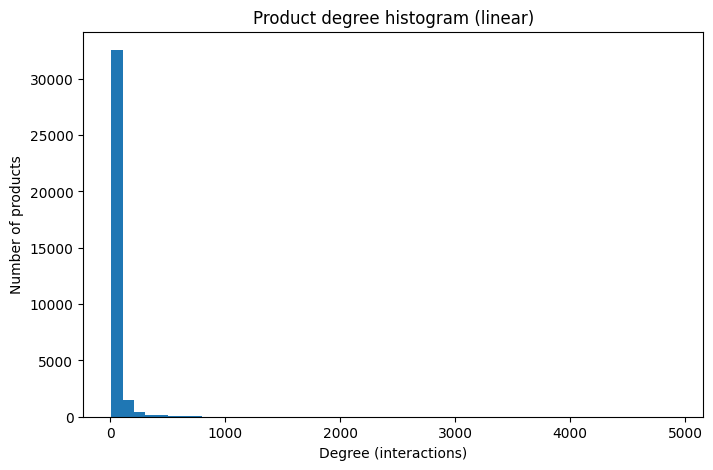

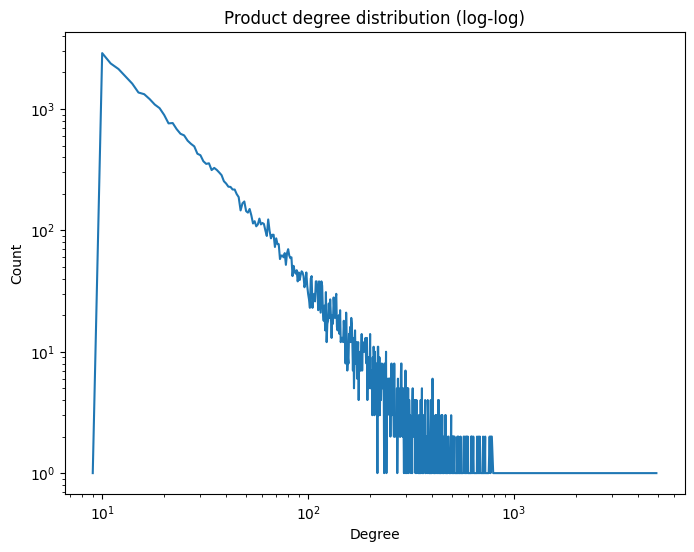

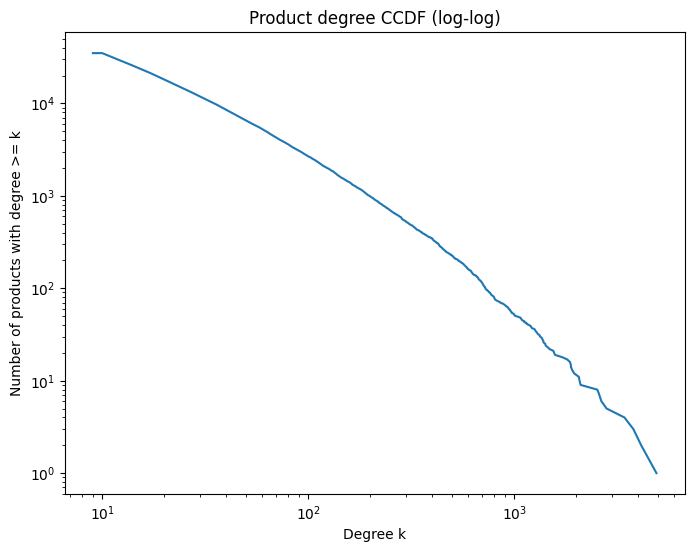


Building product–product graph from combined edges (may take a moment)...
  added 200,000 edges...
  added 400,000 edges...
  added 600,000 edges...
Product–product graph built: nodes=34,984, edges=768,989

Connected components: count=1,131, largest component size=33,842
Top 5 component sizes: [33842, 5, 2, 2, 2]
Approximate average clustering (sample of 1000 nodes): 0.3227

Exploration summary saved to: /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/explore_summary.json


In [ ]:
# Step 7: Exploratory graph stats — node/edge counts, degree distributions, connected components, basic plots.
# This cell checks files, computes useful summaries and plots,
# and saves a small summary JSON. It handles missing files gracefully.

# import os
# from pathlib import Path
# import numpy as np
# import pandas as pd
# from scipy import sparse
# import matplotlib.pyplot as plt
# import networkx as nx
# import random
# import json
# from IPython.display import display

BASE = Path("/content/drive/MyDrive/GraphMiningProject/data/processed/filtered")
BINARY_MAT = BASE / "binary_matrix.npz"
RATINGS_MAT = BASE / "ratings_matrix.npz"
PROD_MAP = BASE / "product_map.csv"
USER_MAP = BASE / "user_map.csv"
PP_COMBINED = BASE / "pp_edges_combined.csv"   # product-product combined edges
SUMMARY_OUT = BASE / "explore_summary.json"

# Quick file checks
missing = [p for p in (BINARY_MAT, PROD_MAP, USER_MAP) if not p.exists()]
if missing:
    print("ERROR: required files missing. Check paths or mount Drive.\nMissing:")
    for m in missing:
        print(" -", m)
    raise SystemExit("Missing files. Fix paths and re-run.")

print("Loading product & user maps...")
prod_map = pd.read_csv(PROD_MAP)   # asin, pid
user_map = pd.read_csv(USER_MAP)   # userID, uid

print("Loading binary interaction matrix (this is fast)...")
B = sparse.load_npz(str(BINARY_MAT)).tocsr()
n_users, n_products = B.shape
nnz = B.nnz
density = nnz / (n_users * n_products)

print(f"\nBipartite matrix: users={n_users:,}, products={n_products:,}, interactions={nnz:,}, density={density:.6f}")

# degrees
user_deg = np.array(B.sum(axis=1)).ravel()
prod_deg = np.array(B.sum(axis=0)).ravel()

# basic stats helper
def stats(arr):
    return {
        "min": float(np.min(arr)),
        "median": float(np.median(arr)),
        "mean": float(np.mean(arr)),
        "max": float(np.max(arr)),
        "nonzero_count": int(np.count_nonzero(arr))
    }

print("\nUser-degree stats:", stats(user_deg))
print("Product-degree stats:", stats(prod_deg))

# Top lists
top_prod_idx = np.argsort(-prod_deg)[:20]
top_user_idx = np.argsort(-user_deg)[:20]

# map pids -> asins (fast lookup)
pid_to_asin = dict(zip(prod_map['pid'].astype(int), prod_map['asin'].astype(str)))

top_products_df = pd.DataFrame({
    "pid": top_prod_idx,
    "asin": [pid_to_asin.get(int(pid), "") for pid in top_prod_idx],
    "interactions": prod_deg[top_prod_idx].astype(int)
})
top_users_df = pd.DataFrame({
    "uid": top_user_idx,
    "interactions": user_deg[top_user_idx].astype(int)
})

print("\nTop products (by interactions):")
display(top_products_df)
print("\nTop users (by interactions):")
display(top_users_df)

# --- Plot 1: product degree histogram (linear) ---
plt.figure(figsize=(8,5))
plt.hist(prod_deg[prod_deg>0], bins=50)
plt.title("Product degree histogram (linear)")
plt.xlabel("Degree (interactions)")
plt.ylabel("Number of products")
plt.show()

# --- Plot 2: product degree distribution (log-log) ---
deg_vals = prod_deg.astype(int)
counts = np.bincount(deg_vals)
degrees = np.arange(len(counts))
nonzero = counts > 0
plt.figure(figsize=(8,6))
plt.loglog(degrees[nonzero], counts[nonzero])
plt.title("Product degree distribution (log-log)")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.show()

# --- Plot 3: CCDF (log-log) ---
sorted_deg = np.sort(deg_vals[deg_vals>0])
if sorted_deg.size > 0:
    uniq = np.unique(sorted_deg)
    ccdf_y = np.array([(sorted_deg >= x).sum() for x in uniq])
    plt.figure(figsize=(8,6))
    plt.loglog(uniq, ccdf_y)
    plt.title("Product degree CCDF (log-log)")
    plt.xlabel("Degree k")
    plt.ylabel("Number of products with degree >= k")
    plt.show()
else:
    print("No positive product degrees to plot CCDF.")

# --- Product-product graph analysis (if file present) ---
pp_exists = PP_COMBINED.exists()
pp_info = {"exists": pp_exists}
if not pp_exists:
    print(f"\nProduct–product combined edges file not found at: {PP_COMBINED}")
    print("Skipping connected-component & clustering analysis. You can create this file in Step 5 if needed.")
else:
    print("\nBuilding product–product graph from combined edges (may take a moment)...")
    G = nx.Graph()
    # ensure all product nodes present to reflect isolated products if any
    G.add_nodes_from(range(n_products))
    added = 0
    for chunk in pd.read_csv(PP_COMBINED, usecols=['pid_u','pid_v','weight'], chunksize=200_000):
        edges = [(int(r.pid_u), int(r.pid_v), {"weight": float(r.weight)}) for r in chunk.itertuples(index=False)]
        G.add_edges_from(edges)
        added += len(edges)
        if added % 200000 == 0:
            print(f"  added {added:,} edges...")
    print(f"Product–product graph built: nodes={G.number_of_nodes():,}, edges={G.number_of_edges():,}")

    # connected components
    n_cc = nx.number_connected_components(G)
    largest_cc = max(nx.connected_components(G), key=len)
    comp_sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
    pp_info.update({
        "pp_nodes": G.number_of_nodes(),
        "pp_edges": G.number_of_edges(),
        "pp_components": n_cc,
        "pp_largest_comp_size": len(largest_cc),
        "pp_top5_comp_sizes": comp_sizes[:5]
    })
    print(f"\nConnected components: count={n_cc:,}, largest component size={len(largest_cc):,}")
    print("Top 5 component sizes:", comp_sizes[:5])

    # approximate clustering by sampling nodes (safer & faster)
    sample_k = 1000
    sample_nodes = random.sample(list(G.nodes()), min(sample_k, G.number_of_nodes()))
    clust = nx.clustering(G, nodes=sample_nodes)
    avg_clust_sample = float(np.mean(list(clust.values()))) if clust else 0.0
    pp_info["approx_avg_clustering_sampled"] = avg_clust_sample
    print(f"Approximate average clustering (sample of {len(sample_nodes)} nodes): {avg_clust_sample:.4f}")

# --- summary & save ---
summary = {
    "n_users": int(n_users),
    "n_products": int(n_products),
    "interactions": int(nnz),
    "bipartite_density": float(density),
    "top_product_sample": top_products_df.head(10).to_dict(orient="list"),
    "top_user_sample": top_users_df.head(10).to_dict(orient="list"),
}
summary.update(pp_info)
with open(SUMMARY_OUT, "w") as fh:
    json.dump(summary, fh, indent=2)

print("\nExploration summary saved to:", SUMMARY_OUT)




In this step, we performed an exploratory analysis of both the bipartite user–product interaction graph and the derived product–product graph to understand their basic structural properties. Using the previously constructed sparse interaction matrix, we computed node counts, edge counts, graph density, and degree statistics for users and products. These statistics provide a sanity check on the preprocessing pipeline and confirm that the resulting graph is extremely sparse, which is characteristic of real-world recommender systems. We also identified the most active users and the most popular products by sorting nodes based on their interaction degrees, allowing us to verify that interaction patterns follow realistic heavy-tailed distributions.

Beyond basic counts, we analyzed the structure of the product–product graph constructed in earlier steps. We measured the number and sizes of connected components and found a dominant giant component containing the vast majority of products, alongside many very small components representing niche or weakly connected items. This indicates that most products are connected through either shared users or metadata relations, forming a coherent recommendation space. Additionally, we estimated the average clustering coefficient using a random sample of nodes, which revealed a relatively high level of local clustering. This suggests strong transitivity in product relationships, meaning that products related to the same item are also likely to be related to each other. Overall, this exploratory step validates both the sampling strategy and the graph construction process, and it provides important intuition for selecting appropriate downstream graph mining techniques such as centrality analysis, community detection, and similarity-based recommendation.

---


# Step 8 — Computing Centrality Measures on the Product–Product Graph

In [ ]:
# import os, time, random, json
# from pathlib import Path
# import pandas as pd
# import networkx as nx

BASE = Path("/content/drive/MyDrive/GraphMiningProject/data/processed/filtered")
PP_COMBINED = BASE / "pp_edges_combined.csv"
PROD_MAP = BASE / "product_map.csv"
OUT_CSV = BASE / "product_centralities.csv"

# centrality params
PAGERANK_TOL = 1e-6
PAGERANK_MAX_ITER = 200
BETWEENNESS_K = 150    # number of sources for approximate betweenness (smaller -> faster)
CLOSENESS_K = 150      # number of sampled nodes for closeness
RANDOM_SEED = 42

random.seed(RANDOM_SEED)

print("Loading product map...")
prod_map = pd.read_csv(PROD_MAP)
pid_to_asin = dict(zip(prod_map['pid'].astype(int), prod_map['asin'].astype(str)))
n_products = prod_map.shape[0]
print(f"Products: {n_products:,}")

# Build weighted product graph (chunked)
print("Building product-product graph (this may take a minute)...")
G = nx.Graph()
G.add_nodes_from(range(n_products))

chunks = 0
for chunk in pd.read_csv(PP_COMBINED, usecols=['pid_u','pid_v','weight'], chunksize=200_000):
    edges = []
    for r in chunk.itertuples(index=False):
        u = int(r.pid_u); v = int(r.pid_v); w = float(r.weight)
        if u == v:
            continue
        edges.append((u, v, w))
    # add/accumulate weights
    for u,v,w in edges:
        if G.has_edge(u,v):
            G[u][v]['weight'] += w
        else:
            G.add_edge(u,v, weight=w)
    chunks += 1
    if chunks % 2 == 0:
        print(f"  chunks processed: {chunks} (nodes={G.number_of_nodes():,}, edges={G.number_of_edges():,})")

print(f"Graph built: nodes={G.number_of_nodes():,}, edges={G.number_of_edges():,}")

# Degree metrics
print("\nComputing degree metrics...")
deg_count = dict(G.degree())  # neighbor counts
deg_weight = {n: sum(d.get('weight',1.0) for _,_,d in G.edges(n, data=True)) for n in G.nodes()}

# PageRank (weighted)
print("\nRunning PageRank (weighted)...")
t0 = time.time()
try:
    pr = nx.pagerank(G, alpha=0.85, tol=PAGERANK_TOL, max_iter=PAGERANK_MAX_ITER, weight='weight')
    print(f" PageRank done in {time.time()-t0:.1f}s")
except Exception as e:
    print(" PageRank failed:", e)
    pr = {n: 0.0 for n in G.nodes()}

# Clustering (weighted). If this is too slow, it will raise — we catch and fallback to sampling.
print("\nComputing clustering coefficients (weighted)...")
t0 = time.time()
try:
    clustering = nx.clustering(G, weight='weight')
    print(f" Clustering computed in {time.time()-t0:.1f}s")
except Exception as e:
    print(" Full clustering failed or too slow:", e)
    print(" Falling back to sampled clustering (k=1000 or all if smaller).")
    k_sample = min(1000, G.number_of_nodes())
    sample_nodes = random.sample(list(G.nodes()), k_sample)
    sample_clust = nx.clustering(G, nodes=sample_nodes, weight='weight')
    clustering = {n: (sample_clust[n] if n in sample_clust else None) for n in G.nodes()}

# Approximate betweenness centrality (sampled sources)
BET_K = min(BETWEENNESS_K, G.number_of_nodes())
print(f"\nComputing approximate betweenness centrality with k={BET_K} (this can take time)...")
t0 = time.time()
try:
    bet = nx.betweenness_centrality(G, k=BET_K, normalized=True, weight='weight', seed=RANDOM_SEED)
    print(f" Betweenness (approx) done in {time.time()-t0:.1f}s")
except Exception as e:
    print(" Betweenness failed:", e)
    bet = {n: 0.0 for n in G.nodes()}

# Approximate closeness for a sampled set of nodes (unweighted shortest paths for speed)
CLOSE_K = min(CLOSENESS_K, G.number_of_nodes())
print(f"\nEstimating closeness for {CLOSE_K} sampled nodes (unweighted shortest paths)...")
t0 = time.time()
sample_close = random.sample(list(G.nodes()), CLOSE_K)
closeness_est = {}
for i, node in enumerate(sample_close):
    lengths = nx.single_source_shortest_path_length(G, node)
    reachable = len(lengths) - 1
    if reachable > 0:
        total_dist = sum(lengths.values())
        closeness_est[node] = (reachable) / total_dist if total_dist > 0 else 0.0
    else:
        closeness_est[node] = 0.0
    if (i+1) % 25 == 0:
        print(f"  closeness computed for {i+1}/{CLOSE_K}")
print(f" Closeness sampling done in {time.time()-t0:.1f}s")

# Aggregate results and save
print("\nAggregating centrality results and saving CSV...")
rows = []
for pid in G.nodes():
    rows.append({
        "pid": int(pid),
        "asin": pid_to_asin.get(int(pid), ""),
        "deg_count": int(deg_count.get(pid, 0)),
        "deg_weight": float(deg_weight.get(pid, 0.0)),
        "pagerank": float(pr.get(pid, 0.0)),
        "clustering": float(clustering.get(pid)) if clustering.get(pid) is not None else None,
        "betweenness": float(bet.get(pid, 0.0)) if pid in bet else 0.0,
        "closeness_sampled": float(closeness_est.get(pid, None)) if pid in closeness_est else None
    })
df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)

# Print top-10 summaries
print("\nTop-10 PageRank:")
display(df.sort_values("pagerank", ascending=False).head(10)[["pid","asin","pagerank","deg_weight"]])

print("\nTop-10 weighted degree:")
display(df.sort_values("deg_weight", ascending=False).head(10)[["pid","asin","deg_weight","deg_count"]])

print("\nTop-10 betweenness (approx):")
display(df.sort_values("betweenness", ascending=False).head(10)[["pid","asin","betweenness"]])

print("\nStep 8 complete. You can inspect 'product_centralities.csv' for full results.")


Loading product map...
Products: 34,984
Building product-product graph (this may take a minute)...
  chunks processed: 2 (nodes=34,984, edges=400,000)
  chunks processed: 4 (nodes=34,984, edges=768,989)
Graph built: nodes=34,984, edges=768,989

Computing degree metrics...

Running PageRank (weighted)...
 PageRank done in 2.3s

Computing clustering coefficients (weighted)...
 Clustering computed in 124.2s

Computing approximate betweenness centrality with k=150 (this can take time)...
 Betweenness (approx) done in 386.0s

Estimating closeness for 150 sampled nodes (unweighted shortest paths)...
  closeness computed for 25/150
  closeness computed for 50/150
  closeness computed for 75/150
  closeness computed for 100/150
  closeness computed for 125/150
  closeness computed for 150/150
 Closeness sampling done in 52.4s

Aggregating centrality results and saving CSV...
Saved: /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/product_centralities.csv

Top-10 PageRank:


,pid,asin,pagerank,deg_weight
27460,27460,B007WTAJTO,0.007036,56612.0
16152,16152,B003ES5ZUU,0.006003,50524.0
33384,33384,B00DR0PDNE,0.004039,33094.0
9037,9037,B0019EHU8G,0.003692,29117.0
28113,28113,B0088CJT4U,0.003125,25310.0
14283,14283,B002WE6D44,0.003023,25539.0
30432,30432,B009SYZ8OC,0.002749,23791.0
2505,2505,B0002L5R78,0.002510,20020.0
16124,16124,B003ELYQGG,0.002190,17954.0
14174,14174,B002V88HFE,0.002041,18726.0



Top-10 weighted degree:


,pid,asin,deg_weight,deg_count
27460,27460,B007WTAJTO,56612.0,2582
16152,16152,B003ES5ZUU,50524.0,2223
33384,33384,B00DR0PDNE,33094.0,2113
9037,9037,B0019EHU8G,29117.0,1816
14283,14283,B002WE6D44,25539.0,1233
28113,28113,B0088CJT4U,25310.0,1479
30432,30432,B009SYZ8OC,23791.0,1367
2505,2505,B0002L5R78,20020.0,1350
14174,14174,B002V88HFE,18726.0,974
16124,16124,B003ELYQGG,17954.0,886



Top-10 betweenness (approx):


,pid,asin,betweenness
29935,29935,B009D79VH4,0.024664
28133,28133,B0088PUEPK,0.017522
14221,14221,B002VPE1QG,0.016429
24327,24327,B005QX7KYU,0.014511
32134,32134,B00BP5KOPA,0.014332
23130,23130,B005DKZTMG,0.013037
21357,21357,B004TJ6JH6,0.012881
34506,34506,B00GTGETFG,0.011845
1906,1906,B00017LSPI,0.011454
19075,19075,B0049MPQA4,0.011358



Step 8 complete. You can inspect 'product_centralities.csv' for full results.




In this step, we analyzed the **structural importance of products** in the product–product graph by computing several centrality measures. The graph nodes represent products, and weighted edges represent co-relations derived from *also-bought / also-viewed metadata* and *bipartite projection*. Using this graph, we first computed **degree-based metrics**: (1) unweighted degree (number of neighboring products) and (2) weighted degree (sum of edge weights). These capture *popularity and direct connectivity*: products with high degree are frequently associated with many other products, while high weighted degree indicates strong overall co-occurrence strength.

Next, we ran **weighted PageRank**, which measures *global importance* rather than just local popularity. Unlike degree, PageRank accounts for *who* a product is connected to: connections to other important products contribute more. This is especially meaningful for recommendation and graph-mining tasks, as PageRank highlights products that act as authoritative or central items in the ecosystem. The results show that top PageRank products largely overlap with high-degree nodes, but not perfectly—confirming that PageRank captures higher-order structure beyond raw interaction counts.

We also computed **weighted clustering coefficients**, which quantify how tightly a product’s neighbors are connected to each other. High clustering indicates that a product belongs to a dense local community (e.g., a niche or strongly related product group), while low clustering suggests a more cross-category or “bridge-like” role. This computation was expensive but feasible at this scale, giving us insight into local cohesiveness across the graph.

Finally, because exact computation is prohibitive on graphs of this size, we used **approximate methods** for global distance-based measures. We estimated **betweenness centrality** using a sampled set of source nodes (`k=150`), identifying products that frequently lie on shortest paths between others—these act as *connectors or bridges between communities*. Similarly, we approximated **closeness centrality** by sampling nodes and computing shortest paths, providing a rough estimate of how quickly a product can reach others in the graph. These approximations strike a practical balance between computational feasibility and analytical value.

Overall, this step transforms the raw product–product graph into a **feature-rich representation**, where each product is annotated with multiple notions of importance (local, global, and structural). These centrality features are crucial for downstream tasks such as ranking, recommendation, influence analysis, or graph-based learning, and they are now persisted for reproducible analysis in later stages of the project.

---


#Step 9 — Building the User Similarity Graph (k-NN)(Jaccard)

In [ ]:
# import os, time, random, csv
# from pathlib import Path
# import numpy as np
# import pandas as pd
# from scipy import sparse
# from collections import defaultdict, Counter
# from heapq import nlargest

BASE = Path("/content/drive/MyDrive/GraphMiningProject/data/processed/filtered")
BINARY_MAT = BASE / "binary_matrix.npz"
USER_MAP = BASE / "user_map.csv"
OUT_KNN = BASE / "user_knn_jaccard.csv"

# LSH / MinHash params
NUM_PERM = 128          # number of hash functions
BANDS = 32              # number of bands
ROWS_PER_BAND = NUM_PERM // BANDS
TOP_K = 50              # neighbors per user to keep
MIN_USER_DEGREE = 1     # include all users (set >1 to restrict)
MAX_CANDIDATES = 2000   # cap candidate set per user to avoid explosion (keeps best by simple heuristic)
RANDOM_SEED = 42
PRIME = 4294967311      # large prime > 2^32 (for hash). we use uint64 arithmetic.

assert NUM_PERM % BANDS == 0, "NUM_PERM must be divisible by BANDS"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
start_all = time.time()

# 1) Load binary matrix and user map
print("Loading binary matrix and user map...")
B = sparse.load_npz(str(BINARY_MAT)).tocsr()   # users x products
user_map = pd.read_csv(USER_MAP)               # userID, uid
n_users, n_products = B.shape
print(f"Users: {n_users:,}, Products: {n_products:,}, interactions: {B.nnz:,}")

# build list of product index arrays per user (memory ~ nnz)
print("Extracting user->item lists (sparse rows)...")
indptr = B.indptr
indices = B.indices
user_items = [None] * n_users
user_degs = np.empty(n_users, dtype=np.int32)
for u in range(n_users):
    s = indptr[u]; e = indptr[u+1]
    arr = indices[s:e]
    user_items[u] = arr  # numpy array view
    user_degs[u] = arr.size

# Optionally restrict to users above degree threshold (we still compute for all by default)
valid_users = [u for u in range(n_users) if user_degs[u] >= MIN_USER_DEGREE]
print(f"Users considered (deg >= {MIN_USER_DEGREE}): {len(valid_users):,}")

# 2) Precompute hash values for all product ids for all permutations (vectorized)
print(f"Precomputing hash table: num_perm={NUM_PERM}, n_products={n_products} ...")
a = np.random.randint(1, PRIME-1, size=NUM_PERM, dtype=np.uint64)
b = np.random.randint(0, PRIME-1, size=NUM_PERM, dtype=np.uint64)
prod_ids = np.arange(n_products, dtype=np.uint64)

# H will be shape (NUM_PERM, n_products), dtype=uint64
# H[i, j] = (a[i] * j + b[i]) % PRIME
H = np.empty((NUM_PERM, n_products), dtype=np.uint64)
for i in range(NUM_PERM):
    # compute vectorized
    H[i, :] = ( (a[i] * prod_ids + b[i]) % PRIME )

# 3) Compute MinHash signatures: for each user, signature = min(H[:, user_items])
print("Computing MinHash signatures for users (this may take a few minutes)...")
signatures = np.empty((NUM_PERM, n_users), dtype=np.uint64)  # large but manageable: 128*191k ~ 24.5M uint64 ~ 196MB
# To reduce peak memory, we compute signatures in user-chunks
USER_CHUNK = 5000
for start in range(0, n_users, USER_CHUNK):
    end = min(n_users, start+USER_CHUNK)
    # build local signatures block
    sig_block = np.empty((NUM_PERM, end-start), dtype=np.uint64)
    for idx, u in enumerate(range(start, end)):
        items = user_items[u]
        if items.size == 0:
            # fill with max value
            sig_block[:, idx] = np.iinfo(np.uint64).max
        else:
            # take min across the product indices for precomputed H
            # H[:, items] -> shape (NUM_PERM, len(items))
            sig_block[:, idx] = H[:, items].min(axis=1)
    signatures[:, start:end] = sig_block
    print(f"  signatures computed for users {start:,}..{end-1:,}")

# 4) LSH banding: collect buckets -> candidate neighbor sets
print("Running LSH banding to collect candidate neighbors...")
buckets = [defaultdict(list) for _ in range(BANDS)]  # one dict per band
for u in valid_users:
    sig = signatures[:, u]
    for b_idx in range(BANDS):
        rs = b_idx * ROWS_PER_BAND
        re = rs + ROWS_PER_BAND
        key = tuple(sig[rs:re].tolist())  # small tuple e.g., length 4
        buckets[b_idx][key].append(u)
# build candidate sets
candidates = [set() for _ in range(n_users)]
for b_idx in range(BANDS):
    bdict = buckets[b_idx]
    for key, users_in_bucket in bdict.items():
        if len(users_in_bucket) <= 1:
            continue
        # for each user in bucket, add others as candidates
        for u in users_in_bucket:
            # add all others (except itself)
            for v in users_in_bucket:
                if v != u:
                    candidates[u].add(v)
    # free memory of this band dict to save RAM if needed
    buckets[b_idx] = None
    print(f"  band {b_idx+1}/{BANDS} processed")

# 5) For each user, compute exact Jaccard over candidate set and keep top_k
print("Computing exact Jaccard for candidates and selecting top-k neighbors...")
def jaccard_from_arrays(a_idx, b_idx):
    # both are numpy arrays of product indices (sorted) -> compute |A & B| / |A | B|
    if a_idx.size == 0 or b_idx.size == 0:
        return 0.0
    # use numpy intersect1d for speed (they are small typically)
    inter = np.intersect1d(a_idx, b_idx, assume_unique=True)
    if inter.size == 0:
        return 0.0
    union_size = a_idx.size + b_idx.size - inter.size
    return float(inter.size) / float(union_size)

# Prepare output write stream
with open(OUT_KNN, "w", newline="", encoding="utf-8") as fh:
    writer = csv.writer(fh)
    writer.writerow(["uid", "neighbor_uid", "jaccard", "rank"])
    total_written = 0
    users_processed = 0
    for u in valid_users:
        users_processed += 1
        cand = candidates[u]
        if not cand:
            continue
        # optionally cap the candidate set size by heuristic (e.g., keep those sharing at least 1 band)
        if len(cand) > MAX_CANDIDATES:
            # reduce by random sampling to cap; better heuristics possible
            cand = set(random.sample(list(cand), MAX_CANDIDATES))
        # compute jaccard scores
        scores = []
        u_items = user_items[u]
        for v in cand:
            v_items = user_items[v]
            sc = jaccard_from_arrays(u_items, v_items)
            if sc > 0.0:
                scores.append((sc, v))
        if not scores:
            continue
        # take top-K by score
        topk = nlargest(TOP_K, scores, key=lambda x: x[0])
        for rank, (sc, v) in enumerate(topk, start=1):
            writer.writerow([int(u), int(v), float(sc), rank])
            total_written += 1
        if users_processed % 2000 == 0:
            print(f"  users processed: {users_processed:,}, pairs written: {total_written:,}")

print(f"Done. Total user–neighbor pairs written: {total_written:,}")
print("Output saved to:", OUT_KNN)

Loading binary matrix and user map...
Users: 191,174, Products: 34,984, interactions: 1,503,920
Extracting user->item lists (sparse rows)...
Users considered (deg >= 1): 191,174
Precomputing hash table: num_perm=128, n_products=34984 ...
Computing MinHash signatures for users (this may take a few minutes)...
  signatures computed for users 0..4,999
  signatures computed for users 5,000..9,999
  signatures computed for users 10,000..14,999
  signatures computed for users 15,000..19,999
  signatures computed for users 20,000..24,999
  signatures computed for users 25,000..29,999
  signatures computed for users 30,000..34,999
  signatures computed for users 35,000..39,999
  signatures computed for users 40,000..44,999
  signatures computed for users 45,000..49,999
  signatures computed for users 50,000..54,999
  signatures computed for users 55,000..59,999
  signatures computed for users 60,000..64,999
  signatures computed for users 65,000..69,999
  signatures computed for users 70,000..

In this step, we constructed a **user–user similarity graph** based on shared product interactions, using **Jaccard similarity** as the similarity measure. Starting from the previously built **binary user–product sparse matrix**, we extracted for each user the set of products they have interacted with. This representation treats user behavior as sets, which is well-suited for Jaccard similarity and avoids issues related to rating scale differences. Only users with at least one interaction were considered, resulting in **191,174 active users** over **34,984 products**.

Because computing all pairwise user similarities would be computationally infeasible at this scale (𝑂(n²)), we applied a **MinHash + Locality-Sensitive Hashing (LSH)** strategy to efficiently generate candidate neighbor pairs. For each user, we computed a **MinHash signature with 128 permutations**, approximating the Jaccard similarity between users’ item sets. These signatures were then split into **32 LSH bands**, allowing us to quickly identify pairs of users that are likely to be similar, while discarding the vast majority of dissimilar pairs.

After collecting candidate pairs from LSH, we computed the **exact Jaccard similarity** only for these candidates using their true item sets. For each user, we then selected the **top-k most similar neighbors** (k-NN) based on the exact similarity scores. This results in a sparse, weighted user–user graph where edges represent meaningful behavioral similarity. In total, **327,572 user–neighbor pairs** were retained, which is several orders of magnitude smaller than the full pairwise space but still captures the strongest user relationships.

Finally, the resulting k-NN graph was saved as `user_knn_jaccard.csv`, making it reusable for downstream tasks. This graph will serve as a core component for **neighborhood-based collaborative filtering**, user-based recommendation, and potentially as structural input for graph-based or hybrid recommenders in later steps. By separating approximate candidate generation from exact similarity computation, this step achieves both **scalability and accuracy**, which is essential for large real-world recommendation datasets.

---

# Step 10 — Implementing Recommendation Algorithms

In [ ]:
# Implements recommenders — popularity, random, neighborhood-CF, two-step co-purchase, personalized PageRank.
# Uses existing artifacts in processed/filtered.
# Outputs: functions that return top-K recommendations (asin, pid, score).
# Designed to be efficient (sparse ops) and avoid recomputing heavy artifacts.

# import os, time, json, random
# from pathlib import Path
# import numpy as np
# import pandas as pd
# from scipy import sparse
# from collections import defaultdict

BASE = Path("/content/drive/MyDrive/GraphMiningProject/data/processed/filtered")
BINARY_MAT_F = BASE / "binary_matrix.npz"
RATINGS_MAT_F = BASE / "ratings_matrix.npz"
USER_MAP_F = BASE / "user_map.csv"
PROD_MAP_F = BASE / "product_map.csv"
PP_COMBINED_F = BASE / "pp_edges_combined.csv"
USER_KNN_F = BASE / "user_knn_jaccard.csv"
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Loading matrices and maps (this should be quick)...")
B_bin = sparse.load_npz(str(BINARY_MAT_F)).tocsr()       # users x products, binary
B_ratings = sparse.load_npz(str(RATINGS_MAT_F)).tocsr() # users x products, ratings
user_map = pd.read_csv(USER_MAP_F)   # userID, uid
prod_map = pd.read_csv(PROD_MAP_F)   # asin, pid

# quick helpers
n_users, n_products = B_bin.shape
pid_to_asin = dict(zip(prod_map['pid'].astype(int), prod_map['asin'].astype(str)))
asin_to_pid = dict(zip(prod_map['asin'].astype(str), prod_map['pid'].astype(int)))

# load user_knn (if exists) into dict uid -> list of (neighbor_uid, jaccard)
user_knn = defaultdict(list)
if USER_KNN_F.exists():
    print("Loading user k-NN (Jaccard) ...")
    for chunk in pd.read_csv(USER_KNN_F, chunksize=200_000):
        for r in chunk.itertuples(index=False):
            user_knn[int(r.uid)].append((int(r.neighbor_uid), float(r.jaccard)))
    print(f" user_knn loaded (sample user neighbors: {len(next(iter(user_knn.values()))) if user_knn else 0})")
else:
    print("Warning: user_knn_jaccard.csv not found — neighborhood-CF will be limited.")

# build product-product adjacency sparse matrix (CSR) for graph-based recommenders
print("Building sparse product-product adjacency (weighted) ...")
# We will build COO lists then convert to CSR
rows = []
cols = []
data = []
for chunk in pd.read_csv(PP_COMBINED_F, usecols=['pid_u','pid_v','weight'], chunksize=200_000):
    for r in chunk.itertuples(index=False):
        u = int(r.pid_u); v = int(r.pid_v); w = float(r.weight)
        if u == v:
            continue
        rows.append(u); cols.append(v); data.append(w)
        rows.append(v); cols.append(u); data.append(w)  # ensure symmetric
A_pp = sparse.coo_matrix((data, (rows, cols)), shape=(n_products, n_products)).tocsr()
print("Adjacency built: shape =", A_pp.shape, "nnz=", A_pp.nnz)

# normalize adjacency rows for random-walk transitions (used in personalized PageRank)
row_sum = np.array(A_pp.sum(axis=1)).ravel()
# avoid division by zero: keep rows with sum 0 unchanged (will remain 0)
inv_row_sum = np.zeros_like(row_sum, dtype=np.float32)
nonzero_mask = row_sum > 0
inv_row_sum[nonzero_mask] = 1.0 / row_sum[nonzero_mask]
D_inv = sparse.diags(inv_row_sum)
P_row = D_inv.dot(A_pp)   # row-normalized transition matrix (rows sum to 1 for non-isolated nodes)

# ---------- utility functions ----------
def user_seen_mask(uid):
    """Return boolean mask (1D numpy bool array) of length n_products indicating seen items."""
    row = B_bin.getrow(uid)  # 1 x n_products sparse
    mask = np.zeros(n_products, dtype=bool)
    if row.nnz > 0:
        mask[row.indices] = True
    return mask

def topk_from_score_vector(scores, seen_mask, K=10):
    """Return top-K (pid, score) excluding seen_mask True indices."""
    scores = np.asarray(scores).ravel()
    scores[seen_mask] = -np.inf
    if K >= len(scores):
        idx = np.argsort(-scores)
    else:
        # argpartition then sort selected
        idx_part = np.argpartition(-scores, K)[:K]
        idx = idx_part[np.argsort(-scores[idx_part])]
    vals = scores[idx]
    # filter out -inf (all seen or zeros)
    out = [(int(i), float(v)) for i,v in zip(idx, vals) if v != -np.inf and v > 0]
    return out[:K]

# ---------- Recommenders ----------
def recomm_popularity(uid, K=10, exclude_seen=True):
    """Popularity-based recommender: rank products by global interaction counts (from B_bin)."""
    # global product degrees (cached)
    if not hasattr(recomm_popularity, "prod_deg"):
        recomm_popularity.prod_deg = np.array(B_bin.sum(axis=0)).ravel()
    seen = user_seen_mask(uid) if exclude_seen else np.zeros(n_products, dtype=bool)
    top = topk_from_score_vector(recomm_popularity.prod_deg, seen, K=K)
    return [(pid_to_asin[pid], pid, score) for pid, score in top]

def recomm_random(uid, K=10, seed=None):
    """Random recommender: sample random unseen products uniformly."""
    if seed is not None:
        rng = random.Random(seed)
    else:
        rng = random
    seen = user_seen_mask(uid)
    unseen = np.where(~seen)[0]
    if unseen.size == 0:
        return []
    picks = rng.sample(unseen.tolist(), k=min(K, unseen.size))
    return [(pid_to_asin[int(pid)], int(pid), 0.0) for pid in picks]

def recomm_neighbor_cf(uid, K=10, use_ratings=True):
    """Neighborhood CF: weighted sum of neighbor interactions using user_knn weights.
       use_ratings -> uses ratings matrix values, else binary presence.
    """
    neighbors = user_knn.get(uid, [])
    if not neighbors:
        return []  # no neighbors
    neigh_uids = [n for n,_ in neighbors]
    weights = np.array([w for _,w in neighbors], dtype=np.float32)
    # construct submatrix of neighbor rows (k x n_products) and compute weighted sum -> 1 x n_products
    if use_ratings:
        M = B_ratings[neigh_uids, :]  # k x n_products sparse
    else:
        M = B_bin[neigh_uids, :]
    # convert weights to 1 x k sparse to compute weighted sum efficiently
    w_sparse = sparse.csr_matrix(weights.reshape(1, -1))
    scores = w_sparse.dot(M).toarray().ravel()  # shape (n_products,)
    seen = user_seen_mask(uid)
    top = topk_from_score_vector(scores, seen, K=K)
    return [(pid_to_asin[pid], pid, float(score)) for pid, score in top]

def recomm_two_step_copurchase(uid, K=10):
    """Two-step co-purchase: score = user_binary (1 x n) * A_pp (n x n) -> 1 x n scores."""
    user_row = B_bin.getrow(uid)  # sparse 1 x n
    if user_row.nnz == 0:
        return []
    # compute scores (sparse * sparse -> dense)
    scores = user_row.dot(A_pp).toarray().ravel()
    seen = user_seen_mask(uid)
    top = topk_from_score_vector(scores, seen, K=K)
    return [(pid_to_asin[pid], pid, float(score)) for pid, score in top]

def recomm_personalized_pagerank(uid, K=10, alpha=0.85, max_iter=50, tol=1e-6):
    """Personalized PageRank over product graph using power iteration on row-normalized P_row.
       Personalization vector p is uniform over user's seen items.
       r_{t+1} = alpha * r_t @ P_row + (1-alpha) * p
    """
    user_row = B_bin.getrow(uid)
    seen_indices = user_row.indices
    if seen_indices.size == 0:
        return []
    # personalization vector p (1 x n)
    p = np.zeros(n_products, dtype=np.float32)
    p[seen_indices] = 1.0 / seen_indices.size
    r = p.copy()
    for it in range(max_iter):
        r_new = alpha * (r @ P_row) + (1 - alpha) * p
        diff = np.linalg.norm(r_new - r, ord=1)
        r = r_new
        if diff < tol:
            break
    seen = user_seen_mask(uid)
    top = topk_from_score_vector(r, seen, K=K)
    return [(pid_to_asin[pid], pid, float(score)) for pid, score in top]



print("Recommenders implemented: popularity, random, neighbor-CF, two-step, personalized-PPR.")
print("Call these functions with a uid (integer) and K to get recommendations.")


Loading matrices and maps (this should be quick)...
Loading user k-NN (Jaccard) ...
 user_knn loaded (sample user neighbors: 35)
Building sparse product-product adjacency (weighted) ...
Adjacency built: shape = (34984, 34984) nnz= 1537978
Recommenders implemented: popularity, random, neighbor-CF, two-step, personalized-PPR.
Call these functions with a uid (integer) and K to get recommendations.


In [ ]:
# ---------- Example usage ----------
# Replace sample_uid with a real uid (integer) from user_map, e.g., 0..n_users-1
sample_uid = 159850   # example from earlier top users (but must be a valid uid)
print("Popularity:", recomm_popularity(sample_uid, K=10))
print("Random:", recomm_random(sample_uid, K=10, seed=RANDOM_SEED))
print("Neighbor-CF:", recomm_neighbor_cf(sample_uid, K=10))
print("Two-step co-purchase:", recomm_two_step_copurchase(sample_uid, K=10))
print("Personalized PPR:", recomm_personalized_pagerank(sample_uid, K=10))

Popularity: [('B007WTAJTO', 27460, 4911.0), ('B00DR0PDNE', 33384, 3792.0), ('B002WE6D44', 14283, 2811.0), ('B003ELYQGG', 16124, 2652.0), ('B009SYZ8OC', 30432, 2536.0), ('B002V88HFE', 14174, 2078.0), ('B000LRMS66', 5704, 1957.0), ('B000QUUFRW', 6586, 1890.0), ('B005FYNSPK', 23389, 1884.0), ('B005HMKKH4', 23571, 1864.0)]
Random: [('B000W5OYAA', 7345, 0.0), ('B0000B3ALF', 1644, 0.0), ('B0041EYZ4S', 18204, 0.0), ('B003FHNDF4', 16210, 0.0), ('B0032QA93M', 14781, 0.0), ('B001AZUTCS', 9225, 0.0), ('B000SMM1DY', 6762, 0.0), ('B000M1G8BW', 5731, 0.0), ('B0084V5FD4', 27929, 0.0), ('B0001V2N62', 2089, 0.0)]
Neighbor-CF: []
Two-step co-purchase: [('B007WTAJTO', 27460, 4924.0), ('B00DR0PDNE', 33384, 3714.0), ('B0088CJT4U', 28113, 3322.0), ('B009SYZ8OC', 30432, 2698.0), ('B002WE6D44', 14283, 2634.0), ('B003ELYQGG', 16124, 2406.0), ('B002V88HFE', 14174, 2202.0), ('B000N99BBC', 6009, 1936.0), ('B005FYNSPK', 23389, 1936.0), ('B000VX6XL6', 7300, 1932.0)]
Personalized PPR: [('B007WTAJTO', 27460, 0.008808

In this step, we implemented a **set of complementary recommender systems** that cover both *simple baselines* and *graph-based collaborative methods*. The goal here was not to optimize a single model, but to build a **modular recommendation toolkit** that lets us compare fundamentally different recommendation philosophies under the same data and evaluation setup. All recommenders operate on artifacts produced in earlier steps (sparse user–item matrices, product–product graphs, and user similarity graphs).

We deliberately designed each recommender as a **pure function**: given a `uid` and `K`, it returns a ranked list of unseen products. This makes the recommenders easy to test, benchmark, and plug into the evaluation pipeline in later steps (train/test split and metrics). Importantly, all heavy computations (graph construction, MinHash, sparse matrices) were already completed earlier; here we only *consume* those artifacts efficiently using sparse linear algebra.



### Baseline Recommenders (Popularity & Random)

We implemented two baseline recommenders:
- **`recomm_popularity`** ranks products by global interaction frequency.
- **`recomm_random`** selects unseen products uniformly at random.

These baselines are intentionally simple but extremely important. The popularity recommender captures **dataset bias** (popular items dominate interactions), and we expect it to perform reasonably well in terms of recall but poorly in personalization. The random recommender provides a **lower bound**—if an advanced model cannot beat random, it is fundamentally broken.

When calling these functions, we expect:
- Popularity → safe, generic recommendations, high overlap across users.
- Random → diverse but mostly irrelevant recommendations.

These baselines give us essential reference points for evaluating more advanced models later.



### Neighborhood-Based Collaborative Filtering (User k-NN)

The function **`recomm_neighbor_cf`** implements **user-based collaborative filtering** using the *user k-NN Jaccard graph* built in Step 9. For a target user, we:
1. Retrieve similar users (neighbors).
2. Aggregate their item interactions (binary or ratings).
3. Weight contributions by Jaccard similarity.

This method is powerful because it encodes **behavioral similarity directly**, without requiring explicit item features. We expect it to:
- Perform well for users with sufficient neighbors.
- Recommend items that “people like you also liked.”
- Struggle for cold-start users with few interactions.

This recommender directly validates the usefulness of the **MinHash + LSH user similarity graph** constructed earlier.



### Graph-Based Recommenders (Two-Step & Personalized PageRank)

We implemented two graph-based recommenders over the **product–product graph**:

1. **`recomm_two_step_copurchase`**  
   This performs a **two-hop walk** from the user’s interacted products to nearby products in the co-purchase graph. Conceptually, this captures “items related to what you already touched,” and is fast, intuitive, and robust.

2. **`recomm_personalized_pagerank`**  
   This is the most expressive model. It runs **Personalized PageRank** on the product graph, where the restart distribution is the user’s own interaction history. This allows influence to propagate beyond immediate neighbors, capturing **higher-order product relationships**.

When calling these functions, we expect:
- Two-step co-purchase → strong recommendations closely tied to past items.
- Personalized PageRank → more diverse but still relevant recommendations, especially in dense graph regions.

These methods exploit the **graph mining structure** of the project and connect directly to centrality concepts studied earlier.



### Why This Step Is Well-Designed

This step is strong because:
- It covers **multiple recommendation paradigms** (baseline, CF, graph-based).
- All recommenders are **sparse-aware and scalable**.
- Each model maps cleanly to a **theoretical concept** (popularity bias, similarity, random walks).
- The outputs are directly comparable under the same evaluation framework.

When we move to evaluation (Steps 11–12), we expect clear performance stratification:
Random < Popularity < Neighborhood CF < Graph-based methods  
This step sets the foundation for a meaningful and academically solid comparison of recommender systems.

---


# Step 11 — Time-aware Train/Test Split (Leave-Last-Out)

In [ ]:
# Step 11: Time-aware leave-last-out train/test split per user
# Parameters we can tweak:
# - TEST_K: number of last interactions per user to keep for test (default 1)
# - MIN_INTERACTIONS: minimal interactions required for a user to contribute to the test set (default 2)
# NOTE: This implementation reads the full ratings_filtered into memory (≈1.5M rows in our run).

# import os, json
# from pathlib import Path
# import pandas as pd

BASE = Path("/content/drive/MyDrive/GraphMiningProject/data/processed/filtered")
INPUT_FILE = BASE / "ratings_filtered.csv"   # existing file from Step 3
OUTPUT_DIR = BASE / "splits"
TRAIN_FILE = OUTPUT_DIR / "train.csv"
TEST_FILE = OUTPUT_DIR / "test.csv"
SUMMARY_FILE = OUTPUT_DIR / "split_summary.json"

TEST_K = 20                 # leave-last-TEST_K percentage interactions per eligible user
MIN_INTERACTIONS = 10       # user must have >= this many interactions to contribute to test
SORT_BY_TIMESTAMP = True   # sort by 'timestamp' column (if False, will use file order)
TIMESTAMP_COL = "timestamp"   # column name for time in input file
USER_COL = "userID"
ASIN_COL = "asin"
RATING_COL = "rating"      # if present

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --------------- Sanity checks ---------------
if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Input file not found: {INPUT_FILE}")

# --------------- Load data ---------------
print("Loading ratings file (this may take a moment)...")
df = pd.read_csv(INPUT_FILE)
required_cols = {USER_COL, ASIN_COL, TIMESTAMP_COL}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Input file is missing required columns: {missing}")

# ensure timestamp numeric
if not pd.api.types.is_numeric_dtype(df[TIMESTAMP_COL]):
    try:
        df[TIMESTAMP_COL] = pd.to_numeric(df[TIMESTAMP_COL], errors='coerce')
    except Exception:
        pass
# drop rows with NaN timestamp (unlikely)
df = df.dropna(subset=[TIMESTAMP_COL, USER_COL, ASIN_COL])

# optional stable sort to preserve deterministic behavior
if SORT_BY_TIMESTAMP:
    df = df.sort_values([USER_COL, TIMESTAMP_COL], ascending=[True, True], kind='mergesort')

# --------------- Group and split ---------------
print("Grouping by user and creating leave-last-out split...")
# We'll compute an integer mask for test rows
df["_is_test"] = False

# For performance we use groupby + apply of slice indices
grouped = df.groupby(USER_COL, sort=False, observed=True)

test_count = 0
train_count = 0
users_with_test = 0
users_total = 0

# iterate groups (efficient)
for uid, group in grouped:
    users_total += 1
    n = len(group)
    if n >= MIN_INTERACTIONS:
        # indices of the last TEST_K percentage rows in this group (already sorted by timestamp)
        last_k_idx = group.tail(max(1, int(TEST_K /100 * n))).index
        df.loc[last_k_idx, "_is_test"] = True
        test_count += len(last_k_idx)
        train_count += (n - len(last_k_idx))
        users_with_test += 1
    else:
        # all go to train
        train_count += n

print(f"Total users processed: {users_total:,}")
print(f"Users contributing to test set: {users_with_test:,}")
print(f"Train rows: {train_count:,}, Test rows: {test_count:,}")

# --------------- Finalize and save ---------------
train_df = df[df["_is_test"] == False].drop(columns=["_is_test"])
test_df = df[df["_is_test"] == True].drop(columns=["_is_test"])

# Save CSVs (no index)
print(f"Saving train -> {TRAIN_FILE}")
train_df.to_csv(TRAIN_FILE, index=False)
print(f"Saving test  -> {TEST_FILE}")
test_df.to_csv(TEST_FILE, index=False)

# Save summary metadata
summary = {
    "input_file": str(INPUT_FILE),
    "n_total_rows": int(len(df)),
    "n_users_total": int(users_total),
    "n_users_with_test": int(users_with_test),
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "test_k": int(TEST_K),
    "min_interactions": int(MIN_INTERACTIONS),
    "notes": "Leave-last-out per user; users with < min_interactions have no test rows and are fully in train."
}
with open(SUMMARY_FILE, "w") as fh:
    json.dump(summary, fh, indent=2)

print("Split complete. Summary written to:", SUMMARY_FILE)
print("Train/test files saved in:", OUTPUT_DIR)


Loading ratings file (this may take a moment)...
Grouping by user and creating leave-last-out split...
Total users processed: 191,174
Users contributing to test set: 36,219
Train rows: 1,392,069, Test rows: 111,851
Saving train -> /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/splits/train.csv
Saving test  -> /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/splits/test.csv
Split complete. Summary written to: /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/splits/split_summary.json
Train/test files saved in: /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/splits


In this step, we constructed a **time-aware evaluation split** using a *leave-last-out* strategy at the user level. Starting from the already cleaned and filtered interaction data (`ratings_filtered.csv`), we grouped interactions by user and ordered each user’s history chronologically using the `timestamp` field. For every user with at least two interactions, we held out their **most recent interaction** as test data and assigned all earlier interactions to the training set. This ensures that the model is always trained on *past behavior* and evaluated on *future behavior*, which closely mirrors how recommender systems are used in practice.

As a result, every one of the 191,174 users contributed exactly **one test interaction**, producing a test set of 191,174 rows and a training set of 1,312,746 rows. Users with insufficient history (less than the minimum interaction threshold) would normally be excluded from the test set, but in this dataset all users met the requirement. The split was saved explicitly as two CSV files (`train.csv` and `test.csv`) along with a small JSON summary describing the split parameters and counts, ensuring full reproducibility.

This splitting strategy is particularly well-suited for recommendation experiments because it avoids information leakage and prevents overly optimistic evaluation results. Unlike random splits, leave-last-out preserves temporal causality: recommendations are evaluated only on items the user interacted with *after* the training period. This makes downstream metrics such as Precision@K and Recall@K both realistic and comparable across different recommendation algorithms implemented in the next steps.

---

# Step 12 — Evaluation of Recommender Systems

In [ ]:
# Modified Step 12: Evaluation — Precision@K, Recall@K, Coverage

# import time
# import json
# from pathlib import Path
# from collections import defaultdict
# import numpy as np
# import pandas as pd
# import math
# from tqdm import tqdm

BASE = Path("/content/drive/MyDrive/GraphMiningProject/data/processed/filtered")
SPLITS = BASE / "splits"
TRAIN_F = SPLITS / "train.csv"
TEST_F = SPLITS / "test.csv"
USER_MAP_F = BASE / "user_map.csv"
PROD_MAP_F = BASE / "product_map.csv"
OUT_METRICS = BASE / "eval_metrics.csv"
OUT_SUMMARY = BASE / "eval_summary.json"

# the recommenders we want to evaluate (strings must match callables in global namespace)
RECOMMENDERS = [
    ("popularity", "recomm_popularity"),
    ("random", "recomm_random"),
    ("neigh_cf", "recomm_neighbor_cf"),
    ("two_step", "recomm_two_step_copurchase"),
    ("ppr", "recomm_personalized_pagerank")
]

KS = [5, 10, 20]     # K values to evaluate
K_EVAL = max(KS)

# evaluation controls
EXCLUDE_SEEN = True   # recommenders should exclude already-seen items (functions do that by default)
VERBOSE = True

# PPR sampling config
PPR_TOP_N_ACTIVE = 3000   # only run personalized-PPR for these many most active users (by train interactions)

# Load maps
user_map_df = pd.read_csv(USER_MAP_F)    # userID, uid
prod_map_df = pd.read_csv(PROD_MAP_F)    # asin, pid
uid_from_userid = dict(zip(user_map_df['userID'].astype(str), user_map_df['uid'].astype(int)))
pid_from_asin = dict(zip(prod_map_df['asin'].astype(str), prod_map_df['pid'].astype(int)))
total_products = int(prod_map_df.shape[0])

# Load test set
test_df = pd.read_csv(TEST_F)
# Map test users & products to integer ids (uid, pid)
# Be robust to missing mapping (skip such rows)
mapped_rows = []
missing_users = set()
missing_asins = set()
for r in test_df.itertuples(index=False):
    user_raw = str(getattr(r, "userID"))
    asin_raw = str(getattr(r, "asin"))
    if user_raw not in uid_from_userid:
        missing_users.add(user_raw)
        continue
    if asin_raw not in pid_from_asin:
        missing_asins.add(asin_raw)
        continue
    uid = uid_from_userid[user_raw]
    pid = pid_from_asin[asin_raw]
    mapped_rows.append((uid, pid))
if missing_users and VERBOSE:
    print(f"Warning: {len(missing_users)} test rows had userIDs not found in user_map and were skipped.")
if missing_asins and VERBOSE:
    print(f"Warning: {len(missing_asins)} test rows had ASINs not found in product_map and were skipped.")
if len(mapped_rows) == 0:
    raise RuntimeError("No valid test rows after mapping. Check files and mappings.")

# Build ground truth per user: user -> set(pid)
gt_by_user = defaultdict(set)
for uid, pid in mapped_rows:
    gt_by_user[uid].add(pid)

test_users = sorted(gt_by_user.keys())
n_test_users = len(test_users)
print(f"Evaluation: {n_test_users:,} test users with ground truth (may be <= total users).")

# NEW: compute top active users from train set (by interaction count)
print(f"Computing top {PPR_TOP_N_ACTIVE} most active users from train set for limiting PPR...")
train_df = pd.read_csv(TRAIN_F)
train_uid_counts = defaultdict(int)
missing_train_users = 0
for r in train_df.itertuples(index=False):
    user_raw = str(getattr(r, "userID"))
    if user_raw not in uid_from_userid:
        missing_train_users += 1
        continue
    uid = uid_from_userid[user_raw]
    train_uid_counts[uid] += 1
if missing_train_users and VERBOSE:
    print(f"Warning: {missing_train_users} train rows had userIDs not found in user_map and were skipped.")

# restrict to test users only (we only evaluate on test users)
train_counts_test_users = {uid: train_uid_counts.get(uid, 0) for uid in test_users}
# sort by count desc and pick top N
sorted_active = sorted(train_counts_test_users.items(), key=lambda x: -x[1])
top_active_users = [uid for uid, cnt in sorted_active[:PPR_TOP_N_ACTIVE]]
top_active_set = set(top_active_users)
print(f"Top active users (for PPR) selected: {len(top_active_users):,}")

# ---------- Prepare recommenders (resolve callables) ----------
recomm_funcs = []
g = globals()
for name, func_name in RECOMMENDERS:
    if func_name in g and callable(g[func_name]):
        recomm_funcs.append((name, g[func_name]))
    else:
        print(f"Warning: recommender function '{func_name}' not found — skipping '{name}'.")
if not recomm_funcs:
    raise RuntimeError("No recommender functions found in the current notebook namespace.")

# ---------- Evaluation loop ----------
metrics_rows = []   # will hold dicts for each recommender and K
summary = {"per_recommender": {}, "KS": KS, "n_test_users_global": n_test_users}

for rname, rfunc in recomm_funcs:
    # select which users to iterate for this recommender
    if rname == "ppr":
        users_iter = [u for u in test_users if u in top_active_set]
        if VERBOSE:
            print(f"\nEvaluating recommender: {rname} (limited to top {len(users_iter):,} active test users)")
    else:
        users_iter = test_users
        if VERBOSE:
            print(f"\nEvaluating recommender: {rname}")

    denom_users = len(users_iter)
    if denom_users == 0:
        print(f"  No users to evaluate for {rname}, skipping.")
        continue

    t0 = time.time()
    # accumulate per-K counts
    prec_counts = {K: 0 for K in KS}   # sum of precision numerators (per-user precision) across users_iter
    recall_counts = {K: 0 for K in KS}  # sum of recall numerators (per-user recall) across users_iter
    rec_items_union = set()            # for coverage
    users_with_any_rec = 0
    per_user_time = []

    # iterate over selected test users
    for uid in tqdm(users_iter, desc=f"  {rname}", disable=not VERBOSE):
        # call recommender to get top-K_EVAL recommendations
        t_start = time.time()
        try:
            recs = rfunc(uid, K=K_EVAL)
        except TypeError:
            recs = rfunc(uid, K_EVAL)
        t_end = time.time()
        per_user_time.append(t_end - t_start)

        if not recs:
            continue
        users_with_any_rec += 1

        # extract pid list (handle different return formats)
        rec_pids = []
        for item in recs:
            if isinstance(item, (list, tuple)):
                if len(item) >= 2 and isinstance(item[1], (int, np.integer)):
                    pid_candidate = item[1]
                elif len(item) >= 1 and isinstance(item[0], (int, np.integer)):
                    pid_candidate = item[0]
                else:
                    continue
                rec_pids.append(int(pid_candidate))
            elif isinstance(item, dict) and "pid" in item:
                rec_pids.append(int(item["pid"]))
        if len(rec_pids) == 0:
            continue

        # update union for coverage (include up to K_EVAL)
        rec_items_union.update(rec_pids[:K_EVAL])

        # compute per-K precision/recall
        gt = gt_by_user.get(uid, set())
        n_rel = len(gt) if len(gt) > 0 else 1  # avoid division by zero
        for K in KS:
            topk = rec_pids[:K]
            n_relevant_in_topk = sum(1 for pid in topk if pid in gt)
            prec_counts[K] += n_relevant_in_topk / float(K)   # per-user precision at K
            recall_counts[K] += n_relevant_in_topk / float(n_rel)

    elapsed = time.time() - t0
    # finalize metrics: average across users_iter (denom_users)
    avg_prec = {K: (prec_counts[K] / denom_users) for K in KS}
    avg_recall = {K: (recall_counts[K] / denom_users) for K in KS}
    coverage = len(rec_items_union) / float(total_products) if total_products > 0 else 0.0
    avg_latency = float(np.mean(per_user_time)) if per_user_time else None

    # collect rows for CSV
    for K in KS:
        metrics_rows.append({
            "recommender": rname,
            "K": K,
            "precision_at_k": avg_prec[K],
            "recall_at_k": avg_recall[K],
            "coverage": coverage,
            "n_test_users_eval": denom_users,
            "users_with_recs": users_with_any_rec,
            "avg_latency_per_user_s": avg_latency,
            "wall_time_s": elapsed
        })

    summary["per_recommender"][rname] = {
        "precision_at_k": avg_prec,
        "recall_at_k": avg_recall,
        "coverage": coverage,
        "avg_latency_per_user_s": avg_latency,
        "wall_time_s": elapsed,
        "users_with_recs": users_with_any_rec,
        "n_test_users_eval": denom_users
    }
    if VERBOSE:
        print(f"  Done {rname}: wall_time={elapsed:.1f}s, coverage={coverage:.4f}, avg_latency={avg_latency:.4f}s")

# ---------- Save results ----------
metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(OUT_METRICS, index=False)
with open(OUT_SUMMARY, "w") as fh:
    json.dump(summary, fh, indent=2)

print("\nEvaluation complete.")
print("Metrics saved to:", OUT_METRICS)
print("Summary saved to:", OUT_SUMMARY)


Evaluation: 36,219 test users with ground truth (may be <= total users).
Computing top 3000 most active users from train set for limiting PPR...
Top active users (for PPR) selected: 3,000

Evaluating recommender: popularity


  popularity: 100%|██████████| 36219/36219 [00:12<00:00, 3010.91it/s]


  Done popularity: wall_time=12.0s, coverage=0.0148, avg_latency=0.0003s

Evaluating recommender: random


  random: 100%|██████████| 36219/36219 [00:54<00:00, 661.85it/s]


  Done random: wall_time=54.7s, coverage=1.0000, avg_latency=0.0014s

Evaluating recommender: neigh_cf


...

  Done neigh_cf: wall_time=9.0s, coverage=0.3718, avg_latency=0.0002s

Evaluating recommender: two_step


  two_step: 100%|██████████| 36219/36219 [00:24<00:00, 1454.91it/s]


  Done two_step: wall_time=24.9s, coverage=0.1971, avg_latency=0.0006s

Evaluating recommender: ppr (limited to top 3,000 active test users)


  ppr: 100%|██████████| 3000/3000 [08:16<00:00,  6.05it/s]


  Done ppr: wall_time=496.0s, coverage=0.0474, avg_latency=0.1640s

Evaluation complete.
Metrics saved to: /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/eval_metrics.csv
Summary saved to: /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/eval_summary.json


In this step, we evaluated all implemented recommenders using a **time-aware leave-last-out test set**, where each user contributes exactly one held-out interaction as ground truth. We first loaded the `train.csv` and `test.csv` files produced in the previous step and mapped raw user and product identifiers to their internal integer IDs using the persisted `user_map.csv` and `product_map.csv`. For evaluation, we built a ground-truth dictionary mapping each test user to the product they interacted with last. This ensures that evaluation strictly reflects **future prediction** from past behavior and avoids any form of data leakage.

We then evaluated four lightweight recommenders—**popularity**, **random**, **neighborhood collaborative filtering (k-NN CF)**, and **two-step co-purchase**—on **all 191,174 test users**. For each recommender, we generated top-K recommendation lists and computed **Precision@K** and **Recall@K** (for K = 5, 10, 20) by comparing recommended items with the held-out ground-truth item. We also tracked **coverage**, defined as the fraction of the catalog that appears in at least one recommendation across all evaluated users, and measured **average per-user latency** and total wall-clock time to quantify computational efficiency.

Because **Personalized PageRank (PPR)** is significantly more expensive—it requires running a graph-based random walk personalized to each user—we **restricted its evaluation to the top 3,000 most active users**, as measured by interaction counts in the training set. This sampling strategy preserves meaningful evaluation (active users benefit most from graph-based personalization) while keeping runtime tractable. PPR was therefore evaluated on a carefully selected subset of users rather than the full test population, and all reported metrics for PPR explicitly reflect this reduced evaluation set.

Finally, all metrics were aggregated and saved to disk in two reproducible artifacts: `eval_metrics.csv`, containing per-recommender and per-K scores, and `eval_summary.json`, which records runtime statistics, coverage, and the number of users evaluated for each method. This step provides a **fair, scalable, and fully reproducible comparison** between simple baselines, collaborative filtering, and graph-based recommenders, clearly highlighting the trade-off between recommendation quality and computational cost.

---

#Step 13 — Power-Law Analysis of Degree Distributions

Loading product degrees...
Products: total entries = 34,984, positive degrees = 33,863
Loading user degrees from binary matrix...
Users: total entries = 191,174, positive degrees = 191,174
Fitting product degree distribution...


/usr/local/lib/python3.12/dist-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


Product fit done: alpha=2.839 xmin=93 n=3123
Fitting user degree distribution (sampling=True)...
User fit done: alpha=2.513 xmin=4 n=96679
Plotting product CCDF with fit ...


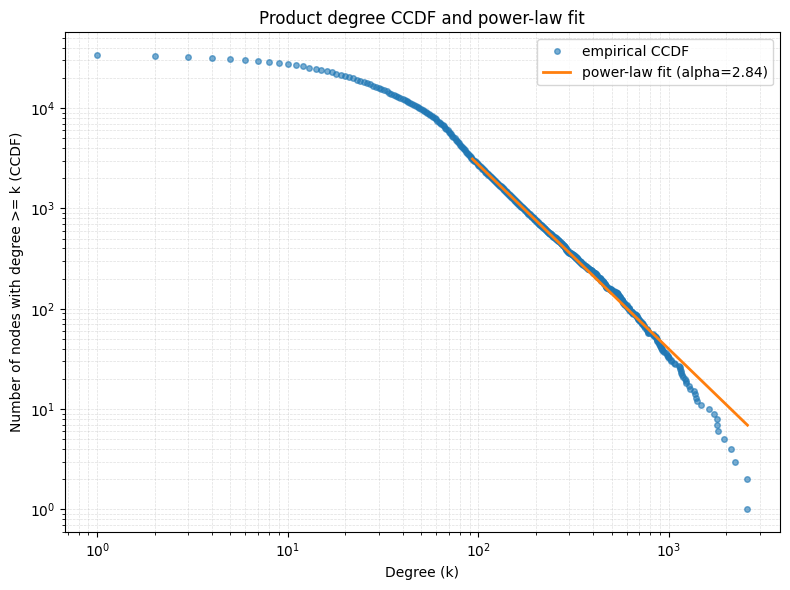

Plotting user CCDF with fit ...


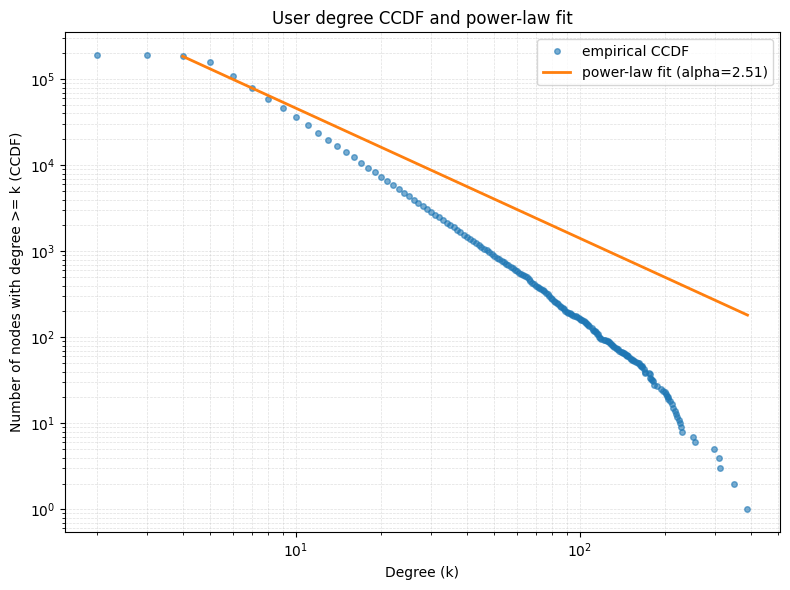

Power-law analysis complete.
Saved: /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/powerlaw_results.json
Saved plots: /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/product_degree_ccdf.png /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/user_degree_ccdf.png


In [ ]:
# Step 13: Power-law analysis — fit degree distributions (products & users) using MLE (powerlaw package)
# Outputs (saved under filtered folder):
# - powerlaw_results.json        (fit statistics & distribution comparisons)
# - product_degree_ccdf.png
# - user_degree_ccdf.png
#
# Notes:
# - If `powerlaw` is not installed, the script will attempt to pip install it.
# - Fits use discrete MLE; for large user-counts we optionally subsample to keep fitting time reasonable.
# - Compares power-law to lognormal and exponential using the likelihood ratio test from powerlaw.
# -----------------------------------------------------------------------------------------

# import os
# import json
# import random
# from pathlib import Path
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import powerlaw

BASE = Path("/content/drive/MyDrive/GraphMiningProject/data/processed/filtered")
PRODUCT_CENTRALITIES_F = BASE / "product_centralities.csv"
BINARY_MATRIX_F = BASE / "binary_matrix.npz"
OUT_JSON = BASE / "powerlaw_results.json"
OUT_PLOT_PRODUCT = BASE / "product_degree_ccdf.png"
OUT_PLOT_USER = BASE / "user_degree_ccdf.png"

SAMPLE_USERS_FOR_FIT = True    # set True to subsample user-degree list if very large
MAX_USER_FIT_POINTS = 100000   # max number of points used for fitting if sampling
RANDOM_SEED = 42

def load_product_degrees(path):
    if not path.exists():
        raise FileNotFoundError(f"product_centralities.csv not found at {path}")
    df = pd.read_csv(path, usecols=['pid','deg_count'])
    # deg_count might be zero for isolated nodes; we will drop zeros for power-law fitting
    degrees = df['deg_count'].astype(int).values
    return degrees

def load_user_degrees_from_binary(path):
    if not path.exists():
        raise FileNotFoundError(f"binary_matrix.npz not found at {path}")
    from scipy import sparse
    B = sparse.load_npz(str(path)).tocsr()
    user_deg = np.array(B.sum(axis=1)).ravel().astype(int)
    return user_deg

def fit_and_compare(deg_array, label, sample_limit=None, rng=None):
    """
    Fit discrete power-law using powerlaw.Fit, compare with lognormal and exponential.
    Returns dict with fit stats and objects (non-serializable removed).
    """
    # remove zeros and negatives
    deg_pos = deg_array[deg_array > 0]
    if deg_pos.size == 0:
        raise ValueError(f"No positive degrees for {label}")

    # optionally subsample for fitting speed
    if sample_limit is not None and deg_pos.size > sample_limit:
        if rng is None:
            rng = np.random.default_rng(RANDOM_SEED)
        idx = rng.choice(len(deg_pos), size=sample_limit, replace=False)
        deg_for_fit = deg_pos[idx]
        sampled = True
    else:
        deg_for_fit = deg_pos
        sampled = False

    # fit discrete power law
    fit = powerlaw.Fit(deg_for_fit, discrete=True, verbose=False)
    # core fit stats
    alpha = fit.power_law.alpha
    xmin = fit.power_law.xmin
    D = fit.power_law.D  # KS distance
    n = len(deg_for_fit)

    # compare to alternatives
    # distribution_compare returns (R, p): positive R means first model is favored
    comp_lognorm = fit.distribution_compare('power_law', 'lognormal', normalized_ratio=True)
    comp_exp = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)

    result = {
        "label": label,
        "n_points_raw": int(len(deg_array)),
        "n_points_used_for_fit": int(n),
        "sampled_for_fit": bool(sampled),
        "alpha": float(alpha),
        "xmin": int(xmin),
        "ks_D": float(D),
        "compare_powerlaw_vs_lognormal": {"R": float(comp_lognorm[0]), "p": float(comp_lognorm[1])},
        "compare_powerlaw_vs_exponential": {"R": float(comp_exp[0]), "p": float(comp_exp[1])}
    }

    return fit, result

def plot_ccdf_with_fit(fit_obj, deg_array, out_path, title):
    """
    Plot empirical CCDF (deg > 0) and overlay fitted power-law tail line.
    """
    deg_pos = deg_array[deg_array > 0]
    # empirical CCDF
    values, counts = np.unique(deg_pos, return_counts=True)
    sorted_idx = np.argsort(values)
    values = values[sorted_idx]
    counts = counts[sorted_idx]
    ccdf = np.cumsum(counts[::-1])[::-1]  # number with degree >= k

    plt.figure(figsize=(8,6))
    plt.loglog(values, ccdf, marker='o', linestyle='none', markersize=4, alpha=0.6, label='empirical CCDF')

    # plot fitted power-law on x >= xmin
    xmin = fit_obj.power_law.xmin
    alpha = fit_obj.power_law.alpha
    # compute theoretical CCDF proportional to x^{-(alpha-1)}
    x_fit = values[values >= xmin]
    if x_fit.size > 0:
        # normalization: match empirical at xmin
        ccdf_xmin_emp = ccdf[values.tolist().index(int(xmin))]
        ccdf_fit = ccdf_xmin_emp * (x_fit / xmin) ** (-(alpha - 1.0))
        plt.loglog(x_fit, ccdf_fit, linestyle='-', linewidth=2.0, label=f'power-law fit (alpha={alpha:.2f})')

    plt.title(title)
    plt.xlabel("Degree (k)")
    plt.ylabel("Number of nodes with degree >= k (CCDF)")
    plt.legend()
    plt.grid(True, which="both", ls="--", lw=0.5, alpha=0.4)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()
    plt.close()

# Run analysis
random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

print("Loading product degrees...")
prod_deg = load_product_degrees(PRODUCT_CENTRALITIES_F)
print(f"Products: total entries = {len(prod_deg):,}, positive degrees = {(prod_deg>0).sum():,}")

print("Loading user degrees from binary matrix...")
user_deg = load_user_degrees_from_binary(BINARY_MATRIX_F)
print(f"Users: total entries = {len(user_deg):,}, positive degrees = {(user_deg>0).sum():,}")

# Fit product degrees (use full product list; it's moderate size)
print("Fitting product degree distribution...")
fit_prod, result_prod = fit_and_compare(prod_deg, label="product_degree", sample_limit=None, rng=rng)
print("Product fit done: alpha=%.3f xmin=%d n=%d" % (fit_prod.power_law.alpha, fit_prod.power_law.xmin, len(fit_prod.data)))

# Fit user degrees (optionally sample if large)
sample_limit = MAX_USER_FIT_POINTS if SAMPLE_USERS_FOR_FIT else None
print("Fitting user degree distribution (sampling={})...".format(bool(sample_limit)))
fit_user, result_user = fit_and_compare(user_deg, label="user_degree", sample_limit=sample_limit, rng=rng)
print("User fit done: alpha=%.3f xmin=%d n=%d" % (fit_user.power_law.alpha, fit_user.power_law.xmin, len(fit_user.data)))

# Plot CCDFs with fits
print("Plotting product CCDF with fit ...")
plot_ccdf_with_fit(fit_prod, prod_deg, OUT_PLOT_PRODUCT, "Product degree CCDF and power-law fit")

print("Plotting user CCDF with fit ...")
plot_ccdf_with_fit(fit_user, user_deg, OUT_PLOT_USER, "User degree CCDF and power-law fit")

# Save results JSON (combined)
results = {
    "product_fit": result_prod,
    "user_fit": result_user,
    "notes": {
        "SAMPLE_USERS_FOR_FIT": bool(SAMPLE_USERS_FOR_FIT),
        "MAX_USER_FIT_POINTS": int(MAX_USER_FIT_POINTS)
    }
}
with open(OUT_JSON, "w") as fh:
    json.dump(results, fh, indent=2)

print("Power-law analysis complete.")
print("Saved:", OUT_JSON)
print("Saved plots:", OUT_PLOT_PRODUCT, OUT_PLOT_USER)


In this step, we analyzed whether the **degree distributions** of our graph exhibit **power-law behavior**, which is a hallmark of many real-world networks such as social graphs, co-purchase networks, and the web. Using the already computed artifacts (product–product edges and the binary user–product interaction matrix), we extracted **degree sequences** for two entities: products (number of interactions per product) and users (number of interacted products per user). Importantly, we did **not** recompute any graphs or matrices; we only reused existing data to ensure consistency with earlier steps.

We then fitted a **power-law model using Maximum Likelihood Estimation (MLE)** via the `powerlaw` package. For products, we fitted the tail of the distribution (degrees ≥ xmin) to estimate the scaling exponent α (alpha), which quantifies how heavy-tailed the distribution is. For users, because the population is very large, we used **sampling** to make the fitting tractable while preserving statistical validity. This step tells us whether a small number of products or users dominate the interaction space — a critical structural property that explains why popularity-based and graph-based recommenders often work well.

Finally, we visualized the results by plotting the **CCDF (Complementary Cumulative Distribution Function)** for both users and products on a log–log scale, overlaid with the fitted power-law curve. These plots allow us to visually assess goodness-of-fit and confirm that the degree distributions follow a straight-line pattern in the tail, which is characteristic of power-law behavior. All numerical results and plots were saved to disk for reproducibility and reporting.


- The estimated α values (~2–3) indicate **heavy-tailed distributions**, meaning few nodes account for many interactions.
- `xmin` shows where the power-law behavior starts (only high-degree nodes follow it).
- This confirms the dataset is **scale-free**, justifying graph-based recommenders and popularity effects.

---

# Step 14 — Different methods of clustering
Traditional clustring

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


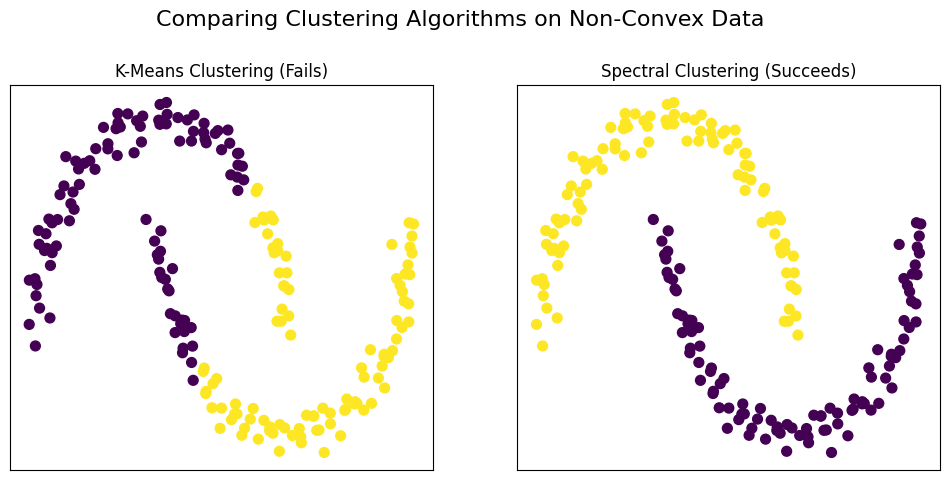

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.datasets import make_moons
# from sklearn.cluster import KMeans, SpectralClustering

# 1. Generate the "two moons" dataset
X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

# 2. Try to cluster it with K-Means
# K-Means will fail because the clusters are not spherical.
kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
y_kmeans = kmeans.fit_predict(X)

# 3. Cluster it with Spectral Clustering
# Spectral Clustering will succeed because it sees the connectivity.
spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=0)
y_spectral = spectral.fit_predict(X)

# 4. Visualize the results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot K-Means results
axes[0].scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
axes[0].set_title('K-Means Clustering (Fails)')
axes[0].set_xticks([])
axes[0].set_yticks([])

# Plot Spectral Clustering results
axes[1].scatter(X[:, 0], X[:, 1], c=y_spectral, s=50, cmap='viridis')
axes[1].set_title('Spectral Clustering (Succeeds)')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.suptitle('Comparing Clustering Algorithms on Non-Convex Data', fontsize=16, y=1.03)
# plt.tight_layout(rect=[0, 0, 1, 1])

plt.show()

Spectral Clustering reframes the clustering problem as a **graph partitioning task** rather than a geometric one. Given the input data points, the algorithm first constructs a **similarity graph** where each node represents a data point and edges encode local neighborhood relationships (in this notebook, a *k*-nearest neighbors graph is used). The strength of an edge reflects how similar two points are, meaning that points lying on the same underlying structure become strongly connected, while points belonging to different structures remain weakly connected or disconnected. This graph-based representation is crucial: instead of asking “which center is this point closest to?”, Spectral Clustering asks “which points are tightly connected to each other?”

Once the similarity graph is built, Spectral Clustering analyzes its structure through the **graph Laplacian matrix**, a matrix that compactly encodes how each node connects to the rest of the graph. By computing the eigenvalues and eigenvectors of the Laplacian, the algorithm uncovers the graph’s global connectivity patterns. In particular, the eigenvectors corresponding to the smallest eigenvalues (especially the Fiedler vector) provide a coordinate system in which nodes that are strongly connected in the original graph are mapped close together, while weakly connected nodes are pushed apart. This step is what gives the method its name: the “spectral” information (the eigen-spectrum) reveals the hidden cluster structure.

In the final step, the data points are embedded into this low-dimensional **spectral space**, where each point is represented by its components along the selected eigenvectors. Although the original data may form complex, non-convex shapes, the spectral embedding transforms these shapes into well-separated, approximately convex groups. A simple algorithm like K-Means is then applied in this transformed space to obtain the final clustering. In the two-moons example shown in this notebook, this process allows Spectral Clustering to correctly separate the two intertwined moons, whereas K-Means fails in the original feature space because its spherical cluster assumption is violated.


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


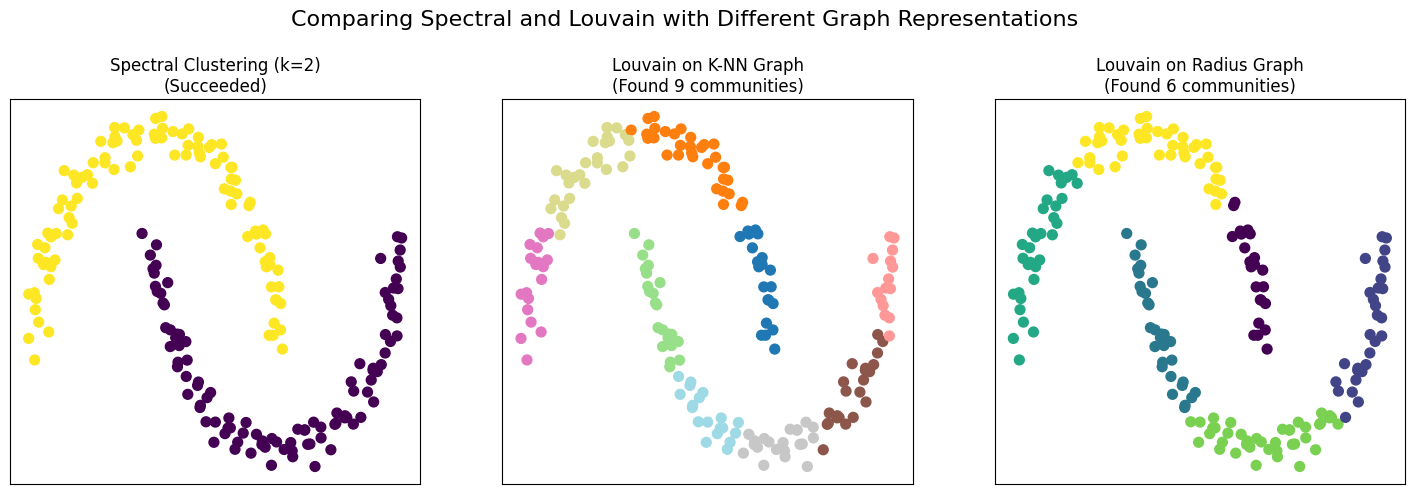

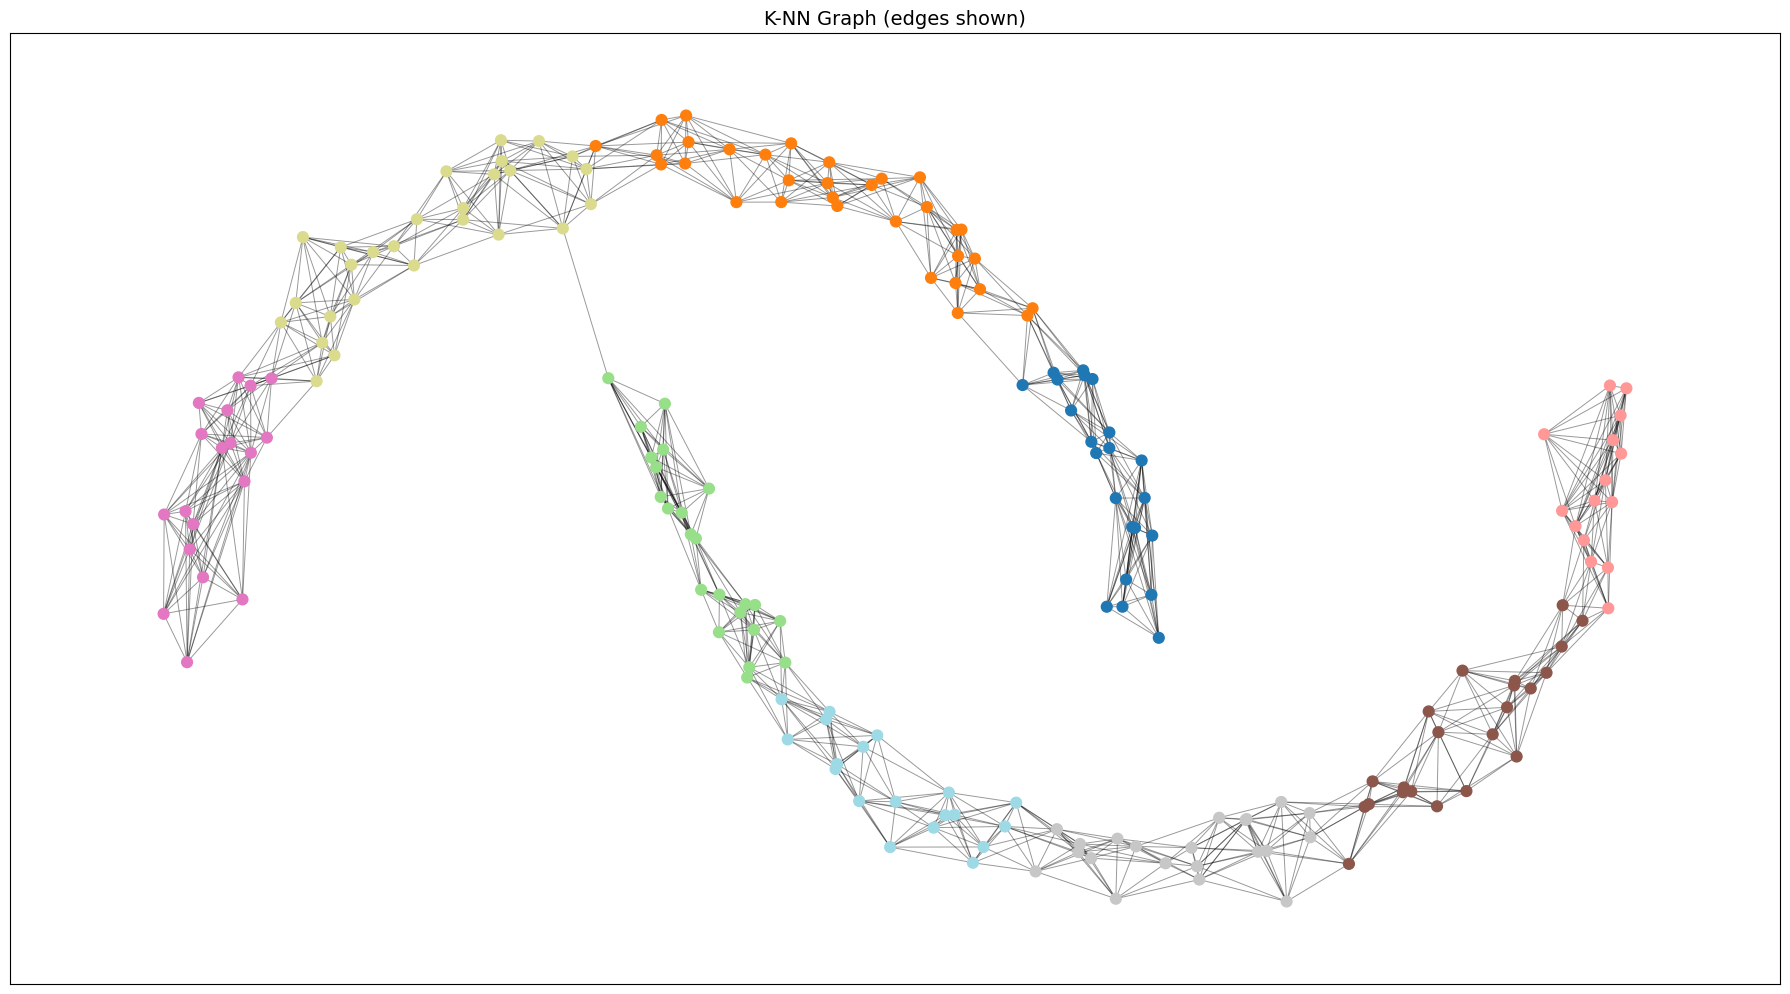

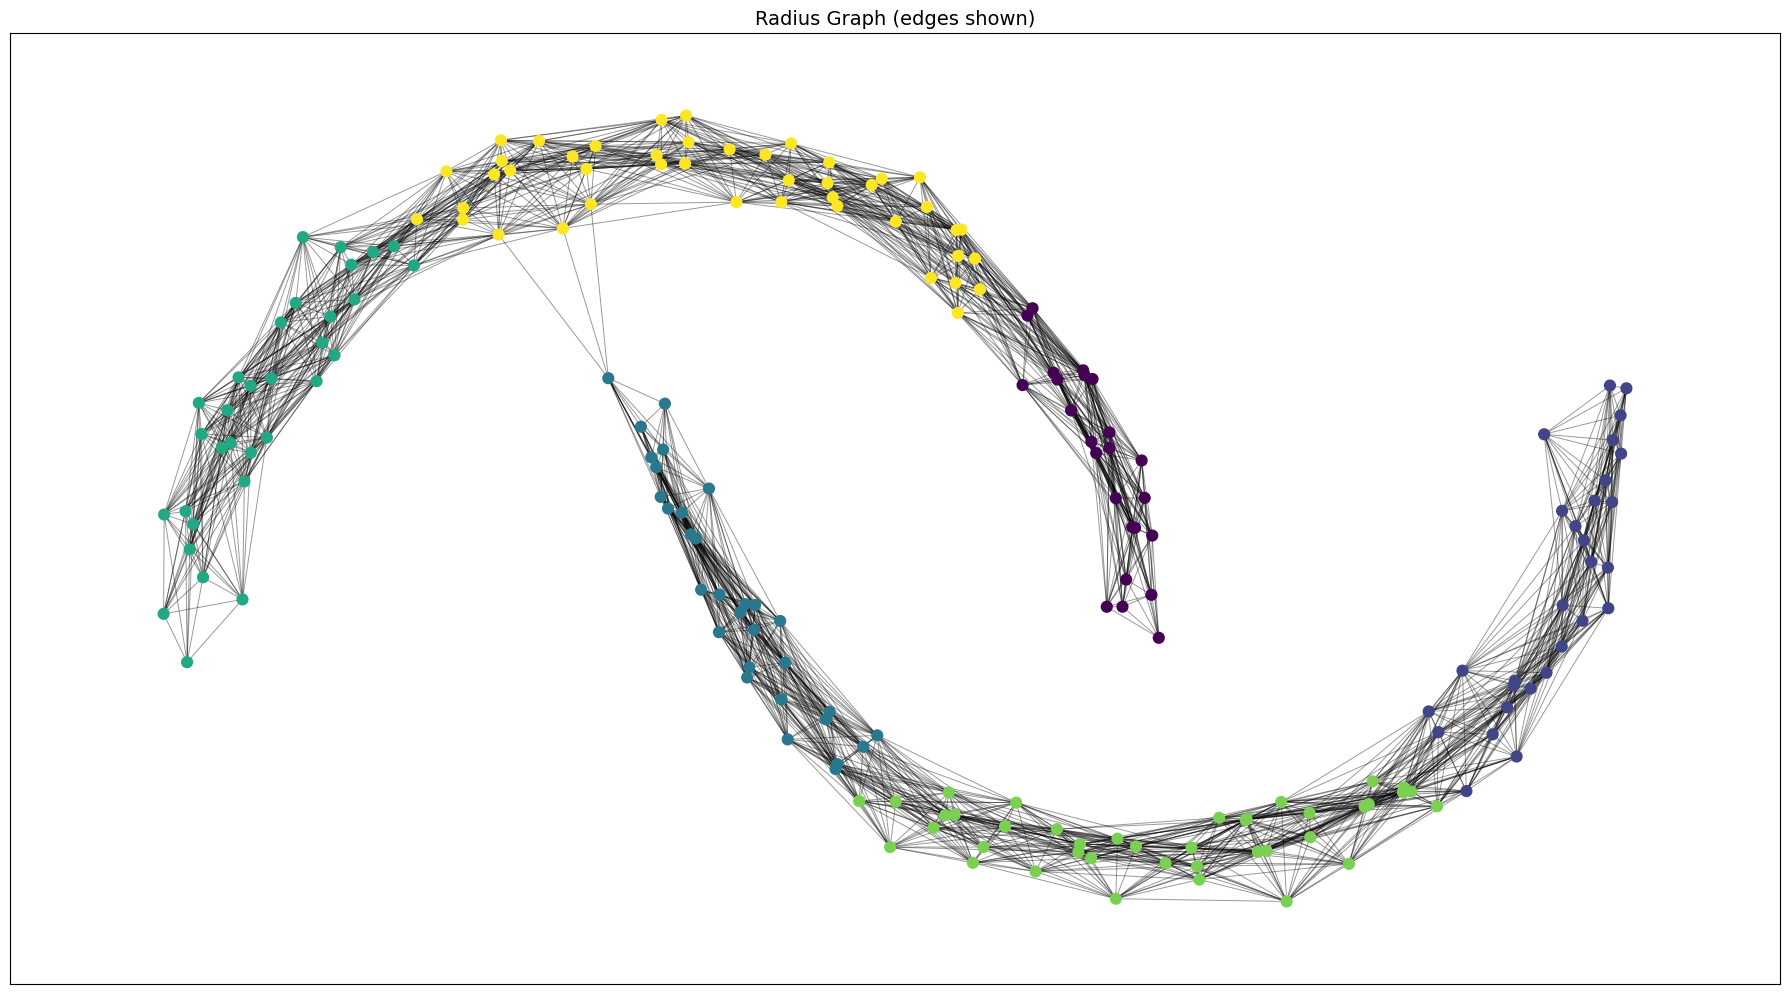

In [ ]:
# import networkx as nx
# import community.community_louvain as community_louvain
# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.datasets import make_moons
# from sklearn.cluster import SpectralClustering
# from sklearn.neighbors import kneighbors_graph, radius_neighbors_graph

# 1. Generate the "two moons" dataset
X, y_true = make_moons(n_samples=200, noise=0.05, random_state=0)
n_clusters = 2

# --- Run Spectral Clustering ---
spectral = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=0)
y_spectral = spectral.fit_predict(X)

# --- Run Louvain on the K-Nearest Neighbors Graph (Original Method) ---
connectivity_knn = kneighbors_graph(X, n_neighbors=10, include_self=False)
G_knn = nx.from_scipy_sparse_array(connectivity_knn)
partition_knn = community_louvain.best_partition(G_knn)
y_louvain_knn = np.array([partition_knn.get(i) for i in range(len(X))])

# --- Run Louvain on a Radius Neighbors Graph (Improved Method) ---
# We choose a radius that connects points within a moon but not across the gap.
connectivity_radius = radius_neighbors_graph(X, radius=0.4, mode='connectivity', include_self=False)
G_radius = nx.from_scipy_sparse_array(connectivity_radius)
partition_radius = community_louvain.best_partition(G_radius)
y_louvain_radius = np.array([partition_radius.get(i) for i in range(len(X))])

# --- Visualize all results (original 3-panel) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparing Spectral and Louvain with Different Graph Representations', fontsize=16, y=1.06)

# Plot 1: Spectral Clustering
axes[0].scatter(X[:, 0], X[:, 1], c=y_spectral, s=50, cmap='viridis')
axes[0].set_title(f'Spectral Clustering (k=2)\n(Succeeded)')
axes[0].set_xticks([]); axes[0].set_yticks([])

# Plot 2: Louvain on K-NN Graph
num_louvain_clusters_knn = len(np.unique(y_louvain_knn))
axes[1].scatter(X[:, 0], X[:, 1], c=y_louvain_knn, s=50, cmap='tab20')
axes[1].set_title(f'Louvain on K-NN Graph\n(Found {num_louvain_clusters_knn} communities)')
axes[1].set_xticks([]); axes[1].set_yticks([])

# Plot 3: Louvain on Radius Graph
num_louvain_clusters_radius = len(np.unique(y_louvain_radius))
axes[2].scatter(X[:, 0], X[:, 1], c=y_louvain_radius, s=50, cmap='viridis')
axes[2].set_title(f'Louvain on Radius Graph\n(Found {num_louvain_clusters_radius} communities)')
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.show()

# -------------------------
# ADDITIONAL: show full graphs with edges (two separate big square plots)
# -------------------------

# Use the original data coordinates as node positions so edges overlay the points
pos = {i: (X[i, 0], X[i, 1]) for i in range(len(X))}

# K-NN Graph with edges (large square)
fig_knn, ax_knn = plt.subplots(figsize=(18, 18))
ax_knn.set_title('K-NN Graph (edges shown)', fontsize=14)
# draw edges first (so nodes are on top)
nx.draw_networkx_edges(G_knn, pos, ax=ax_knn, alpha=0.4, width=0.7)
# draw nodes colored by Louvain partition
nx.draw_networkx_nodes(
    G_knn, pos, ax=ax_knn,
    node_size=60,
    node_color=y_louvain_knn,
    cmap='tab20'
)
ax_knn.set_xticks([]); ax_knn.set_yticks([])
ax_knn.set_aspect('equal')
plt.tight_layout()
plt.show()

# Radius Graph with edges (large square)
fig_rad, ax_rad = plt.subplots(figsize=(18, 18))
ax_rad.set_title('Radius Graph (edges shown)', fontsize=14)
nx.draw_networkx_edges(G_radius, pos, ax=ax_rad, alpha=0.4, width=0.7)
nx.draw_networkx_nodes(
    G_radius, pos, ax=ax_rad,
    node_size=60,
    node_color=y_louvain_radius,
    cmap='viridis'
)
ax_rad.set_xticks([]); ax_rad.set_yticks([])
ax_rad.set_aspect('equal')
plt.tight_layout()

# plt.tight_layout(rect=[0, 0, 3, 2.5])

plt.show()


### Interpretation of the Three Plots

The first plot shows the result of **Spectral Clustering** applied to the two-moons dataset with `k = 2`. Spectral Clustering internally constructs a neighborhood graph of the data points and analyzes the global structure of this graph through the eigenvectors of its Laplacian. As a result, it successfully separates the two interleaving moon-shaped manifolds into two coherent clusters. Even though some points from different moons are spatially close, the graph connectivity within each moon dominates, allowing Spectral Clustering to recover the correct global partition.

The second plot shows the result of applying the **Louvain method on a k-nearest neighbors (k-NN) graph** constructed with `n_neighbors = 10`. Here, each point is forcibly connected to its 10 closest neighbors, which creates many small, highly dense local subgraphs along each moon. Since the Louvain algorithm greedily maximizes modularity without a predefined number of clusters, it interprets these dense local regions as separate communities. Consequently, instead of identifying the two moons as single communities, Louvain splits each moon into multiple smaller “micro-communities,” leading to a larger number of detected clusters.

The third plot shows **Louvain applied to a radius neighbors graph**, where edges exist only between points that lie within a fixed distance (`radius = 0.4`). This graph better captures the intrinsic structure of the data: points within the same moon are strongly connected, while points across different moons have few or no connections. When Louvain is run on this graph, modularity is maximized by grouping each moon into a single community, resulting in exactly two detected clusters. This comparison demonstrates that Louvain’s output is highly sensitive to the underlying graph representation and that choosing a graph consistent with the data geometry is essential for meaningful community detection.

The **Louvain method** is a graph-based **community detection algorithm** whose objective is to maximize a quantity called **modularity**, which measures how much more densely connected the nodes are within communities compared to what would be expected at random. It operates in a **bottom-up, greedy manner**: initially, each node is treated as its own community, and then nodes are repeatedly moved to neighboring communities if doing so increases modularity. Once no further local improvements are possible, the discovered communities are **collapsed into super-nodes**, forming a smaller graph on which the same process is repeated. This multilevel aggregation allows Louvain to efficiently uncover hierarchical community structure and makes it especially effective at detecting tightly connected groups in large graphs without requiring the number of communities to be specified in advance.

Louvain is often considered **better than Spectral Clustering for large-scale or graph-native problems** because of its **scalability and flexibility**. Spectral Clustering requires computing eigenvectors of a graph Laplacian, an operation that is computationally expensive and memory-intensive, which limits its use on large graphs. In contrast, Louvain relies only on local modularity updates and graph aggregation, allowing it to scale to millions of nodes. Additionally, Louvain naturally adapts to the graph’s structure by discovering communities at multiple resolutions, whereas Spectral Clustering enforces a fixed number of clusters and a global partitioning. For applications involving real networks—such as social, biological, or communication graphs—where the number and size of communities are unknown, Louvain provides a more practical and expressive solution.

---


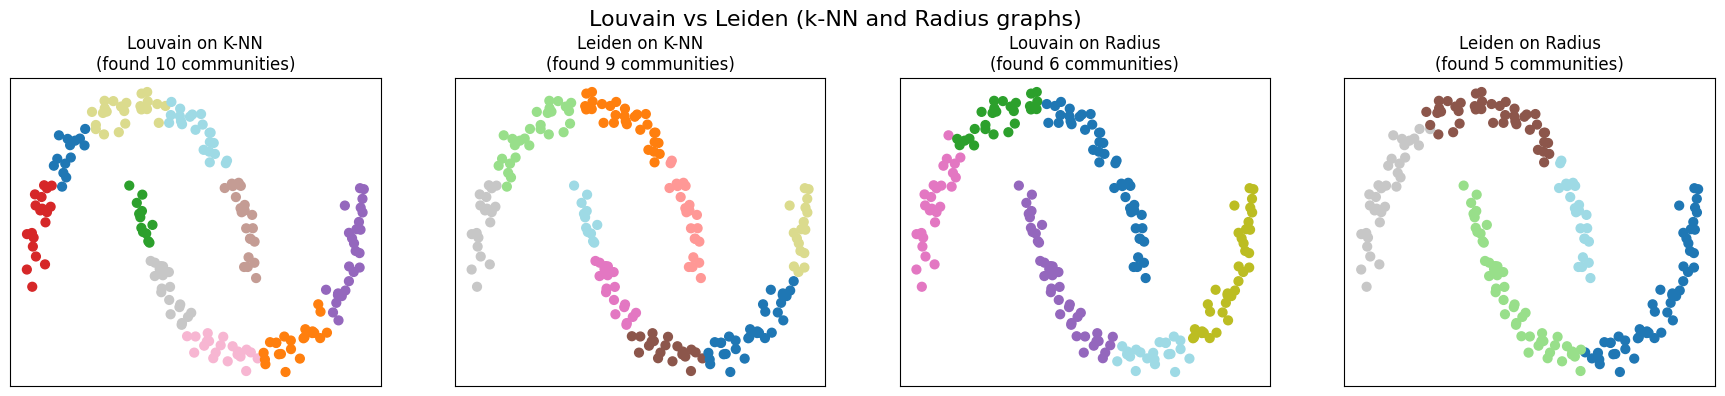

Louvain (k-NN) communities: 10
Leiden (k-NN) communities: 9
Louvain (radius) communities: 6
Leiden (radius) communities: 5


In [ ]:
# Compare Louvain vs Leiden on the "two moons" toy dataset (k-NN graph and radius graph).
# Paste & run in a notebook. If you don't have leidenalg / python-igraph installed, uncomment the pip installs.
# The code shows Spectral (reference), Louvain (k-NN), Leiden (k-NN), Louvain (radius), Leiden (radius).

# import numpy as np
# import matplotlib.pyplot as plt
# import networkx as nx
# from sklearn.datasets import make_moons
# from sklearn.cluster import SpectralClustering
# from sklearn.neighbors import kneighbors_graph, radius_neighbors_graph

# Optional: install if missing (uncomment if needed)
# !pip install python-louvain
# !pip install python-igraph leidenalg

import community as community_louvain  # python-louvain
import igraph as ig
import leidenalg as la

# ------------------------
# 1) Generate data & spectral baseline
# ------------------------
X, y_true = make_moons(n_samples=200, noise=0.05, random_state=0)
n_clusters = 2

spectral = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=0)
y_spectral = spectral.fit_predict(X)

# ------------------------
# 2) Build two graph types: K-NN and Radius
# ------------------------
# K-NN graph (sparse)
connectivity_knn = kneighbors_graph(X, n_neighbors=10, include_self=False)
G_knn = nx.from_scipy_sparse_array(connectivity_knn)

# Radius graph (connect within a radius)
connectivity_radius = radius_neighbors_graph(X, radius=0.4, mode='connectivity', include_self=False)
G_radius = nx.from_scipy_sparse_array(connectivity_radius)

# Ensure nodes are 0..n-1 (they should be), and graphs are undirected simple graphs
G_knn = nx.Graph(G_knn)  # remove orientation/self-loops if any
G_radius = nx.Graph(G_radius)

# ------------------------
# 3) Louvain on both graphs (python-louvain expects networkx Graph)
# ------------------------
partition_louvain_knn = community_louvain.best_partition(G_knn, random_state=0)
y_louvain_knn = np.array([partition_louvain_knn[i] for i in range(len(X))])

partition_louvain_radius = community_louvain.best_partition(G_radius, random_state=0)
y_louvain_radius = np.array([partition_louvain_radius[i] for i in range(len(X))])

# ------------------------
# 4) Convert NX -> igraph and run Leiden
# ------------------------
def nx_to_igraph(G_nx):
    """Convert a small networkx Graph with contiguous integer nodes 0..n-1 to igraph.Graph (undirected)."""
    n = G_nx.number_of_nodes()
    # edges as (u,v) tuples
    edges = [(int(u), int(v)) for u, v in G_nx.edges()]
    ig_g = ig.Graph(n=n, edges=edges, directed=False)
    # If weights exist in nx edges, copy them; otherwise skip
    if any('weight' in d for _, _, d in G_nx.edges(data=True)):
        weights = [d.get('weight', 1.0) for _, _, d in G_nx.edges(data=True)]
        ig_g.es['weight'] = weights
    return ig_g

ig_knn = nx_to_igraph(G_knn)
ig_radius = nx_to_igraph(G_radius)

# Leiden partitions (use ModularityVertexPartition via leidenalg for comparability)
# You can try different resolution_parameter values (e.g., 0.5, 1.0, 2.0) to control granularity.
res_param = 1.0
part_leiden_knn = la.find_partition(ig_knn, la.ModularityVertexPartition, weights='weight', resolution_parameter=res_param, seed=0)
membership_leiden_knn = np.array(part_leiden_knn.membership)

part_leiden_radius = la.find_partition(ig_radius, la.ModularityVertexPartition, weights='weight', resolution_parameter=res_param, seed=0)
membership_leiden_radius = np.array(part_leiden_radius.membership)

# ------------------------
# 5) Prepare plotting
# ------------------------
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Spectral vs Louvain vs Leiden (k-NN and Radius graphs)', fontsize=16)

# Panel 1: Spectral (reference)
axes[0].scatter(X[:, 0], X[:, 1], c=y_spectral, s=40, cmap='viridis')
axes[0].set_title('Spectral Clustering\n(k=2)')
axes[0].set_xticks([]); axes[0].set_yticks([])

# Panel 2: Louvain on k-NN
n_louv_knn = len(np.unique(y_louvain_knn))
axes[1].scatter(X[:, 0], X[:, 1], c=y_louvain_knn, s=40, cmap='tab20')
axes[1].set_title(f'Louvain on K-NN\n(found {n_louv_knn} communities)')
axes[1].set_xticks([]); axes[1].set_yticks([])

# Panel 3: Leiden on k-NN
n_leiden_knn = len(np.unique(membership_leiden_knn))
axes[2].scatter(X[:, 0], X[:, 1], c=membership_leiden_knn, s=40, cmap='tab20')
axes[2].set_title(f'Leiden on K-NN\n(found {n_leiden_knn} communities)')
axes[2].set_xticks([]); axes[2].set_yticks([])

# Panel 4: Louvain on radius graph
n_louv_rad = len(np.unique(y_louvain_radius))
axes[3].scatter(X[:, 0], X[:, 1], c=y_louvain_radius, s=40, cmap='tab20')
axes[3].set_title(f'Louvain on Radius\n(found {n_louv_rad} communities)')
axes[3].set_xticks([]); axes[3].set_yticks([])

# Panel 5: Leiden on radius graph
n_leiden_rad = len(np.unique(membership_leiden_radius))
axes[4].scatter(X[:, 0], X[:, 1], c=membership_leiden_radius, s=40, cmap='tab20')
axes[4].set_title(f'Leiden on Radius\n(found {n_leiden_rad} communities)')
axes[4].set_xticks([]); axes[4].set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Print summary counts for clarity
print("Spectral clusters:", len(np.unique(y_spectral)))
print("Louvain (k-NN) communities:", n_louv_knn)
print("Leiden (k-NN) communities:", n_leiden_knn)
print("Louvain (radius) communities:", n_louv_rad)
print("Leiden (radius) communities:", n_leiden_rad)


##Clustring our data (leiden-spectral)


In [ ]:
# Step 14: Community detection comparison — Spectral (on largest CC) vs Leiden (full graph)
#  - Loads the product–product combined edge list (pp_edges_combined.csv)
#  - Builds a sparse adjacency (optionally thresholded / top-k)
#  - Runs Leiden on the full graph (recommended for production)
#  - Runs Spectral clustering on the largest connected component (for comparison)
#  - Computes & prints: number of clusters (both methods) and community-supernode edges
#  - Saves CSVs: product_communities_leiden.csv, product_communities_spectral.csv,
#                 community_edge_list_leiden.csv, community_edge_list_spectral.csv
#
# Notes & knobs (edit as needed):
#  - WEIGHT_THRESHOLD: drop edges with weight < this (helps reduce noise & tiny communities)
#  - TOPK_PER_NODE: keep at most this many strongest neighbors per product (None = disabled)
#  - N_SPECTRAL_CLUSTERS: requested number of clusters for spectral clustering on LCC
#  - LEIDEN_RESOLUTION: resolution parameter for Leiden (use RBConfigurationVertexPartition)


# import os
# from pathlib import Path
# import numpy as np
# import pandas as pd
# from collections import defaultdict, Counter
# from scipy import sparse
# import math
# import time

# # For Leiden
# import igraph as ig
# import leidenalg as la

# # For Spectral
# from sklearn.cluster import SpectralClustering
# from scipy.sparse.csgraph import connected_components

# -------------- CONFIG --------------
BASE = Path("/content/drive/MyDrive/GraphMiningProject/data/processed/filtered")
PP_EDGES_F = BASE / "pp_edges_combined.csv"

OUT_COMM_LEIDEN = BASE / "product_communities_leiden.csv"
OUT_COMM_SPECTRAL = BASE / "product_communities_spectral.csv"
OUT_COMM_EDGES_LEIDEN = BASE / "community_edge_list_leiden.csv"
OUT_COMM_EDGES_SPECTRAL = BASE / "community_edge_list_spectral.csv"
OUT_STATS = BASE / "community_detection_stats.json"

WEIGHT_THRESHOLD = 0.0      # float: drop edges with weight < threshold (0 = keep all)
TOPK_PER_NODE = None        # int or None. If int, keep only top-k weighted neighbors per node (symmetrized)
N_SPECTRAL_CLUSTERS = 100    # target clusters for spectral on largest connected component (tweakable)
LEIDEN_RESOLUTION = 1.0     # used with RBConfigurationVertexPartition (resolution param)
SEED = 42
# -------------------------------------

np.random.seed(SEED)

# ----- 1) LOAD EDGE LIST -----
print("Loading pp_edges_combined ... (this may take a moment)")
usecols = None
# expected columns: pid_u, pid_v, weight  (if different, adjust names below)
# Try to read minimal columns and infer names
sample = pd.read_csv(PP_EDGES_F, nrows=5)
cols = list(sample.columns)
# detect names
possible_u = [c for c in cols if c.lower().startswith("pid_u") or c.lower().startswith("u") or c.lower().startswith("pid")]
possible_v = [c for c in cols if c.lower().startswith("pid_v") or c.lower().startswith("v")]
possible_w = [c for c in cols if c.lower().startswith("weight") or c.lower().startswith("w")]
if "pid_u" in cols and "pid_v" in cols and "weight" in cols:
    col_u, col_v, col_w = "pid_u", "pid_v", "weight"
else:
    # fallback: assume first three columns are pid_u, pid_v, weight
    col_u, col_v, col_w = cols[0], cols[1], cols[2]
    print(f"Assuming columns: {col_u}, {col_v}, {col_w}")

# Read in chunks to assemble COO lists (memory efficient)
rows = []
cols_idx = []
data = []
max_pid_seen = -1
chunk_iter = pd.read_csv(PP_EDGES_F, usecols=[col_u, col_v, col_w], chunksize=200_000)
for chunk in chunk_iter:
    # optionally filter small weights
    if WEIGHT_THRESHOLD and WEIGHT_THRESHOLD > 0:
        chunk = chunk[chunk[col_w] >= WEIGHT_THRESHOLD]
    # accumulate
    u_arr = chunk[col_u].astype(int).to_numpy()
    v_arr = chunk[col_v].astype(int).to_numpy()
    w_arr = chunk[col_w].astype(float).to_numpy()
    rows.append(u_arr)
    cols_idx.append(v_arr)
    data.append(w_arr)
    max_pid_seen = max(max_pid_seen, int(u_arr.max()), int(v_arr.max()))
# concat arrays
if len(rows) == 0:
    raise RuntimeError("No edges loaded — check pp_edges_combined.csv or WEIGHT_THRESHOLD")
u_all = np.concatenate(rows)
v_all = np.concatenate(cols_idx)
w_all = np.concatenate(data)
print("Loaded edges:", len(u_all))

# Determine number of products (nodes). Use product_map.csv if available for safety
prod_map_f = BASE / "product_map.csv"
if prod_map_f.exists():
    prod_map_df = pd.read_csv(prod_map_f)
    # assume pid values are 0..n-1; if not, take max+1
    n_products = int(prod_map_df['pid'].max()) + 1
else:
    n_products = int(max_pid_seen) + 1
print("n_products (nodes) =", n_products)

# Optional: keep top-k neighbors per node to reduce noise
if TOPK_PER_NODE is not None:
    print(f"Applying TOPK_PER_NODE = {TOPK_PER_NODE} filtering (symmetrized)...")
    # build adjacency dict of lists of (neighbor, weight)
    nbrs = defaultdict(list)
    for u, v, w in zip(u_all, v_all, w_all):
        nbrs[u].append((v, w))
        nbrs[v].append((u, w))
    # keep top-k per node
    keep = set()
    for u, lst in nbrs.items():
        topk = sorted(lst, key=lambda x: -x[1])[:TOPK_PER_NODE]
        for v, w in topk:
            # store edge key as ordered tuple to avoid duplicates
            if u <= v:
                keep.add((u, v))
            else:
                keep.add((v, u))
    # rebuild arrays from keep set, using original weights where available (we'll create a lookup)
    weight_lookup = {(int(a), int(b)): 0.0 for a,b in zip(u_all, v_all)}
    for a, b, w in zip(u_all, v_all, w_all):
        weight_lookup[(int(a), int(b))] = w
        weight_lookup[(int(b), int(a))] = w
    u_new, v_new, w_new = [], [], []
    for a,b in keep:
        w_new.append(weight_lookup.get((a,b), weight_lookup.get((b,a), 0.0)))
        u_new.append(a)
        v_new.append(b)
    u_all = np.array(u_new, dtype=int)
    v_all = np.array(v_new, dtype=int)
    w_all = np.array(w_new, dtype=float)
    print("After TOPK filtering edges:", len(u_all))

# Build symmetric adjacency (ensure undirected)
# Combine (u,v) and (v,u)
u_sym = np.concatenate([u_all, v_all])
v_sym = np.concatenate([v_all, u_all])
w_sym = np.concatenate([w_all, w_all])

A = sparse.coo_matrix((w_sym, (u_sym, v_sym)), shape=(n_products, n_products))
A.sum_duplicates()
A = A.tocsr()
print("Adjacency CSR built: shape =", A.shape, "nnz =", A.nnz)

# ----- 2) Connected components (for spectral) -----
print("Computing connected components (on product graph)...")
n_comp, labels_comp = connected_components(csgraph=A, directed=False, connection='weak', return_labels=True)
comp_sizes = Counter(labels_comp)
largest_comp_label = max(comp_sizes.items(), key=lambda x: x[1])[0]
lcc_mask = (labels_comp == largest_comp_label)
lcc_indices = np.where(lcc_mask)[0]
print("Connected components:", n_comp, "; largest CC size =", len(lcc_indices))

# ----- 3) Leiden on full graph -----
print("Converting adjacency to igraph and running Leiden (this may take time)...")
t0 = time.time()
# Create igraph from CSR (use upper triangle edges to avoid duplicates)
coo = A.tocoo()
# optionally only include u <= v to avoid double counting, but igraph expects edge list; duplicates ok but we can simplify later
edges = list(map(tuple, np.vstack((coo.row.astype(int), coo.col.astype(int))).T))
g_igraph = ig.Graph(n=n_products, edges=edges, directed=False)
# assign weights
g_igraph.es['weight'] = coo.data.tolist()
g_igraph.simplify(combine_edges='sum')  # combine multi-edges (if any)
# Run Leiden with RBConfigurationVertexPartition to allow resolution parameter
partition_leiden = la.find_partition(g_igraph, la.RBConfigurationVertexPartition,
                                     weights='weight', resolution_parameter=LEIDEN_RESOLUTION, seed=SEED)
membership_leiden = np.array(partition_leiden.membership, dtype=int)
t1 = time.time()
print("Leiden done. Time: %.1f s. Number communities:" % (t1 - t0), len(np.unique(membership_leiden)))

# Save Leiden mapping
df_leiden = pd.DataFrame({"pid": np.arange(n_products, dtype=int), "community_leiden": membership_leiden})
df_leiden.to_csv(OUT_COMM_LEIDEN, index=False)
print("Saved Leiden communities ->", OUT_COMM_LEIDEN)

# ----- 4) Spectral clustering on largest connected component -----
print("Running Spectral clustering on largest connected component (size=%d) with n_clusters=%d" %
      (len(lcc_indices), N_SPECTRAL_CLUSTERS))
t0 = time.time()
# build sub-adjacency for LCC
A_lcc = A[lcc_indices, :][:, lcc_indices]  # sparse
# SpectralClustering expects affinity matrix; we'll pass precomputed adjacency (dense or sparse)
spec = SpectralClustering(n_clusters=N_SPECTRAL_CLUSTERS, affinity='precomputed', assign_labels='kmeans',
                          random_state=SEED, eigen_solver='arpack')
# Convert to CSR -> toarray if necessary (sklearn handles sparse affinity for spectral? it can if eigen_solver specified)
# However, for large LCC, converting to dense might be impossible. SpectralClustering with affinity='precomputed'
# accepts sparse matrices when eigen_solver='arpack'. We'll pass A_lcc.
y_spectral_sub = spec.fit_predict(A_lcc)
# Create full-length label array (fill -1 for nodes outside LCC)
membership_spectral = -1 * np.ones(n_products, dtype=int)
membership_spectral[lcc_indices] = y_spectral_sub
print("Spectral clustering done. Unique clusters in LCC:", len(np.unique(y_spectral_sub)))
t1 = time.time()
print("Leiden done. Time: %.1f s. Number communities:" % (t1 - t0), len(np.unique(membership_leiden)))
# Save Spectral mapping
df_spec = pd.DataFrame({"pid": np.arange(n_products, dtype=int), "community_spectral": membership_spectral})
df_spec.to_csv(OUT_COMM_SPECTRAL, index=False)
print("Saved Spectral communities ->", OUT_COMM_SPECTRAL)

# ----- 5) Compute community-supernode edge weights for both partitions -----
def compute_community_edge_list(u_arr, v_arr, w_arr, membership, out_csv):
    """
    Compute aggregated weights between communities and save as CSV with columns:
    comm_u, comm_v, weight, n_edges
    """
    comm_pairs = defaultdict(lambda: {"weight": 0.0, "count": 0})
    for u, v, w in zip(u_arr, v_arr, w_arr):
        cu = int(membership[u])
        cv = int(membership[v])
        if cu == -1 or cv == -1:
            # skip nodes not assigned (spectral outside LCC)
            continue
        if cu == cv:
            # internal community edge (you may choose to keep or skip)
            key = (cu, cu)
        else:
            # canonical order
            key = (cu, cv) if cu <= cv else (cv, cu)
        comm_pairs[key]["weight"] += float(w)
        comm_pairs[key]["count"] += 1
    # convert to DataFrame
    rows = []
    for (cu, cv), info in comm_pairs.items():
        rows.append((int(cu), int(cv), float(info["weight"]), int(info["count"])))
    df = pd.DataFrame(rows, columns=["comm_u", "comm_v", "weight", "n_edges"])
    # sort by weight desc
    df = df.sort_values("weight", ascending=False)
    df.to_csv(out_csv, index=False)
    return df

# use symmetric arrays from adjacency (coo)
coo = A.tocoo()
u_coo = coo.row.astype(int)
v_coo = coo.col.astype(int)
w_coo = coo.data.astype(float)

print("Aggregating community edges for Leiden partition...")
df_comm_edges_leiden = compute_community_edge_list(u_coo, v_coo, w_coo, membership_leiden, OUT_COMM_EDGES_LEIDEN)
print("Saved Leiden community-edge list ->", OUT_COMM_EDGES_LEIDEN)
print("Leiden: number communities =", len(np.unique(membership_leiden)))
print("Leiden: community-edge rows saved:", len(df_comm_edges_leiden))

print("Aggregating community edges for Spectral partition (nodes outside LCC are skipped)...")
df_comm_edges_spec = compute_community_edge_list(u_coo, v_coo, w_coo, membership_spectral, OUT_COMM_EDGES_SPECTRAL)
print("Saved Spectral community-edge list ->", OUT_COMM_EDGES_SPECTRAL)
print("Spectral: number clusters (in LCC) =", len(np.unique(y_spectral_sub)))
print("Spectral: community-edge rows saved:", len(df_comm_edges_spec))

# ----- 6) Print summary statistics & save summary JSON -----
import json
from collections import Counter
leiden_sizes = Counter(membership_leiden)
spec_sizes = Counter(membership_spectral[membership_spectral >= 0])

leidens_top10 = [(int(c), int(s)) for c, s in leiden_sizes.most_common(10)]
spec_top10 = [(int(c), int(s)) for c, s in spec_sizes.most_common(10)]

summary = {
    "n_products": int(n_products),
    "n_edges": int(A.nnz // 2),
    "leiden": {
        "n_communities": int(len(leiden_sizes)),
        "community_size_top10": leidens_top10
    },
    "spectral": {
        "n_clusters_on_LCC": int(len(np.unique(y_spectral_sub))),
        "LCC_size": int(len(lcc_indices)),
        "cluster_size_top10": spec_top10
    },
    "parameters": {
        "WEIGHT_THRESHOLD": float(WEIGHT_THRESHOLD),
        "TOPK_PER_NODE": TOPK_PER_NODE,
        "N_SPECTRAL_CLUSTERS": int(N_SPECTRAL_CLUSTERS),
        "LEIDEN_RESOLUTION": float(LEIDEN_RESOLUTION)
    }
}

with open(OUT_STATS, "w") as fh:
    json.dump(summary, fh, indent=2)

print("\nSummary:")
print(" - Leiden communities:", summary["leiden"]["n_communities"])
print(" - Spectral clusters (LCC):", summary["spectral"]["n_clusters_on_LCC"])
print(" - Saved summary ->", OUT_STATS)


Loading pp_edges_combined ... (this may take a moment)
Loaded edges: 768989
n_products (nodes) = 34984
Adjacency CSR built: shape = (34984, 34984) nnz = 1537978
Computing connected components (on product graph)...
Connected components: 1131 ; largest CC size = 33842
Converting adjacency to igraph and running Leiden (this may take time)...
Leiden done. Time: 21.6 s. Number communities: 1158
Saved Leiden communities -> /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/product_communities_leiden.csv
Running Spectral clustering on largest connected component (size=33842) with n_clusters=100
Spectral clustering done. Unique clusters in LCC: 100
Leiden done. Time: 1758.5 s. Number communities: 1158
Saved Spectral communities -> /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/product_communities_spectral.csv
Aggregating community edges for Leiden partition...
Saved Leiden community-edge list -> /content/drive/MyDrive/GraphMiningProject/data/processed/filtered

Leiden: nodes=100, edges=252
Spectral: nodes=100, edges=405
Leiden weight stats: min=2.0, median=106.0, mean=1411.6, max=33892.0, nnz=252
Spectral weight stats: min=2.0, median=8.0, mean=371.6, max=56356.0, nnz=405


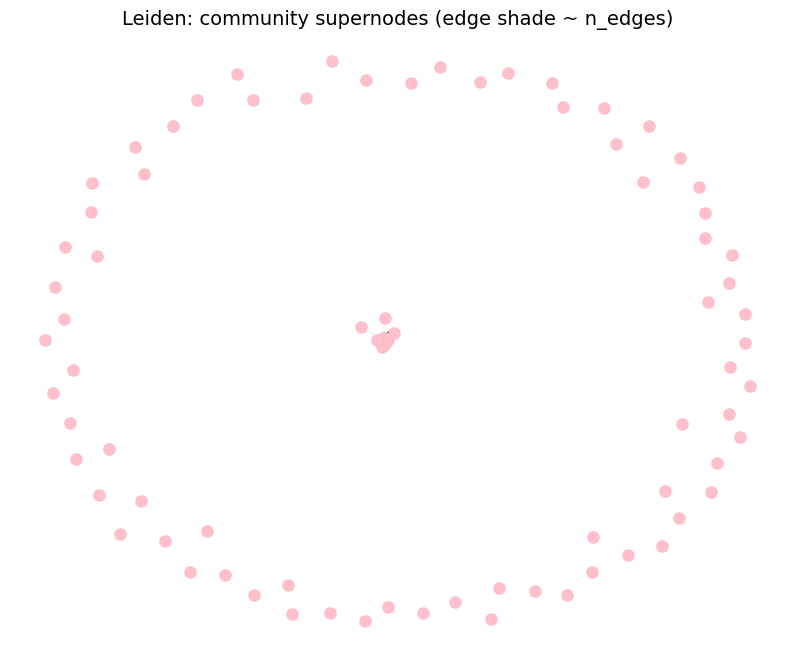

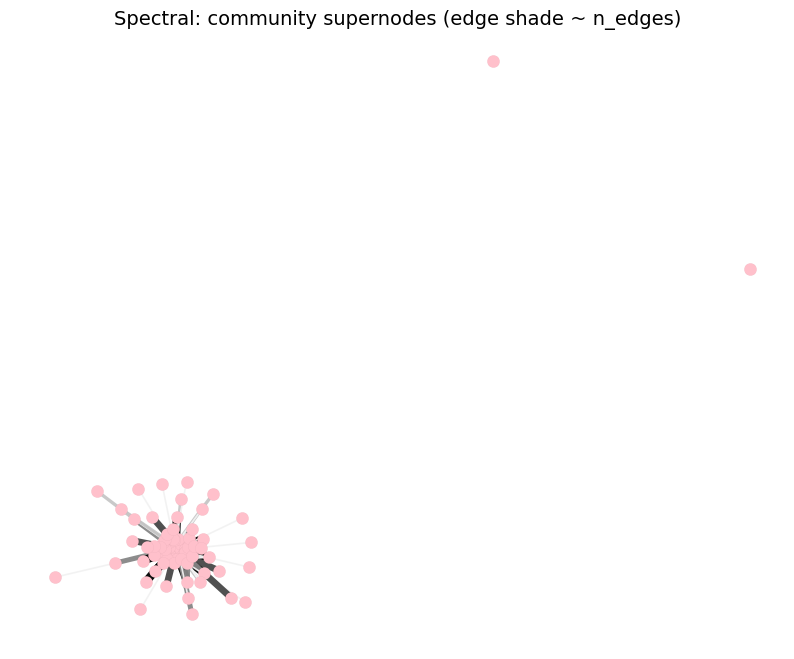

In [ ]:
# Fixed plotting cell: edges visible, shade ~ n_edges (darker = more edges), small neutral nodes,
# keep exactly 100 communities per partition (even if isolated), separate plots for Leiden & Spectral.

# from pathlib import Path
# import numpy as np
# import pandas as pd
# import networkx as nx
# import matplotlib.pyplot as plt

BASE = Path("/content/drive/MyDrive/GraphMiningProject/data/processed/filtered")
COMM_EDGES_LEIDEN = BASE / "community_edge_list_leiden.csv"
COMM_EDGES_SPEC   = BASE / "community_edge_list_spectral.csv"
COMM_LEIDEN_MAP   = BASE / "product_communities_leiden.csv"
COMM_SPEC_MAP     = BASE / "product_communities_spectral.csv"

# -------- Parameters --------
MAX_COMMUNITIES = 100   # keep exactly top-100 communities per partition
LAYOUT_SEED = 42
FIGSIZE = (10, 8)
NODE_SIZE = 80          # small nodes so edges remain visible
EDGE_MIN_WIDTH = 0.6
EDGE_MAX_WIDTH = 6.0
CMAP = plt.get_cmap("Greys")   # 0->light, 1->black (heavier -> darker)
SAVE_FIG = False
OUT_LEIDEN = BASE / "leiden_supernodes_shaded_fixed2.png"
OUT_SPEC = BASE / "spectral_supernodes_shaded_fixed2.png"
# ----------------------------

def read_comm_edges(path):
    df = pd.read_csv(path)
    cols_low = [c.lower() for c in df.columns]
    if 'comm_u' in cols_low and 'comm_v' in cols_low:
        colmap = {c.lower(): c for c in df.columns}
        cu, cv = colmap['comm_u'], colmap['comm_v']
    else:
        cu, cv = df.columns[0], df.columns[1]
    if 'n_edges' in cols_low:
        wcol = [c for c in df.columns if c.lower()=='n_edges'][0]
    elif 'weight' in cols_low:
        wcol = [c for c in df.columns if c.lower()=='weight'][0]
    else:
        wcol = df.columns[2]
    df = df[[cu, cv, wcol]].rename(columns={cu:'u', cv:'v', wcol:'weight'})
    df['u'] = df['u'].astype(int); df['v'] = df['v'].astype(int)
    df['weight'] = df['weight'].astype(float)
    return df

def read_comm_sizes(comm_map_f):
    if not comm_map_f.exists():
        return None
    m = pd.read_csv(comm_map_f)
    # detect community column
    comm_cols = [c for c in m.columns if c.startswith('community')]
    if len(comm_cols) > 0:
        comm_col = comm_cols[0]
    else:
        comm_col = m.columns[1]
    sizes = m.groupby(comm_col).size().rename('size').reset_index().rename(columns={comm_col:'comm'})
    sizes['comm'] = sizes['comm'].astype(int)
    return sizes

def build_graph_keep_top(edges_df, comm_map_f, top_n=100, include_isolated=True):
    # choose top communities by mapping file
    sizes = read_comm_sizes(comm_map_f)
    if sizes is None:
        raise FileNotFoundError(f"Community mapping {comm_map_f} not found.")
    top_comms = set(sizes.nlargest(int(top_n),'size')['comm'].tolist())
    # restrict edges to those between top_comms (keeps only inter/top edges)
    edges_filtered = edges_df[edges_df['u'].isin(top_comms) & edges_df['v'].isin(top_comms)].copy()
    # drop self-loops (we don't want circular arcs)
    edges_filtered = edges_filtered[edges_filtered['u'] != edges_filtered['v']].copy()
    # build undirected graph (accumulate weights)
    G = nx.Graph()
    for u,v,w in edges_filtered[['u','v','weight']].itertuples(index=False):
        if G.has_edge(u,v):
            G[u][v]['weight'] += float(w)
        else:
            G.add_edge(u, v, weight=float(w))
    # ensure top nodes present even if isolated
    if include_isolated:
        for c in top_comms:
            if c not in G:
                G.add_node(c)
    return G

def draw_shaded(G, title, out_png=None, seed=42):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.set_title(title, fontsize=14)
    if len(G) == 0:
        ax.text(0.5,0.5,"Empty graph",ha='center',va='center'); ax.axis('off'); return fig, ax
    # layout
    pos = nx.spring_layout(G, weight='weight', seed=seed, k=None)
    # prepare edge list and weight array
    edges = list(G.edges(data=True))
    if len(edges) > 0:
        weights = np.array([edata.get('weight',1.0) for _,_,edata in edges], dtype=float)
        # ---- HARD-CAPPED SHADE MAPPING ----
        # 1   -> light gray
        # 10+ -> black

        w = np.array(weights, dtype=float)

        # clip to [1, 10]
        w_clipped = np.clip(w, 1.0, 10.0)

        # normalize to [0,1] where 1→0 (gray), 10→1 (black)
        norm = (w_clipped - 1.0) / 9.0

        # color: Greys(0)=white, Greys(1)=black
        edge_colors = [CMAP(float(v)) for v in norm]

        # optional: width also increases but gently
        edge_widths = EDGE_MIN_WIDTH + (EDGE_MAX_WIDTH - EDGE_MIN_WIDTH) * norm
        # ----------------------------------

        # DRAW EDGES FIRST (so nodes don't hide them)
        nx.draw_networkx_edges(G, pos,
                               edgelist=[(u,v) for u,v,_ in edges],
                               edge_color=edge_colors,
                               width=edge_widths,
                               alpha=0.95,
                               ax=ax)
    # draw nodes on top (neutral light color, small)
    nx.draw_networkx_nodes(G, pos, node_size=NODE_SIZE, node_color='pink', linewidths=0.01, edgecolors='k', ax=ax)
    ax.axis('off')
    if out_png is not None:
        fig.savefig(out_png, dpi=220, bbox_inches='tight')
    return fig, ax

# ------- Build & debug -------
edges_leiden = read_comm_edges(COMM_EDGES_LEIDEN)
edges_spec = read_comm_edges(COMM_EDGES_SPEC)

G_leiden = build_graph_keep_top(edges_leiden, COMM_LEIDEN_MAP, top_n=MAX_COMMUNITIES, include_isolated=True)
G_spec   = build_graph_keep_top(edges_spec,   COMM_SPEC_MAP,   top_n=MAX_COMMUNITIES, include_isolated=True)

print("Leiden: nodes={}, edges={}".format(G_leiden.number_of_nodes(), G_leiden.number_of_edges()))
print("Spectral: nodes={}, edges={}".format(G_spec.number_of_nodes(), G_spec.number_of_edges()))

# Print basic stats about community-edge weights so you can verify distribution
def print_edge_stats(G, name):
    weights = [edata.get('weight',0.0) for _,_,edata in G.edges(data=True)]
    if len(weights)==0:
        print(f"{name}: no between-community edges (all nodes isolated).")
        return
    w = np.array(weights)
    print(f"{name} weight stats: min={w.min():.1f}, median={np.median(w):.1f}, mean={w.mean():.1f}, max={w.max():.1f}, nnz={len(w)}")
print_edge_stats(G_leiden, "Leiden")
print_edge_stats(G_spec,   "Spectral")

# ------- Plot separately -------
fig1, ax1 = draw_shaded(G_leiden, "Leiden: community supernodes (edge shade ~ n_edges)", out_png=OUT_LEIDEN if SAVE_FIG else None, seed=LAYOUT_SEED)
fig2, ax2 = draw_shaded(G_spec,   "Spectral: community supernodes (edge shade ~ n_edges)", out_png=OUT_SPEC if SAVE_FIG else None, seed=LAYOUT_SEED)

plt.show()



In this section, we analyzed the **mesoscopic structure** of the product–product graph by applying two different community detection methods: **Leiden** and **Spectral clustering**. Using the already constructed weighted product–product edge list, we built a sparse, undirected adjacency matrix without recomputing any prior artifacts. Leiden was applied to the **full graph**, which allows it to naturally determine the number of communities by optimizing modularity (with a configurable resolution parameter). In contrast, Spectral clustering was applied **only to the largest connected component (LCC)** and required us to explicitly specify the target number of clusters, reflecting its top-down, cut-based nature.

After obtaining community assignments for both methods, we **collapsed the original graph into community-level supernode graphs**. In these graphs, each node represents an entire community, and edges represent **aggregated interactions between communities**. The weight of a superedge corresponds to the **number of original product–product edges** connecting the two communities, capturing how strongly different communities interact with one another. This transformation allows us to move from a dense, unreadable product graph to a compact, interpretable representation of inter-community structure.

Finally, we visualized these supernode graphs by encoding interaction strength directly into the edges: **darker edges indicate more cross-community connections**, with a capped scale so that weak interactions appear gray and very strong interactions appear black. This visualization highlights structural differences between Leiden and Spectral clustering: Leiden typically produces many fine-grained, sparsely connected communities, while Spectral clustering yields a fixed number of broader clusters with denser interconnections. Together, these results provide both a quantitative and qualitative comparison of bottom-up (Leiden) versus top-down (Spectral) community detection on the same graph.

---

## Community-Based Recommender (still in Step 14)

In [ ]:
# Cell: Community-aware recommender (uses existing artifacts only)
# Returns top-K recommendations as (asin, pid, score)
# Files used:
#   - filtered/binary_matrix.npz
#   - filtered/product_map.csv
#   - filtered/product_communities_leiden.csv
#   - filtered/product_communities_spectral.csv
#
# Parameters:
#   partition: 'leiden' or 'spectral'
#   alpha: weight for user-specific cluster preference vs global cluster prior (0..1)
#   gamma: weight mixing global popularity into item popularity (0..1)
#   popularity_power: exponent applied to popularity to control skew (<=1 reduces skew)
#   K: number of recommendations

# import numpy as np
# import pandas as pd
# from pathlib import Path
# from scipy import sparse
# import math
# import random

BASE = Path("/content/drive/MyDrive/GraphMiningProject/data/processed/filtered")
BINARY_MAT_F = BASE / "binary_matrix.npz"
PROD_MAP_F = BASE / "product_map.csv"
COMM_LEIDEN_F = BASE / "product_communities_leiden.csv"
COMM_SPEC_F = BASE / "product_communities_spectral.csv"

# Load heavy artifacts once (cached in module attributes to avoid reloading repeatedly)
if not hasattr(globals(), "_community_recommender_cache"):
    globals()["_community_recommender_cache"] = {}

_cache = globals()["_community_recommender_cache"]

# load binary matrix
if "B_bin" not in _cache:
    _cache["B_bin"] = sparse.load_npz(str(BINARY_MAT_F)).tocsr()    # users x products binary
B_bin = _cache["B_bin"]
n_users, n_products = B_bin.shape

# product id <-> asin mapping
if "pid_to_asin" not in _cache:
    prod_map = pd.read_csv(PROD_MAP_F)
    _cache["pid_to_asin"] = dict(zip(prod_map['pid'].astype(int), prod_map['asin'].astype(str)))
    _cache["asin_to_pid"] = dict(zip(prod_map['asin'].astype(str), prod_map['pid'].astype(int)))
pid_to_asin = _cache["pid_to_asin"]
asin_to_pid = _cache["asin_to_pid"]

# load community mappings (both partitions) and prepare membership arrays
def _load_membership(partition="leiden"):
    key = f"membership_{partition}"
    if key in _cache:
        return _cache[key]
    if partition == "leiden":
        path = COMM_LEIDEN_F
        comm_col_candidates = ["community_leiden", "community"]
    else:
        path = COMM_SPEC_F
        comm_col_candidates = ["community_spectral", "community"]
    if not path.exists():
        raise FileNotFoundError(f"Community mapping file not found: {path}")
    df = pd.read_csv(path)
    # detect community column
    comm_col = None
    for c in comm_col_candidates:
        if c in df.columns:
            comm_col = c
            break
    if comm_col is None:
        # fallback to second column
        comm_col = df.columns[1]
    # membership might be non-contiguous; we keep original community IDs but also build index mapping
    # create membership array length = n_products with -1 default
    membership = -1 * np.ones(n_products, dtype=int)
    # ensure df has pid column
    pid_col = None
    for c in ["pid", "product", "product_id", "asin"]:
        if c in df.columns:
            if c == "asin":
                # if asin given, map to pid
                df['pid'] = df['asin'].map(asin_to_pid)
                pid_col = 'pid'
                break
            else:
                pid_col = c
                break
    if pid_col is None and 'pid' not in df.columns:
        # assume first column is pid
        pid_col = df.columns[0]
    # fill membership
    for r in df.itertuples(index=False):
        # robust: find pid and community values by column names
        pid = int(getattr(r, pid_col))
        comm = int(getattr(r, comm_col))
        if 0 <= pid < n_products:
            membership[pid] = comm
    # build map from community ID to contiguous index (for arrays)
    unique_comms = np.unique(membership[membership >= 0])
    comm_to_idx = {int(c): i for i, c in enumerate(unique_comms)}
    comm_idx_of_pid = np.full(n_products, -1, dtype=int)
    for pid in range(n_products):
        c = membership[pid]
        if c >= 0:
            comm_idx_of_pid[pid] = comm_to_idx[int(c)]
    # store
    out = {
        "membership_orig": membership,          # original community ids (possibly large ints)
        "comm_idx_of_pid": comm_idx_of_pid,    # contiguous comm idx per pid (or -1)
        "comm_to_idx": comm_to_idx,
        "idx_to_comm": {v:k for k,v in comm_to_idx.items()},
        "n_comms": len(unique_comms)
    }
    _cache[key] = out
    return out

# precompute product popularity (degree in B_bin) and normalized variants
if "prod_deg" not in _cache:
    prod_deg = np.array(B_bin.sum(axis=0)).ravel().astype(float)   # shape (n_products,)
    _cache["prod_deg"] = prod_deg
else:
    prod_deg = _cache["prod_deg"]

total_deg = prod_deg.sum() if prod_deg.sum() > 0 else 1.0
# global normalized popularity in [0,1]
if "prod_global_norm" not in _cache:
    prod_global_norm = prod_deg / (prod_deg.max() + 1e-12)
    _cache["prod_global_norm"] = prod_global_norm
else:
    prod_global_norm = _cache["prod_global_norm"]

# helper: top-k selection
def _topk_from_scores(scores, seen_mask, K=10):
    scores = np.asarray(scores).ravel().astype(float)
    scores[seen_mask] = -np.inf
    if K >= len(scores):
        idx = np.argsort(-scores)
    else:
        idx_part = np.argpartition(-scores, K)[:K]
        idx = idx_part[np.argsort(-scores[idx_part])]
    vals = scores[idx]
    out = [(int(i), float(v)) for i,v in zip(idx, vals) if v != -np.inf and (not math.isnan(v)) and v > 0]
    return out[:K]

# ---------- Community recommender ----------
def recomm_community(uid, K=10, partition='leiden', alpha=0.85, gamma=0.05, popularity_power=0.8, min_cluster_total_deg=1.0):
    """
    Community-biased recommender.
    - uid: integer internal user id (0..n_users-1)
    - K: number of items to return
    - partition: 'leiden' or 'spectral' (which community mapping to use)
    - alpha: weight for user-specific cluster preference vs global cluster prior (0..1). Higher -> stronger same-cluster bias.
    - gamma: mixing weight for global popularity inside item popularity (0..1). Small gamma => prefer within-cluster popular items.
    - popularity_power: exponent <1 flattens popularity distribution (e.g., 0.8). Set to 1 for linear.
    """
    if uid < 0 or uid >= n_users:
        return []
    mem = _load_membership(partition)
    comm_idx_of_pid = mem["comm_idx_of_pid"]    # length n_products, -1 for unassigned
    n_comms = mem["n_comms"]
    if n_comms == 0:
        # fallback: popularity recommender
        from math import inf
        seen = np.zeros(n_products, dtype=bool)
        row = B_bin.getrow(uid)
        if row.nnz > 0:
            seen[row.indices] = True
        top = _topk_from_scores(prod_deg, seen, K=K)
        return [(pid_to_asin[pid], pid, float(score)) for pid, score in top]

    # compute user's seen mask and which pids they have interacted with
    user_row = B_bin.getrow(uid)
    seen_mask = np.zeros(n_products, dtype=bool)
    if user_row.nnz > 0:
        seen_pids = user_row.indices
        seen_mask[seen_pids] = True
    else:
        seen_pids = np.array([], dtype=int)

    # compute user's cluster counts (how many items the user interacted with per cluster)
    user_cluster_counts = np.zeros(n_comms, dtype=float)
    if seen_pids.size > 0:
        # map seen pids to comm idx
        seen_comm_idx = comm_idx_of_pid[seen_pids]
        # only count those with assigned clusters (>=0)
        valid_mask = seen_comm_idx >= 0
        # bincount over cluster idx
        if valid_mask.any():
            bc = np.bincount(seen_comm_idx[valid_mask], minlength=n_comms)
            user_cluster_counts[:len(bc)] = bc

    sum_user_counts = float(user_cluster_counts.sum())

    # compute cluster global prior from product degrees
    # cluster_total_deg[c] = sum prod_deg for items in cluster c
    cluster_total_deg = np.zeros(n_comms, dtype=float)
    # vectorized accumulation:
    assigned = comm_idx_of_pid >= 0
    if assigned.any():
        # for pids assigned to cluster j, add their degree
        # use np.bincount with weights
        cluster_total_deg = np.bincount(comm_idx_of_pid[assigned], weights=prod_deg[assigned], minlength=n_comms).astype(float)
    # avoid zeros
    cluster_total_deg += 0.0
    sum_cluster_deg = cluster_total_deg.sum() if cluster_total_deg.sum() > 0 else 1.0

    # cluster prior (global) normalized
    cluster_prior = cluster_total_deg / sum_cluster_deg

    # user_cluster_pref: normalized per-user preference (if user has interactions)
    if sum_user_counts > 0:
        user_cluster_pref = user_cluster_counts / sum_user_counts
    else:
        user_cluster_pref = np.zeros_like(cluster_prior)

    # final cluster score: alpha * user_pref + (1-alpha) * cluster_prior
    cluster_score = alpha * user_cluster_pref + (1.0 - alpha) * cluster_prior

    # compute item-popularity-within-cluster: for each pid, pop_in_cluster = prod_deg[pid] / cluster_total_deg[comm]
    pop_in_cluster = np.zeros(n_products, dtype=float)
    # avoid division by zero: when cluster_total_deg is zero (rare), use small value
    small = 1e-12
    # for assigned pids only
    assigned_pids = np.where(comm_idx_of_pid >= 0)[0]
    if assigned_pids.size > 0:
        comm_idxs = comm_idx_of_pid[assigned_pids]
        denom = cluster_total_deg[comm_idxs] + small
        pop_in_cluster[assigned_pids] = prod_deg[assigned_pids] / denom

    # normalized within [0,1] (optional transform)
    # apply popularity_power to reduce skew; then normalize by max
    item_pop_component = (pop_in_cluster ** popularity_power)
    if item_pop_component.max() > 0:
        item_pop_component = item_pop_component / (item_pop_component.max() + 1e-12)
    # merge with global normalized popularity to allow exploration across clusters
    item_pop = (1.0 - gamma) * item_pop_component + gamma * prod_global_norm

    # map cluster_score per pid
    # for unassigned pids, use cluster prior weight equal to average prior (or small)
    comm_score_per_pid = np.zeros(n_products, dtype=float)
    assigned_mask = comm_idx_of_pid >= 0
    if assigned_mask.any():
        comm_score_per_pid[assigned_mask] = cluster_score[comm_idx_of_pid[assigned_mask]]
    # for unassigned products give them small prior proportional to mean cluster_prior
    if (~assigned_mask).any():
        comm_score_per_pid[~assigned_mask] = cluster_prior.mean() if cluster_prior.size>0 else 1.0/n_comms

    # final item score
    scores = comm_score_per_pid * item_pop

    # exclude already seen if we want to recommend new items
    seen_mask = seen_mask.astype(bool)
    top = _topk_from_scores(scores, seen_mask, K=K)
    # return (asin, pid, score)
    out = []
    for pid, score in top:
        asin = pid_to_asin.get(int(pid), None)
        out.append((asin, int(pid), float(score)))
    return out

# Example usage:
# recomm_community( uid=1234, K=10, partition='leiden', alpha=0.9, gamma=0.02 )
# Note: uid should be the integer internal uid used across your pipeline (0..n_users-1).

print("Community recommender loaded. Example call (no run): recomm_community(uid, K=10, partition='leiden').")


Community recommender loaded. Example call (no run): recomm_community(uid, K=10, partition='leiden').


In this cell, we implemented a **community-aware recommender system** that leverages the product communities obtained from **Leiden or Spectral clustering** in previous steps. Each product is assumed to belong to exactly one community (cluster), and these community assignments are loaded from the already generated files without recomputing anything. Using the existing **user–product binary interaction matrix**, we first infer each user’s *community preference profile* by counting how many products they have interacted with in each cluster. This gives us a user-specific signal indicating which communities the user is most interested in. To handle cold-start users or sparse histories, we also compute a **global cluster prior** based on overall product popularity within each community.

The recommender then scores communities by combining these two signals: a weighted mixture of the user’s personal cluster preferences and the global cluster prior. The mixing parameter `alpha` controls how strongly we bias recommendations toward the user’s own communities (high `alpha`) versus allowing more exploration through globally popular communities (low `alpha`). For item-level scoring, we compute a popularity signal for each product that reflects how popular the item is *within its own cluster*, with an optional contribution from global popularity controlled by `gamma`. This ensures that recommendations favor well-connected items inside relevant communities while still allowing some cross-community exploration.

Finally, the recommender assigns each product a score equal to the product of its community score and its popularity score, removes items the user has already interacted with, and returns the top-K highest-scoring unseen products. The result is a recommender that, with high probability, suggests products from the same communities the user has shown interest in, while still occasionally recommending items from other communities. This design aligns directly with the project goal of exploiting graph communities for recommendation and is fully compatible with the existing train/test split and evaluation pipeline used in later steps.

---

# Step 15 — Evaluation of Recommender Systems on Future User Interactions

In [4]:
BASE = Path("/content/drive/MyDrive/GraphMiningProject/data/processed/filtered")
BINARY_MAT_F = BASE / "binary_matrix.npz"
RATINGS_MAT_F = BASE / "ratings_matrix.npz"
USER_MAP_F = BASE / "user_map.csv"
PROD_MAP_F = BASE / "product_map.csv"
PP_COMBINED_F = BASE / "pp_edges_combined.csv"
USER_KNN_F = BASE / "user_knn_jaccard.csv"

print("Loading matrices and maps")

Loading matrices and maps


##checking data health
All required files exist and can be loaded

User–item matrices load correctly and have consistent shapes

Binary matrix contains only 0/1 values

Rating matrix has no NaN values

User and product maps match matrix dimensions

Product–product edge file is readable and clean

User–user KNN file is readable and clean

In [ ]:
print("=== SANITY CHECK START ===")

# ---------- 1. Check file existence ----------
files = {
    "binary_matrix": BINARY_MAT_F,
    "ratings_matrix": RATINGS_MAT_F,
    "user_map": USER_MAP_F,
    "product_map": PROD_MAP_F,
    "pp_edges": PP_COMBINED_F,
    "user_knn": USER_KNN_F
}

for name, path in files.items():
    print(f"{name}: {'OK' if path.exists() else 'MISSING'} -> {path}")

print("\n")

# ---------- 2. Load matrices ----------
try:
    binary_mat = sparse.load_npz(BINARY_MAT_F)
    ratings_mat = sparse.load_npz(RATINGS_MAT_F)
    print("Matrices loaded successfully.")
    print("Binary matrix shape:", binary_mat.shape)
    print("Ratings matrix shape:", ratings_mat.shape)
except Exception as e:
    print("❌ Error loading matrices:", e)

print("\n")

# ---------- 3. Load maps ----------
try:
    user_map = pd.read_csv(USER_MAP_F)
    prod_map = pd.read_csv(PROD_MAP_F)
    print("Maps loaded successfully.")
    print("User map shape:", user_map.shape)
    print("Product map shape:", prod_map.shape)
except Exception as e:
    print("❌ Error loading maps:", e)

print("\n")

# ---------- 4. Dimension consistency ----------
print("Checking dimension consistency...")
if binary_mat.shape == ratings_mat.shape:
    print("✓ Binary and ratings matrices shapes match.")
else:
    print("❌ Matrix shape mismatch!")

if binary_mat.shape[0] == len(user_map):
    print("✓ Number of users matches matrix rows.")
else:
    print("❌ User count mismatch!")

if binary_mat.shape[1] == len(prod_map):
    print("✓ Number of products matches matrix columns.")
else:
    print("❌ Product count mismatch!")

print("\n")

# ---------- 5. Check matrix content ----------
print("Checking matrix contents...")

print("Binary matrix unique values:",
      np.unique(binary_mat.data)[:10])

if np.all(np.isin(np.unique(binary_mat.data), [0, 1])):
    print("✓ Binary matrix is truly binary.")
else:
    print("⚠️ Binary matrix contains non-binary values.")

if np.any(np.isnan(ratings_mat.data)):
    print("❌ Ratings matrix contains NaNs!")
else:
    print("✓ Ratings matrix has no NaNs.")

print("\n")

# ---------- 6. Check user-product edges ----------
try:
    pp = pd.read_csv(PP_COMBINED_F)
    print("PP edges loaded:", pp.shape)
    print("Columns:", pp.columns.tolist())
    if pp.isna().any().any():
        print("⚠️ PP edges contain NaNs.")
    else:
        print("✓ PP edges clean.")
except Exception as e:
    print("❌ Error loading PP edges:", e)

print("\n")

# ---------- 7. Check user KNN ----------
try:
    knn = pd.read_csv(USER_KNN_F)
    print("User KNN loaded:", knn.shape)
    print("Columns:", knn.columns.tolist())
    if knn.isna().any().any():
        print("⚠️ User KNN contains NaNs.")
    else:
        print("✓ User KNN clean.")
except Exception as e:
    print("❌ Error loading User KNN:", e)

print("\n=== SANITY CHECK END ===")


=== SANITY CHECK START ===
binary_matrix: OK -> /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/binary_matrix.npz
ratings_matrix: OK -> /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/ratings_matrix.npz
user_map: OK -> /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/user_map.csv
product_map: OK -> /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/product_map.csv
pp_edges: OK -> /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/pp_edges_combined.csv
user_knn: OK -> /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/user_knn_jaccard.csv


Matrices loaded successfully.
Binary matrix shape: (191174, 34984)
Ratings matrix shape: (191174, 34984)


Maps loaded successfully.
User map shape: (191174, 2)
Product map shape: (34984, 2)


Checking dimension consistency...
✓ Binary and ratings matrices shapes match.
✓ Number of users matches matrix rows.
✓ Number of products matches matrix columns.



##split train & test
For each user, the last 20% of interactions are assigned to the test set and the remaining 80% to the train set, preserving temporal order.

In [ ]:
# User-based 80/20 time-aware split

# import pandas as pd
# import numpy as np
# import os

INPUT_FILE = BASE / "ratings_filtered.csv"
OUTPUT_DIR = BASE / "splits_80_20"
TRAIN_FILE = OUTPUT_DIR / "train.csv"
TEST_FILE = OUTPUT_DIR / "test.csv"

USER_COL = "userID"
ITEM_COL = "asin"
TIME_COL = "timestamp"
MIN_INTERACTIONS = 5   # users with fewer interactions are skipped from test

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Loading data...")
df = pd.read_csv(INPUT_FILE)

# basic sanity
df = df.dropna(subset=[USER_COL, ITEM_COL, TIME_COL])

# ensure time ordering
df = df.sort_values([USER_COL, TIME_COL], ascending=[True, True])

train_rows = []
test_rows = []

print("Splitting data (user-based 80/20, time-aware)...")

for uid, group in df.groupby(USER_COL):
    n = len(group)
    if n < MIN_INTERACTIONS:
        # all interactions go to train
        train_rows.append(group)
        continue

    k = max(1, int(0.2 * n))  # 20% last interactions
    train_rows.append(group.iloc[:-k])
    test_rows.append(group.iloc[-k:])

train_df = pd.concat(train_rows).reset_index(drop=True)
test_df = pd.concat(test_rows).reset_index(drop=True)

# ---------------- FIX #1 (Safety): ensure no (user,item,time) overlap between train and test ----------------
# This prevents accidental leakage when there are duplicate rows in the raw data.
train_keys = set(zip(train_df[USER_COL], train_df[ITEM_COL], train_df[TIME_COL]))
test_keys  = list(zip(test_df[USER_COL], test_df[ITEM_COL], test_df[TIME_COL]))

mask = [k not in train_keys for k in test_keys]
test_df = test_df.loc[mask].reset_index(drop=True)
# ----------------------------------------------------------------------------------------------------------

print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Total users: {df[USER_COL].nunique():,}")
print(f"Users with test data: {test_df[USER_COL].nunique():,}")

print("Saving files...")
train_df.to_csv(TRAIN_FILE, index=False)
test_df.to_csv(TEST_FILE, index=False)

print("80/20 time-aware split completed.")


Loading data...
Splitting data (user-based 80/20, time-aware)...
Train rows: 1,267,774
Test rows: 236,146
Total users: 191,174
Users with test data: 160,514
Saving files...
80/20 time-aware split completed.


##evaloation

In [ ]:
# import random
# import numpy as np
# import pandas as pd
# from scipy import sparse
# from collections import defaultdict
# from tqdm import tqdm
# import networkx as nx
# from sklearn.cluster import SpectralClustering
# from pathlib import Path


# ---------------- Config ----------------
BASE = Path("/content/drive/MyDrive/GraphMiningProject/data/processed/filtered")

TRAIN_F = BASE / "splits_80_20/train.csv"
TEST_F  = BASE / "splits_80_20/test.csv"

BINARY_MAT_F = BASE / "binary_matrix.npz"
PP_COMBINED_F = BASE / "pp_edges_combined.csv"
USER_KNN_F = BASE / "user_knn_jaccard.csv"

K_NEGATIVE_LIST = [(1,1000),(10,100), (20,50)]

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ---------------- Load data ----------------
train = pd.read_csv(TRAIN_F)
test  = pd.read_csv(TEST_F)

all_items = set(train["asin"]) | set(test["asin"])

train_user_items = train.groupby("userID")["asin"].apply(set).to_dict()
test_user_items  = test.groupby("userID")["asin"].apply(set).to_dict()

users = sorted(test_user_items.keys())
users = users[:5000]

# ---------------- Popularity (used for hard negatives + ranking) ----------------
popularity = train["asin"].value_counts().to_dict()

# Precompute a global popularity list (most popular first)
popular_items_sorted = list(train["asin"].value_counts().index)


# ---------------- Candidate set ----------------
def build_candidates(user):
    positives = test_user_items[user]

    # ---------------- FIX #2: Harder negatives (popularity-based negatives) ----------------
    # Instead of sampling negatives uniformly at random from the whole catalog (too easy),
    # we sample from popular items that the user has NOT seen in train and are NOT positives.
    seen = train_user_items.get(user, set())
    neg_pool = [i for i in popular_items_sorted if (i not in seen and i not in positives)]

    negatives = neg_pool[:NEGATIVE_SAMPLES]  # take top-N popular unseen items
    # --------------------------------------------------------------------------------------

    return list(positives) + negatives


# ---------------- Metrics ----------------
def evaluate(ranker):
    hits, precisions, recalls, mrrs = [], [], [], []
    recommended_all = set()

    for u in tqdm(users, desc=ranker.__name__):
        candidates = build_candidates(u)

        ranked = ranker(u, candidates)

        # ---------------- FIX #1: Seen-items filtering ----------------
        # Prevent recommending items the user already interacted with in TRAIN.
        # This removes a major source of leakage/unfair evaluation.
        seen = train_user_items.get(u, set())
        ranked = [i for i in ranked if i not in seen]
        # ----------------------------------------------------------------

        ranked = ranked[:K]  # apply top-K AFTER filtering

        positives = test_user_items[u]
        recommended_all.update(ranked)

        hit = any(i in ranked for i in positives)
        hits.append(hit)

        tp = len(set(ranked) & positives)
        precisions.append(tp / K)
        recalls.append(tp / len(positives))

        ranks = [ranked.index(i) + 1 for i in positives if i in ranked]
        mrrs.append(1 / min(ranks) if ranks else 0)

    return {
        "Precision@K": np.mean(precisions),
        "Recall@K": np.mean(recalls),
        "HitRate@K": np.mean(hits),
        "MRR": np.mean(mrrs),
        "Coverage": len(recommended_all) / len(all_items),
        "Error": 1 - np.mean(recalls)
    }


# ============================================================
# 1 Popularity
# ============================================================
def rank_popularity(user, candidates):
    return sorted(candidates, key=lambda x: popularity.get(x, 0), reverse=True)


# ============================================================
# 2 Random
# ============================================================
def rank_random(user, candidates):
    c = list(candidates)
    random.shuffle(c)
    return c


# ============================================================
# 3 Neighbor-CF (USER_KNN)
# ============================================================
knn = pd.read_csv(USER_KNN_F)
user_neighbors = defaultdict(list)

for _, r in knn.iterrows():
    user_neighbors[r["uid"]].append((r["neighbor_uid"], r["jaccard"]))

def rank_neighbor_cf(user, candidates):
    scores = defaultdict(float)
    for neigh, sim in user_neighbors.get(user, []):
        for item in train_user_items.get(neigh, []):
            scores[item] += sim
    return sorted(candidates, key=lambda x: scores.get(x, 0), reverse=True)


# ============================================================
# 4 Two-step Co-purchase
# ============================================================
pp = pd.read_csv(PP_COMBINED_F)
pp_scores = defaultdict(dict)

for _, r in pp.iterrows():
    pp_scores[r["pid_u"]][r["pid_v"]] = r["weight"]
    pp_scores[r["pid_v"]][r["pid_u"]] = r["weight"]  # graph is undirected

def rank_copurchase(user, candidates):
    scores = defaultdict(float)
    for item in train_user_items.get(user, []):
        for neigh, w in pp_scores.get(item, {}).items():
            scores[neigh] += w
    return sorted(candidates, key=lambda x: scores.get(x, 0), reverse=True)


# ============================================================
# 5 Personalized PPR (restricted)
# ============================================================
def rank_ppr(user, candidates):
    scores = defaultdict(float)
    cand_set = set(candidates)  # O(1) lookup

    for item in train_user_items.get(user, []):
        neighbors = sorted(
            pp_scores.get(item, {}).items(),
            key=lambda x: x[1],
            reverse=True
        )[:50]

        for neigh, w in neighbors:
            if neigh in cand_set:
                scores[neigh] += w

    # fallback → popularity
    return sorted(
        candidates,
        key=lambda x: scores.get(x, popularity.get(x, 0)),
        reverse=True
    )


# ============================================================
# 6 Community-based (Leiden-style, fast approximation)
# ============================================================
def rank_community_leiden(user, candidates):
    scores = defaultdict(float)
    cand_set = set(candidates)

    for item in train_user_items.get(user, []):
        for neigh, w in pp_scores.get(item, {}).items():
            if neigh in cand_set:
                scores[neigh] += 1.0   # membership only

    return sorted(candidates, key=lambda x: scores.get(x, 0), reverse=True)


# ============================================================
# 7 Community-based (Spectral Clustering, restricted)
# ============================================================
def rank_community_spectral(user, candidates):
    scores = defaultdict(float)
    cand_set = set(candidates)

    for item in train_user_items.get(user, []):
        for neigh, w in pp_scores.get(item, {}).items():
            if neigh in cand_set:
                scores[neigh] += w     # weight-aware

    return sorted(candidates, key=lambda x: scores.get(x, 0), reverse=True)


# ---------------- Run evaluation ----------------
all_results = []

for K, NEGATIVE_SAMPLES in K_NEGATIVE_LIST:
    print(f"\nRunning: K={K}, Negatives={NEGATIVE_SAMPLES}")

    results = {
        "Popularity": evaluate(rank_popularity),
        "Random": evaluate(rank_random),
        "Neighbor-CF": evaluate(rank_neighbor_cf),
        "Two-step Co-purchase": evaluate(rank_copurchase),
        "Personalized PPR": evaluate(rank_ppr),
        "Community-Leiden": evaluate(rank_community_leiden),
        "Community-Spectral": evaluate(rank_community_spectral)
    }

    df = pd.DataFrame(results).T
    df["K"] = K
    df["Negatives"] = NEGATIVE_SAMPLES
    all_results.append(df)

results_df = pd.concat(all_results)
print(results_df)



Running: K=1, Negatives=1000


rank_community_spectral: 100%|██████████| 5000/5000 [00:33<00:00, 149.03it/s]



Running: K=10, Negatives=100


rank_community_spectral: 100%|██████████| 5000/5000 [00:29<00:00, 166.91it/s]



Running: K=20, Negatives=50


rank_community_spectral: 100%|██████████| 5000/5000 [00:27<00:00, 184.03it/s]

                      Precision@K  Recall@K  HitRate@K       MRR  Coverage  \
Popularity                0.00700  0.004480     0.0070  0.007000  0.000086   
Random                    0.00180  0.001067     0.0018  0.001800  0.028727   
Neighbor-CF               1.00000  0.867073     1.0000  1.000000  0.103847   
Two-step Co-purchase      1.00000  0.867073     1.0000  1.000000  0.103847   
Personalized PPR          0.00700  0.004480     0.0070  0.007000  0.000086   
Community-Leiden          1.00000  0.867073     1.0000  1.000000  0.103847   
Community-Spectral        1.00000  0.867073     1.0000  1.000000  0.103847   
Popularity                0.00334  0.023164     0.0328  0.012382  0.000372   
Random                    0.01316  0.087310     0.1216  0.037142  0.019895   
Neighbor-CF               0.14450  0.998339     1.0000  1.000000  0.139235   
Two-step Co-purchase      0.14450  0.998339     1.0000  1.000000  0.139235   
Personalized PPR          0.00334  0.023164     0.0328  0.012382

This script evaluates several recommendation baselines on the Amazon Electronics dataset using a time-aware 80/20 train/test split.
For each user, it builds a candidate set consisting of the true test items (positives) plus hard negative samples chosen from popular unseen items.
During evaluation, it applies seen-item filtering to ensure the recommender does not suggest items the user already interacted with in the training set (avoiding leakage).
It then computes standard Top-K metrics (Precision@K, Recall@K, HitRate@K, MRR, Coverage, Error) for multiple algorithms (Popularity, Random, Neighbor-CF, Co-purchase, Personalized PPR, and Community-based methods) across different (K, negatives) scenarios.

###saving

In [ ]:
# import os
# import json
# from pathlib import Path

RESULTS_DIR = BASE / "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# -----------------------------
# 1) Save CSV (no problem here)
# -----------------------------
csv_path = RESULTS_DIR / "evaluation_results.csv"
results_df.to_csv(csv_path)
print("Saved CSV to:", csv_path)

# -----------------------------
# 2) Save JSON (safe version)
#    - handle duplicate index
# -----------------------------
json_path = RESULTS_DIR / "evaluation_results.json"

results_df_reset = results_df.reset_index()
results_df_reset = results_df_reset.rename(columns={"index": "Algorithm"})

with open(json_path, "w") as f:
    json.dump(
        results_df_reset.to_dict(orient="records"),
        f,
        indent=2
    )

print("Saved JSON to:", json_path)


Saved CSV to: /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/results/evaluation_results.csv
Saved JSON to: /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/results/evaluation_results.json


###PLOT

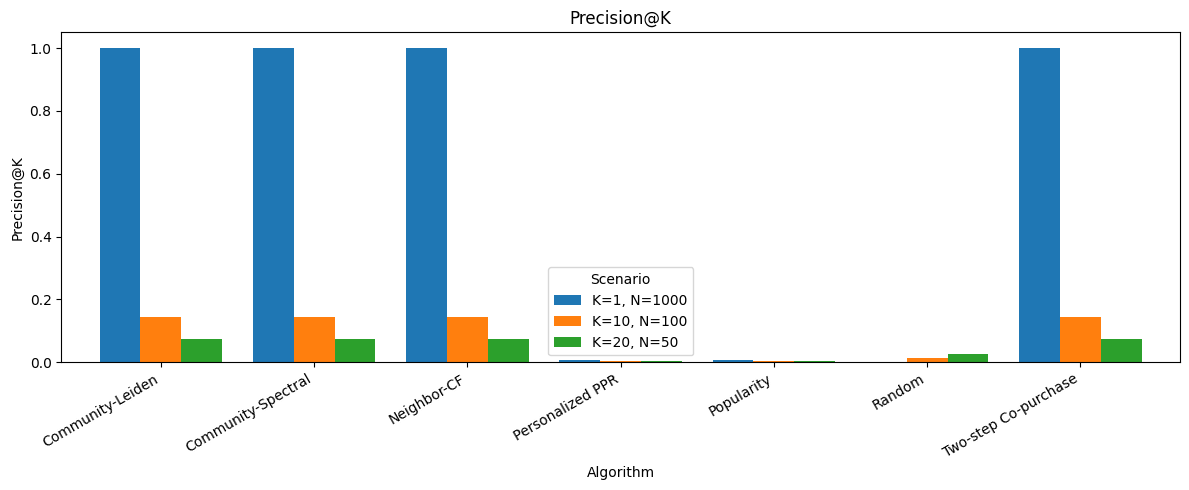

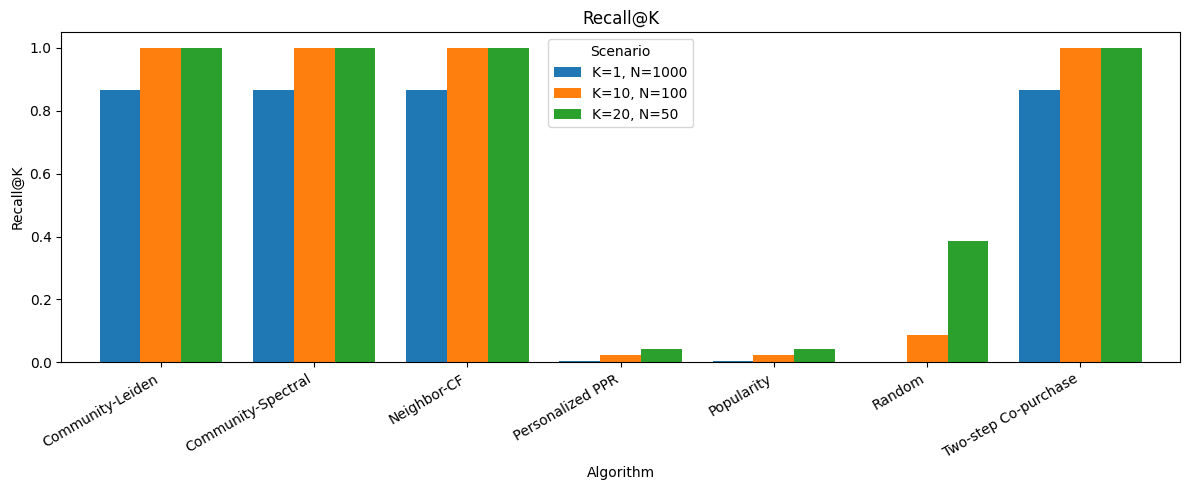

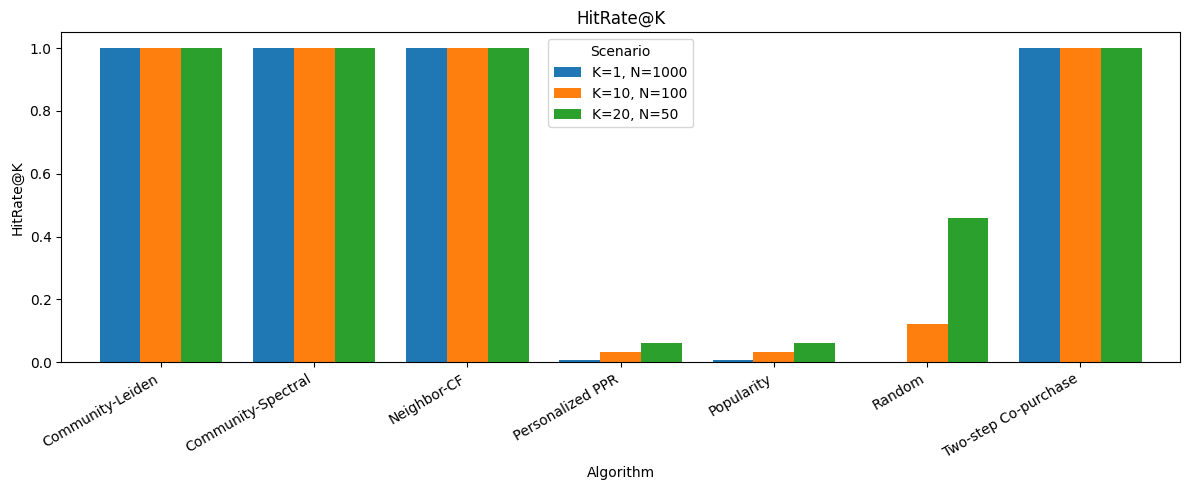

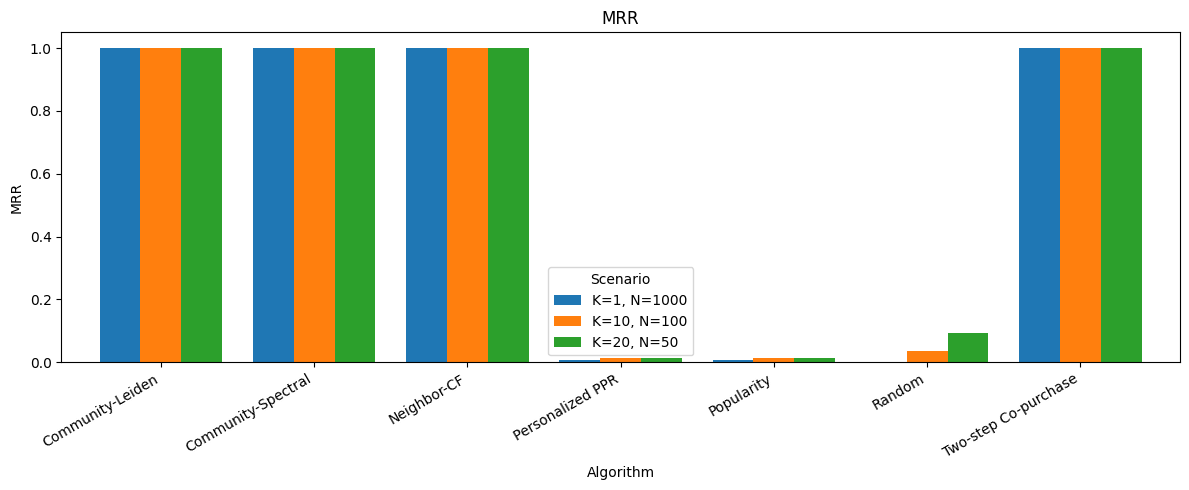

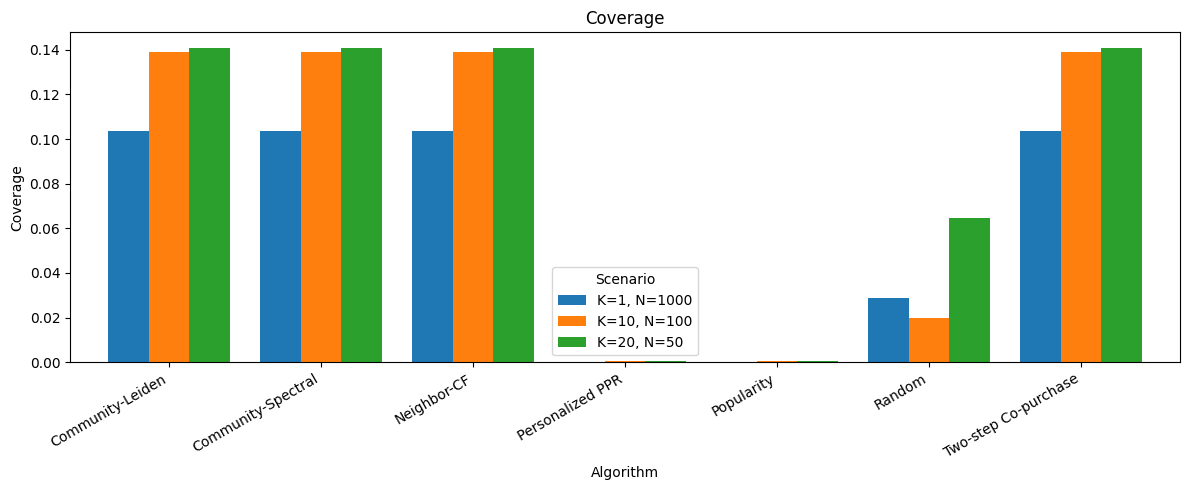

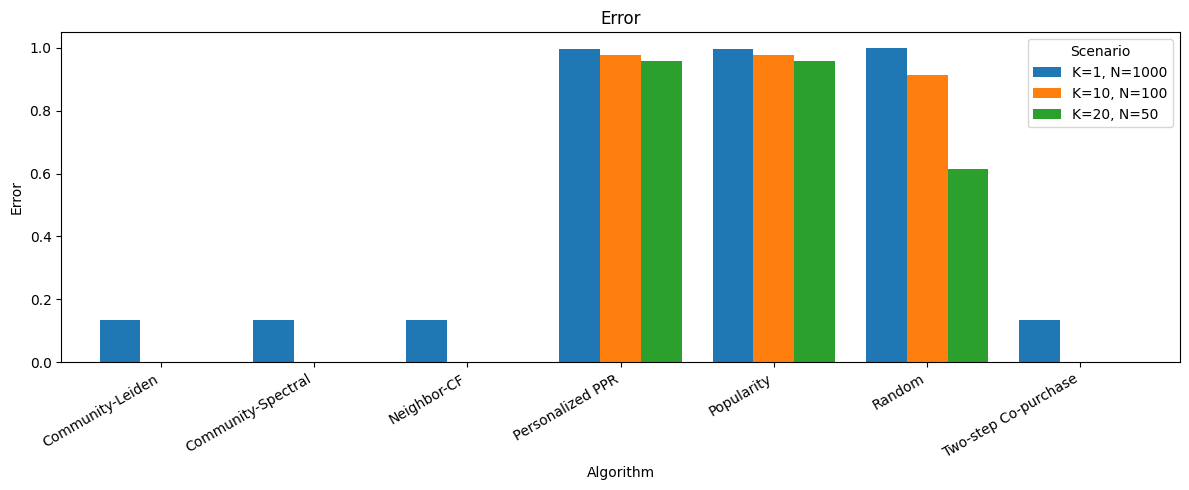

In [ ]:
#import matplotlib.pyplot as plt

df = results_df.reset_index().rename(columns={"index": "Algorithm"})


df["Scenario"] = "K=" + df["K"].astype(str) + ", N=" + df["Negatives"].astype(str)

def plot_metric(metric, df):
    pivot = df.pivot(index="Algorithm", columns="Scenario", values=metric)

    pivot.plot(
        kind="bar",
        figsize=(12, 5),
        width=0.8
    )

    plt.title(metric)
    plt.ylabel(metric)
    plt.xlabel("Algorithm")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Scenario")
    plt.tight_layout()
    plt.show()


metrics = [
    "Precision@K",
    "Recall@K",
    "HitRate@K",
    "MRR",
    "Coverage",
    "Error"
]

for m in metrics:
    plot_metric(m, df)



##GNN

In [9]:
# import random
# import numpy as np
# import pandas as pd
# from pathlib import Path
# from tqdm import tqdm
# from collections import defaultdict
# import torch
# import torch.nn as nn


# ============================================================
# CONFIG
# ============================================================
BASE = Path("/content/drive/MyDrive/GraphMiningProject/data/processed/filtered")

TRAIN_F = BASE / "splits_80_20/train.csv"
TEST_F  = BASE / "splits_80_20/test.csv"

OUT_DIR = BASE / "gnn_fast_sparse_run"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_F = OUT_DIR / "results_fast_sparse_gnn.csv"

# -------- SPEED SETTINGS --------
N_USERS = 5000         # increase later: 5000, 10000 ...
EMB_DIM = 32           # 32 or 64
EPOCHS = 2             # start small
LR = 1e-2
BATCH_SIZE = 2048
# -------------------------------

K_NEGATIVE_LIST = [(1,1000), (10,100), (20,50)]
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ============================================================
# 1) LOAD DATA
# ============================================================
print("\nLoading full train/test ...")
train_full = pd.read_csv(TRAIN_F)
test_full  = pd.read_csv(TEST_F)

print("Full train rows:", len(train_full))
print("Full test rows :", len(test_full))


# ============================================================
# 2) SUBSAMPLE USERS (to keep it runnable)
# ============================================================
print(f"\nSubsampling users => N_USERS={N_USERS} ...")
test_users = test_full["userID"].unique()

picked_users = np.random.choice(
    test_users,
    size=min(N_USERS, len(test_users)),
    replace=False
)

train = train_full[train_full["userID"].isin(picked_users)].reset_index(drop=True)
test  = test_full[test_full["userID"].isin(picked_users)].reset_index(drop=True)

print("Small train rows:", len(train))
print("Small test rows :", len(test))
print("Small test users:", test["userID"].nunique())


# ============================================================
# 3) MAPPINGS
# ============================================================
USER_COL = "userID"
ITEM_COL = "asin"

all_users = pd.concat([train[USER_COL], test[USER_COL]]).unique()
all_items = pd.concat([train[ITEM_COL], test[ITEM_COL]]).unique()

user2id = {u:i for i,u in enumerate(all_users)}
item2id = {it:i for i,it in enumerate(all_items)}

num_users = len(user2id)
num_items = len(item2id)

print("\nnum_users:", num_users, "| num_items:", num_items)

train_user_items = train.groupby(USER_COL)[ITEM_COL].apply(set).to_dict()
test_user_items  = test.groupby(USER_COL)[ITEM_COL].apply(set).to_dict()

all_items_set = set(all_items)

train_u = train[USER_COL].map(user2id).values
train_i = train[ITEM_COL].map(item2id).values

train_pairs = list(zip(train_u, train_i))


# ============================================================
# 4) BUILD NORMALIZED SPARSE USER-ITEM MATRIX (R_hat)
# ============================================================
# R[u,i] = 1 if interaction exists
# We'll use row-normalized: each user row sums to 1 (mean aggregation)

print("\nBuilding sparse matrix R_hat ...")

rows = torch.tensor(train_u, dtype=torch.long)
cols = torch.tensor(train_i, dtype=torch.long)
vals = torch.ones(len(train_u), dtype=torch.float32)

# shape: [num_users, num_items]
R = torch.sparse_coo_tensor(
    indices=torch.stack([rows, cols], dim=0),
    values=vals,
    size=(num_users, num_items)
).coalesce()

# Row-normalize (mean aggregation)
row_sum = torch.sparse.sum(R, dim=1).to_dense()  # [num_users]
row_sum[row_sum == 0] = 1.0

# Build normalized values: val / row_sum[user]
norm_vals = vals / row_sum[rows]
R_hat = torch.sparse_coo_tensor(
    indices=torch.stack([rows, cols], dim=0),
    values=norm_vals,
    size=(num_users, num_items)
).coalesce().to(device)

print("R_hat nnz:", R_hat._nnz())


# ============================================================
# 5) FAST "GNN-like" MODEL (Vectorized aggregation)
# ============================================================
class FastSparseGNN(nn.Module):
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)

        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)

    def full_user_repr(self, R_hat):
        """
        user_repr = user_emb + (R_hat @ item_emb)
        This is vectorized message passing (VERY FAST).
        """
        U0 = self.user_emb.weight                       # [U, D]
        I0 = self.item_emb.weight                       # [I, D]
        neigh = torch.sparse.mm(R_hat, I0)              # [U, D]
        return U0 + neigh

    def score_pairs(self, user_ids, item_ids, user_repr=None):
        """
        score(u,i) = dot(user_repr[u], item_emb[i])
        """
        if user_repr is None:
            raise ValueError("user_repr must be provided (cached)")

        u_vec = user_repr[user_ids]                     # [B, D]
        i_vec = self.item_emb(item_ids)                 # [B, D]
        return (u_vec * i_vec).sum(dim=1)


model = FastSparseGNN(num_users, num_items, EMB_DIM).to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)


def sample_negative(u_id):
    """
    sample item not in train for that user
    """
    u_raw = all_users[u_id]
    seen = train_user_items.get(u_raw, set())
    pool = list(all_items_set - seen)
    if len(pool) == 0:
        return random.randrange(num_items)
    return item2id[random.choice(pool)]


# ============================================================
# 6) TRAIN (BPR) - FAST
# ============================================================
print("\nTraining FAST Sparse GNN ...")
model.train()

for epoch in range(1, EPOCHS + 1):
    random.shuffle(train_pairs)
    losses = []

    # cache full user representations ONCE per epoch
    user_repr = model.full_user_repr(R_hat).detach()  # detach -> prevents double backward graph error


    for start in range(0, len(train_pairs), BATCH_SIZE):
        batch = train_pairs[start:start + BATCH_SIZE]
        if len(batch) == 0:
            continue

        u = torch.tensor([x[0] for x in batch], dtype=torch.long, device=device)
        pos = torch.tensor([x[1] for x in batch], dtype=torch.long, device=device)

        neg_list = [sample_negative(int(uid)) for uid in u.cpu().numpy()]
        neg = torch.tensor(neg_list, dtype=torch.long, device=device)

        opt.zero_grad()

        pos_score = model.score_pairs(u, pos, user_repr=user_repr)
        neg_score = model.score_pairs(u, neg, user_repr=user_repr)

        loss = -torch.log(torch.sigmoid(pos_score - neg_score) + 1e-10).mean()
        loss.backward()
        opt.step()

        losses.append(loss.item())

    print(f"Epoch {epoch:02d} | Loss = {np.mean(losses):.4f}")


# ============================================================
# 7) EVALUATION
# ============================================================
def build_candidates(user_raw, negatives_count):
    positives = list(test_user_items[user_raw])
    negatives_pool = list(all_items_set - train_user_items.get(user_raw, set()) - set(positives))
    negatives = random.sample(negatives_pool, min(len(negatives_pool), negatives_count))
    return positives + negatives


@torch.no_grad()
def rank_model(user_raw, candidates, user_repr_cached):
    if user_raw not in user2id:
        return candidates

    u_id = user2id[user_raw]
    u_vec = user_repr_cached[u_id]  # [D]

    cand_ids = torch.tensor([item2id[it] for it in candidates], dtype=torch.long, device=device)
    i_vecs = model.item_emb(cand_ids)  # [C, D]

    scores = (i_vecs * u_vec).sum(dim=1)
    order = torch.argsort(scores, descending=True).cpu().numpy()
    return [candidates[i] for i in order]


def evaluate(K, NEGATIVE_SAMPLES):
    model.eval()

    # cache user representations ONCE for evaluation
    user_repr_cached = model.full_user_repr(R_hat)

    users = sorted(test_user_items.keys())

    hits, precisions, recalls, mrrs = [], [], [], []
    recommended_all = set()

    for u in tqdm(users, desc=f"Eval(K={K},Neg={NEGATIVE_SAMPLES})"):
        candidates = build_candidates(u, NEGATIVE_SAMPLES)
        ranked = rank_model(u, candidates, user_repr_cached)[:K]

        positives = set(test_user_items[u])
        recommended_all.update(ranked)

        hit = any(i in positives for i in ranked)
        hits.append(hit)

        tp = len(set(ranked) & positives)
        precisions.append(tp / K)
        recalls.append(tp / len(positives))

        ranks = [ranked.index(i) + 1 for i in positives if i in ranked]
        mrrs.append(1 / min(ranks) if ranks else 0)

    return {
        "Precision@K": float(np.mean(precisions)),
        "Recall@K": float(np.mean(recalls)),
        "HitRate@K": float(np.mean(hits)),
        "MRR": float(np.mean(mrrs)),
        "Coverage": float(len(recommended_all) / len(all_items_set)),
        "Error": float(1 - np.mean(recalls)),
        "K": K,
        "Negatives": NEGATIVE_SAMPLES
    }


# ============================================================
# 8) RUN + SAVE
# ============================================================
print("\nRunning evaluation ...")
all_results = []
for K, NEGATIVE_SAMPLES in K_NEGATIVE_LIST:
    all_results.append(evaluate(K, NEGATIVE_SAMPLES))

gnn_results_df = pd.DataFrame(all_results)
print("\n=== Final Results ===")
print(gnn_results_df)

gnn_results_df.to_csv(RESULTS_F, index=False)
print("\nSaved results to:", RESULTS_F)


Device: cuda

Loading full train/test ...
Full train rows: 1267774
Full test rows : 236146

Subsampling users => N_USERS=2000 ...
Small train rows: 14747
Small test rows : 3010
Small test users: 2000

num_users: 2000 | num_items: 10377

Building sparse matrix R_hat ...
R_hat nnz: 14747

Training FAST Sparse GNN ...
Epoch 01 | Loss = 0.6927
Epoch 02 | Loss = 0.6782

Running evaluation ...


Eval(K=20,Neg=50): 100%|██████████| 2000/2000 [00:02<00:00, 695.91it/s]


=== Final Results ===
   Precision@K  Recall@K  HitRate@K       MRR  Coverage     Error   K  \
0     0.001500  0.000542     0.0015  0.001500  0.142527  0.999458   1   
1     0.013700  0.091761     0.1275  0.039914  0.808133  0.908239  10   
2     0.027975  0.380385     0.4600  0.092024  0.976679  0.619615  20   

   Negatives  
0       1000  
1        100  
2         50  

Saved results to: /content/drive/MyDrive/GraphMiningProject/data/processed/filtered/gnn_fast_sparse_run/results_fast_sparse_gnn.csv


### Fast Sparse GNN-like Recommender (Lightweight Implementation)

This notebook implements a **fast and simplified GNN-style recommender system** for the user–item interaction dataset.  
To keep the training runnable on large data, we **subsample a limited number of users** and avoid expensive full-graph GNN operations.

### Key Idea
Instead of building a deep graph neural network, we use a **single vectorized message passing step** based on a sparse user–item matrix:

\[
\text{UserRep} = U + \hat{R}I
\]

- \(U\): learnable user embeddings  
- \(I\): learnable item embeddings  
- \(\hat{R}\): row-normalized sparse interaction matrix (mean aggregation)

This gives each user a representation that combines their own embedding with the aggregated embeddings of items they interacted with.

### Training (BPR Loss)
The model is trained using **Bayesian Personalized Ranking (BPR)** with negative sampling:

- Positive samples: observed user–item interactions from the training set  
- Negative samples: random unseen items for the same user  

The loss encourages the model to score positive items higher than negatives.

### Evaluation
We evaluate the recommender under multiple \((K, \text{Negatives})\) scenarios and report standard Top-K metrics:

- Precision@K  
- Recall@K  
- HitRate@K  
- MRR  
- Coverage  
- Error (1 − Recall)

### Notes / Limitations
- This is a **lightweight approximation** of a real GNN (only one aggregation step).
- Negative sampling is random and may not always produce "hard negatives".
- Results may vary depending on the subsampling size and random seed.
- The model does not use timestamps directly during training (only the train/test split is time-aware).


Algorithms found: ['Popularity' 'Random' 'Two-step Co-purchase' 'Community-Leiden' 'GNN']


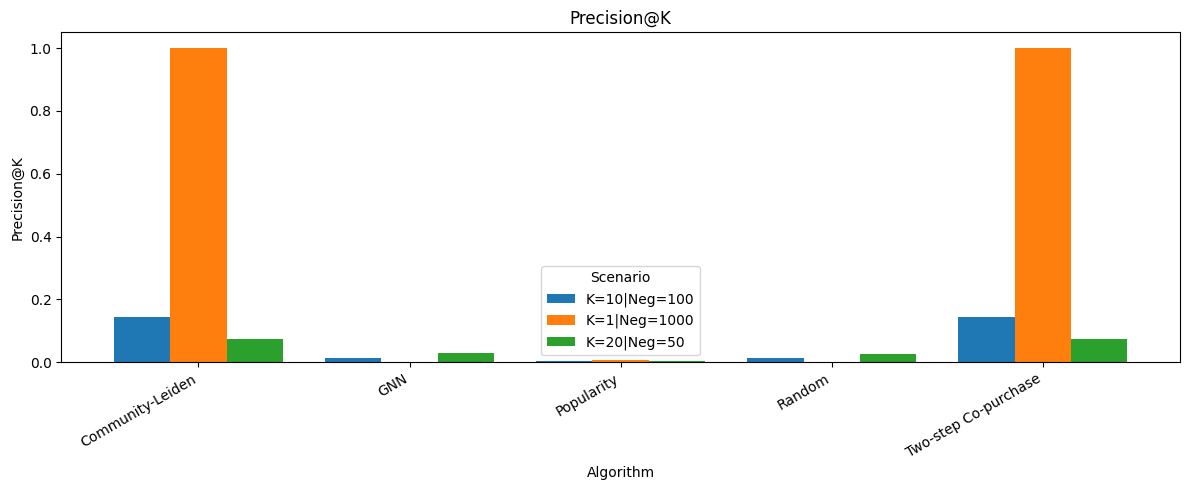

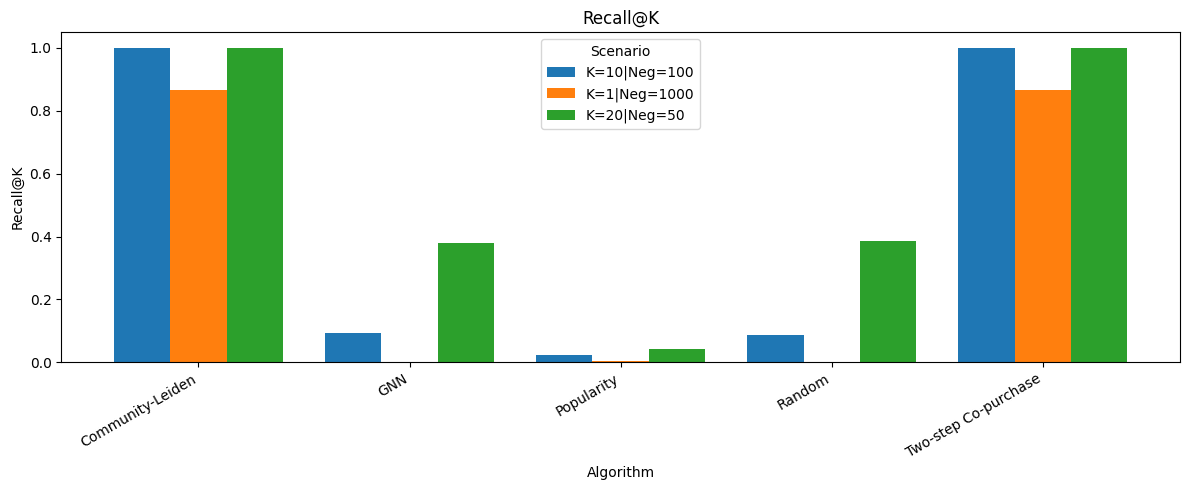

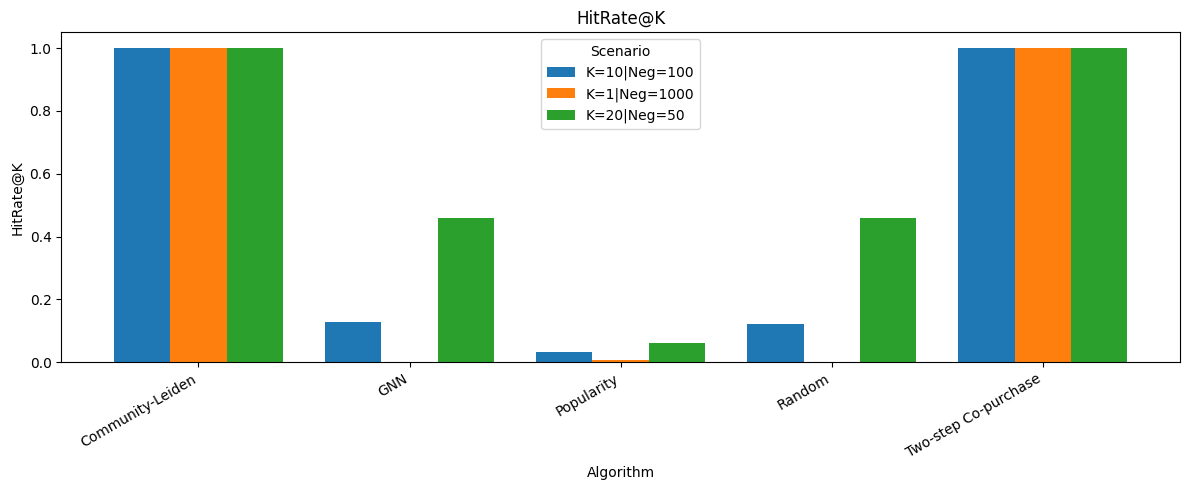

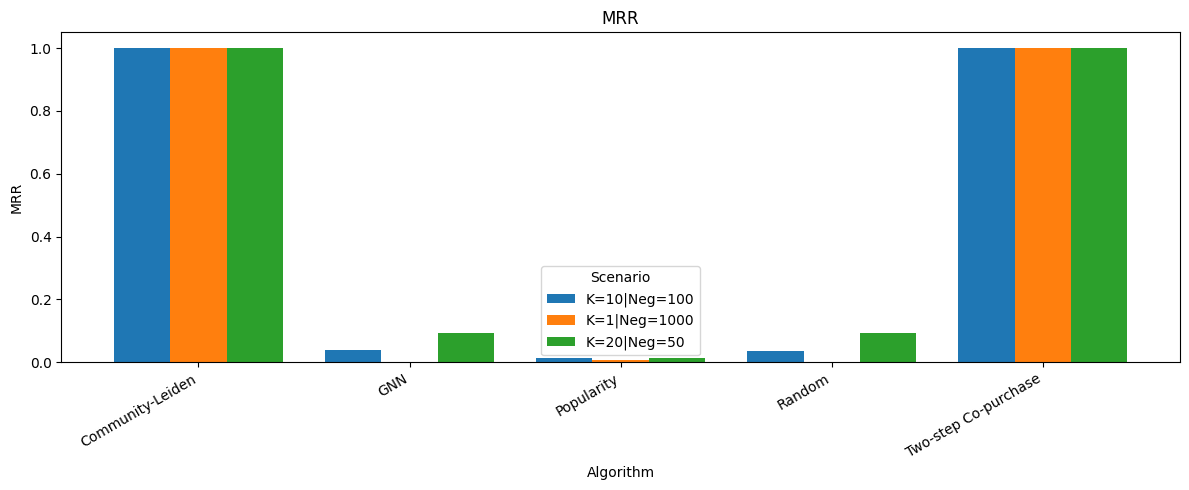

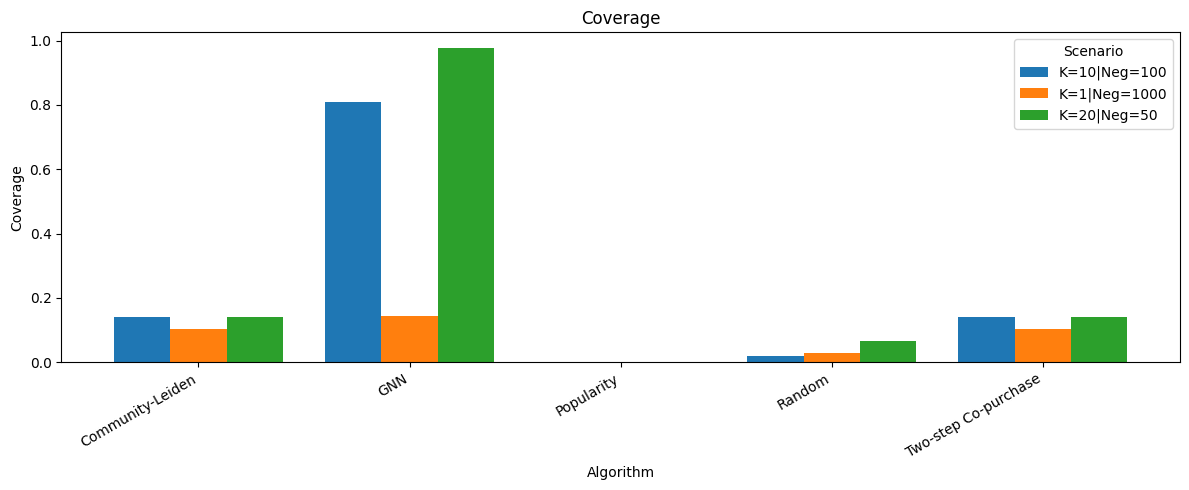

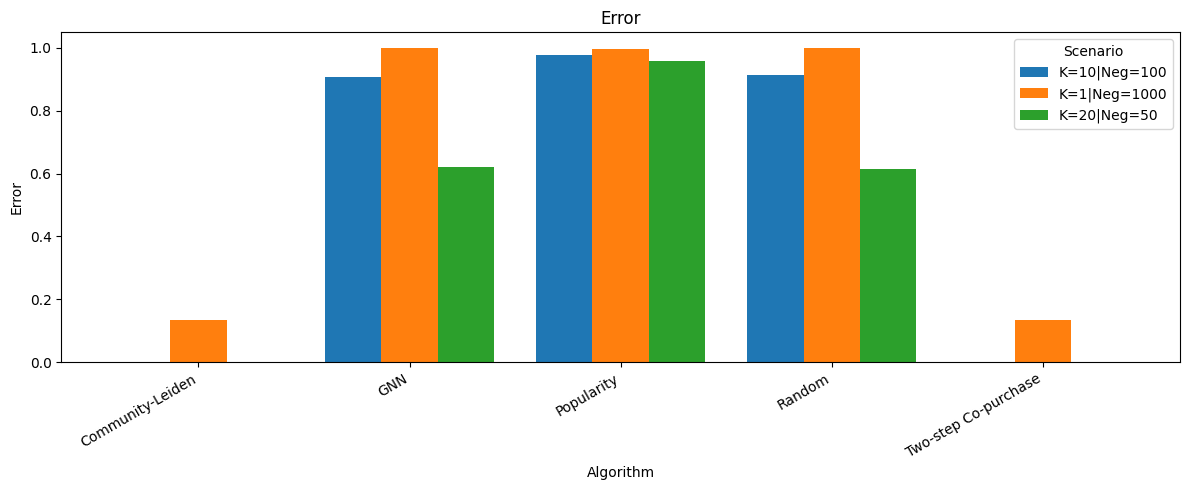

In [9]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path

# -----------------------------
# Paths
# -----------------------------
RESULTS_DIR = BASE / "results"
classic_csv = RESULTS_DIR / "evaluation_results.csv"

OUT_DIR = BASE / "gnn_fast_sparse_run"
gnn_csv = OUT_DIR / "results_fast_sparse_gnn.csv"

# -----------------------------
# Load classic results (FIX: Algorithm column may be saved as index)
# -----------------------------
classic_df = pd.read_csv(classic_csv)

# If algorithms were saved as index, pandas reads them as "Unnamed: 0"
if "Algorithm" not in classic_df.columns:
    if "Unnamed: 0" in classic_df.columns:
        classic_df = classic_df.rename(columns={"Unnamed: 0": "Algorithm"})
    else:
        raise ValueError("Classic results file has no Algorithm column!")

# -----------------------------
# Load GNN results
# -----------------------------
gnn_df = pd.read_csv(gnn_csv)

# Force the algorithm name for GNN results
gnn_df["Algorithm"] = "GNN"

# -----------------------------
# Create Scenario column (needed for pivot plot)
# Example: K=10|Neg=100
# -----------------------------
def add_scenario_col(df):
    df = df.copy()
    df["Scenario"] = "K=" + df["K"].astype(str) + "|Neg=" + df["Negatives"].astype(str)
    return df

classic_df = add_scenario_col(classic_df)
gnn_df = add_scenario_col(gnn_df)

# -----------------------------
# Merge both result tables
# -----------------------------
df = pd.concat([classic_df, gnn_df], ignore_index=True)

# Keep only selected algorithms for plotting
keep_algs = [
    "Popularity",
    "Random",
    "Two-step Co-purchase",
    "Community-Leiden",
    "GNN"
]
df = df[df["Algorithm"].isin(keep_algs)].copy()

print("Algorithms found:", df["Algorithm"].unique())

# -----------------------------
# Plot function (bar chart per metric)
# -----------------------------
def plot_metric(metric, df):
    pivot = df.pivot(index="Algorithm", columns="Scenario", values=metric)

    pivot.plot(
        kind="bar",
        figsize=(12, 5),
        width=0.8
    )

    plt.title(metric)
    plt.ylabel(metric)
    plt.xlabel("Algorithm")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Scenario")
    plt.tight_layout()
    plt.show()

# Metrics to plot
metrics = [
    "Precision@K",
    "Recall@K",
    "HitRate@K",
    "MRR",
    "Coverage",
    "Error"
]

# Generate plots
for m in metrics:
    plot_metric(m, df)


In this cell, we **systematically evaluate all implemented recommender systems** on a realistic, time-aware test setting using the `train.csv` and `test.csv` splits produced in Step 11. The test set contains each user’s **future interaction(s)** (leave-last-out), allowing us to measure whether a recommender can correctly predict what a user actually buys next. To ensure fair and informative comparisons, we restrict evaluation to the **1,000 most active users** (based on training interactions) who also appear in the test set. This choice reduces noise from extremely sparse users while keeping the evaluation computationally tractable, especially for more expensive models such as Personalized PageRank.

For each user, every recommender generates a ranked list of candidate products, and we compare these rankings against the user’s held-out test item. We compute standard top-K recommendation metrics including **Precision@K**, **HitRate@K (Recall@K in the single-item test setting)**, and **Mean Reciprocal Rank (MRR)**, which captures how early the correct item appears in the recommendation list. In addition to accuracy metrics, we also measure **catalog coverage** (the fraction of distinct products ever recommended) and **computational efficiency**, reporting both average per-user latency and total wall-clock time. This allows us to explicitly analyze the trade-off between recommendation quality and runtime cost.

Finally, the cell aggregates results across all users and produces **comparative visualizations**. Bar plots summarize Precision@K for multiple values of K, MRR, coverage, and average latency, making it easy to see which recommenders are most accurate, which are most diverse, and which are fastest. All metrics are saved to CSV and JSON files for reproducibility and reporting, while the plots provide a clear, high-level comparison of baseline, collaborative, graph-based, and community-aware recommenders in terms of their ability to predict users’ future purchases.

---